In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))

warnings.filterwarnings('ignore', category=UserWarning, module='seaborn')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

from monitorviz.io import load_collection
from monitorviz.transforms import RunCollection
from monitorviz.viz import (
    setup_style, correlation_heatmap, pareto_panel_multi,
    phase_breakdown_stacked, throttling_heatmap,
    hw_distributions_panel, temp_freq_dual,
    cpu_memory_dual_phases,
)
setup_style()

DATA_BASE = Path('../data/TFG-DATA')
EXP_FAN   = DATA_BASE / 'E0-FAN'
EXP_NOFAN = DATA_BASE / 'E0-NOFAN'

_runs_fan_all   = load_collection(EXP_FAN).runs   if EXP_FAN.exists()   else []
_runs_nofan_all = load_collection(EXP_NOFAN).runs if EXP_NOFAN.exists() else []

ENGINE = 'LLAMA'
runs_fan   = [r for r in _runs_fan_all   if r.summary.inference_engine == ENGINE]
runs_nofan = [r for r in _runs_nofan_all if r.summary.inference_engine == ENGINE]

coll = RunCollection(runs_fan + runs_nofan)

summary = coll.summary_df()
hw_df   = coll.hw_metrics_df()
pm_df   = coll.prompt_metrics_df()

print(f'Engine: {ENGINE}')
print(f'Runs cargados: {len(coll.runs)}')
print(f'  · Con ventilador:    {len(runs_fan)}')
print(f'  · Sin ventilador:    {len(runs_nofan)}')
print(f'  · Runs en summary:   {len(summary)}')
n_valid = len(pm_df[~pm_df["is_empty_generation"]]) if not pm_df.empty else 0
print(f'  · Prompts válidos:   {n_valid}')

# Añadir config_label = "modelo\n(FAN/NOFAN)" para gráficas
if not summary.empty:
    summary["config_label"] = (
        summary["model_label"] + "\n(" +
        summary["fan"].map({True: "FAN", False: "NOFAN"}) + ")"
    )
    _cl = summary[["run_id", "config_label"]]
    if not hw_df.empty:
        hw_df = hw_df.merge(_cl, on="run_id", how="left")
    if not pm_df.empty:
        pm_df = pm_df.merge(_cl, on="run_id", how="left")

# ── Agregados HW por run (solo durante inferencia activa: cpu > 10%) ──────────

# 1. Frecuencia media de CPU durante inferencia
if not hw_df.empty and "freq_mean_ghz" in hw_df.columns:
    freq_agg = (
        hw_df[hw_df["cpu_usage_pct"] > 10]
        .groupby("run_id")["freq_mean_ghz"]
        .mean()
        .rename("freq_mean_inference_ghz")
        .reset_index()
    )
    summary = summary.merge(freq_agg, on="run_id", how="left")

# 2. Fan speed media durante inferencia
FAN_COL = "fan_rpm"   # nombre en hw_df (mapeado desde fan_speed_ en _parsers.py)

if not hw_df.empty and FAN_COL in hw_df.columns:
    fan_agg = (
        hw_df[hw_df["cpu_usage_pct"] > 10]
        .groupby("run_id")[FAN_COL]
        .mean()
        .rename("fan_speed_mean")
        .reset_index()
    )
    summary = summary.merge(fan_agg, on="run_id", how="left")
    print(f"fan_speed_mean añadida: {summary['fan_speed_mean'].notna().sum()} runs con datos")
else:
    print(f"Columna fan no encontrada. Disponibles: "
          f"{[c for c in hw_df.columns if 'fan' in c.lower()]}")

# 3. Número real de parámetros (entero exacto, sin abreviar)
if "n_params" not in summary.columns:
    run_map_p = {r.run_id: r for r in coll.runs}
    summary["n_params"] = [
        (run_map_p[rid].summary.model_info or {}).get("n_params", float("nan"))
        if rid in run_map_p else float("nan")
        for rid in summary["run_id"]
    ]

# Verificación rápida de las nuevas columnas
_check_cols = ["freq_mean_inference_ghz", "fan_speed_mean", "n_params"]
print(summary[[c for c in _check_cols if c in summary.columns]
              + ["model_label", "fan"]].round(4))

# Aliases para consistencia con E1-E5 (que usan hw_full / pm_full)
hw_full = hw_df
pm_full = pm_df


tokenProb size mismatch in run=1780948937859414717 prompt=7: got 266 tokens, eval_count=-1


Engine: LLAMA
Runs cargados: 12
  · Con ventilador:    6
  · Sin ventilador:    6
  · Runs en summary:   12
  · Prompts válidos:   178
fan_speed_mean añadida: 12 runs con datos
    freq_mean_inference_ghz  fan_speed_mean      n_params           model_label    fan
0                    2.4000       7383.4430  3.429006e+09         ministral (L)   True
1                    2.4000       7424.1816  3.212750e+09      Llama-3.2-3B (L)   True
2                    2.4000       7229.8031  1.235814e+09      Llama-3.2-1B (L)   True
3                    2.4000       7182.4896  3.191396e+09           granite (L)   True
4                    2.4000       7267.6001  1.910000e+09             gemma (L)   True
5                    2.4000       7491.2552  1.777088e+09  DeepSeek-R1-1.5B (L)   True
6                    1.0497          0.0000  3.429006e+09         ministral (L)  False
7                    1.0842          0.0000  3.212750e+09      Llama-3.2-3B (L)  False
8                    1.0854          0.0

1# E0 — Comparativa baseline entre modelos

## Pregunta de investigación
¿Qué modelo LLM ofrece el mejor compromiso rendimiento/eficiencia en
una Raspberry Pi 5 en condiciones de inferencia estándar?
¿Cómo afecta la refrigeración activa (ventilador) al rendimiento sostenido?

## Hipótesis
- Los modelos más pequeños (1B) serán más rápidos pero con menor calidad.
- El ventilador reducirá el throttling térmico y mejorará el throughput sostenido.
- La potencia media será similar entre modelos (limitada por el SoC),
  pero la energía por token variará según la velocidad de cada modelo.

## Configuración del experimento
| Parámetro       | Valor fijo                             |
|-----------------|----------------------------------------|
| batch_size      | 512                                    |
| context_size    | 4096                                   |
| quantization    | Q4_K_M                                 |
| temperature     | 0.0                                    |
| num_prompts     | 15 (IFEval)                            |
| hardware        | Raspberry Pi 5 (BCM2712, 8 GB LPDDR4X) |

| Variable        | Valores                                             |
|-----------------|-----------------------------------------------------|
| modelo          | Ministral-3B, Llama3.2-1B, Llama3.2-3B,           |
|                 | DeepSeek-Qwen-1.5B, Gemma3n-e2b                    |
| refrigeración   | Con ventilador (FAN) / Sin ventilador (NOFAN)       |

# 📊 Figuras y tablas de la memoria

Sección principal del experimento E0. El material complementario está en el **📎 Anexo** al final.

| # | Figura/Tabla |
|---|---|
| 1 | Tabla maestra de caracterización (N params, tok/s, TTFT, J/tok, RAM, MBU_corr, η, FoM, usabilidad) |
| 2 | Frontera de Pareto: velocidad vs huella RAM (tamaño burbuja = FoM_full) |
| 3 | FoM_full descompuesta por ejes normalizados |
| 4 | Impacto de la refrigeración: Δ% throughput FAN vs NOFAN |
| 5 | E0.4 — Desglose temporal por fase (load / prefill / decode): FAN vs NOFAN comparado |
| 6 | E0.5 — Trabajo y eficiencia computacional por fase (W_CPU, η_CPU): FAN vs NOFAN comparado |


## Figura de Mérito (FoM_full)

Combina cuatro ejes normalizados respecto a la configuración de referencia
(**llama3.2:3b · llama.cpp · Q4_K_M · ctx=4096 · bs=512**):

$$\text{FoM\_full} = \bigl(T_{norm} \cdot MBU_{norm} \cdot \eta_{norm} \cdot \varepsilon_{norm}\bigr)^{1/4}$$

| Eje | Normalización | Significado |
|-----|--------------|-------------|
| $T_{norm}$ | $N \cdot T / (N_{ref} T_{ref})$ | Throughput ponderado por tamaño |
| $MBU_{norm}$ | $\text{MBU\_corr} / \text{MBU}_{ref}$ | Utilización de ancho de banda (corregida) |
| $\eta_{norm}$ | $\eta_{CPU} / \eta_{ref}$ | Eficiencia computacional |
| $\varepsilon_{norm}$ | $N \cdot \varepsilon / (N_{ref} \varepsilon_{ref})$ | Tokens/J ponderados por tamaño |

**FoM_full > 1** → la configuración supera a la referencia en media geométrica.


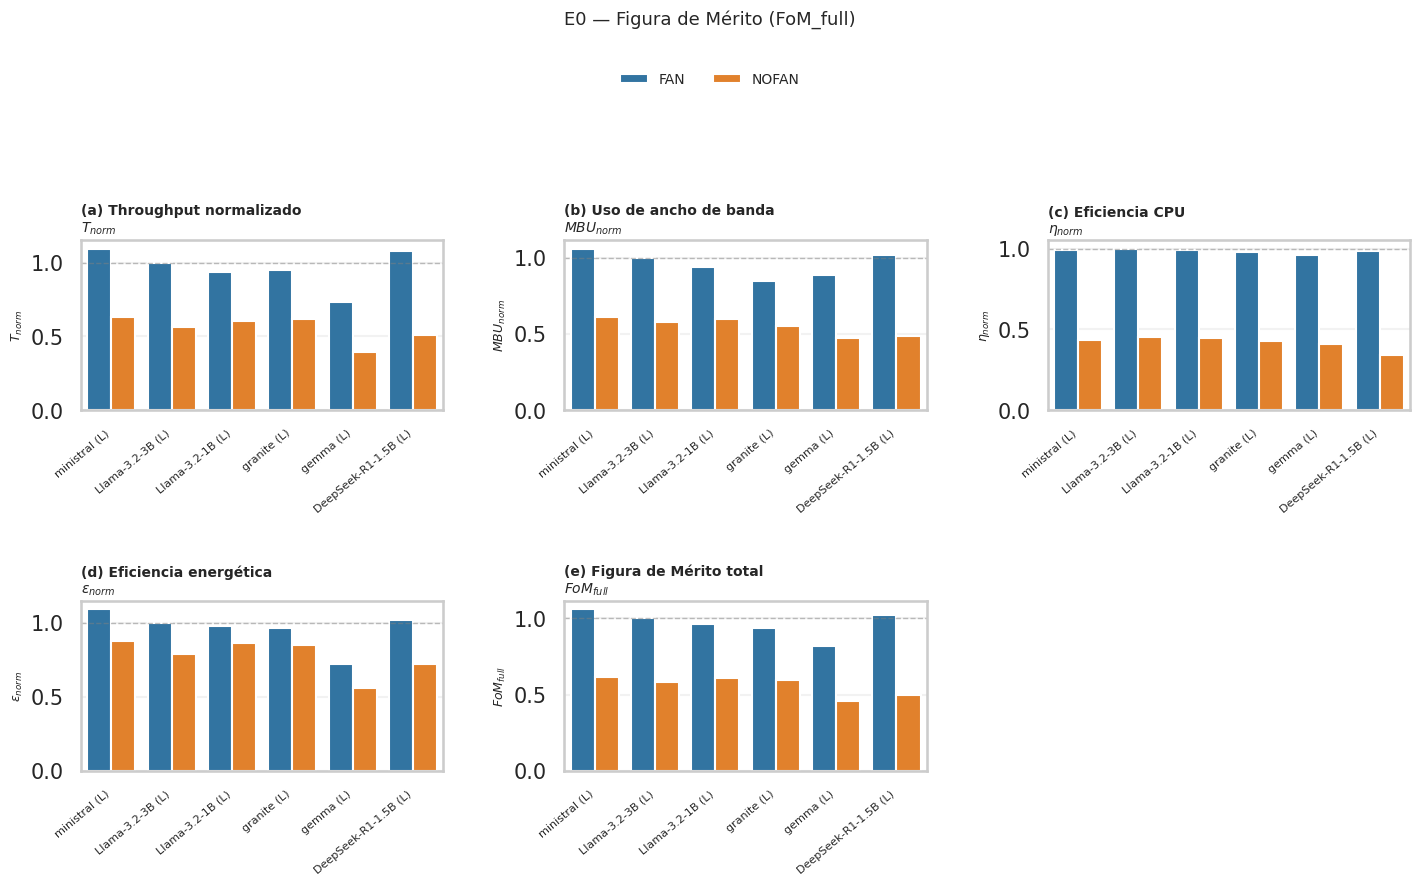

FoM_full por configuración:


,model_label,_fan_label,mbu_corr,tokens_per_s_mean,fom_full
0,ministral (L),FAN,66.133,4.731,1.058
1,Llama-3.2-3B (L),FAN,62.465,4.608,1.000
2,Llama-3.2-1B (L),FAN,58.785,11.229,0.961
3,granite (L),FAN,52.965,4.410,0.934
4,gemma (L),FAN,55.464,5.683,0.818
5,DeepSeek-R1-1.5B (L),FAN,63.653,8.978,1.025
6,ministral (L),NOFAN,37.957,2.714,0.618
7,Llama-3.2-3B (L),NOFAN,36.166,2.602,0.585
8,Llama-3.2-1B (L),NOFAN,37.267,7.236,0.610
9,granite (L),NOFAN,34.299,2.879,0.593



Criterio de usabilidad (≥3 palabras/s): 8/12 runs usables


,model_label,tokens_per_s_mean,T_hum,usable
0,ministral (L),4.731,4.522,True
1,Llama-3.2-3B (L),4.608,4.252,True
2,Llama-3.2-1B (L),11.229,4.416,True
3,granite (L),4.410,3.987,True
4,gemma (L),5.683,4.449,True
5,DeepSeek-R1-1.5B (L),8.978,3.691,True
6,ministral (L),2.714,4.522,False
7,Llama-3.2-3B (L),2.602,4.252,False
8,Llama-3.2-1B (L),7.236,4.416,True
9,granite (L),2.879,3.987,False


In [2]:
# ── FoM_full — Figura de Mérito compuesta (E0) ─────────────────────────────
from monitorviz.transforms.fom import compute_fom_full, compute_usability

_pm = (pm_full if "pm_full" in dir() else
       pm_df   if "pm_df"   in dir() else pd.DataFrame())
_FOM_AXES = {
    "fom_T_norm":   (r"$T_{norm}$",          "Throughput normalizado"),
    "fom_MBU_norm": (r"$MBU_{norm}$",         "Uso de ancho de banda"),
    "fom_eta_norm": (r"$\eta_{norm}$",        "Eficiencia CPU"),
    "fom_eps_norm": (r"$\varepsilon_{norm}$", "Eficiencia energética"),
    "fom_full":     ("$FoM_{full}$",           "Figura de Mérito total"),
}
_PANEL = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
_x_col = "model_label"
_hue   = "fan" if "fan" in summary.columns else None

try:
    fom_df = compute_fom_full(summary)
    if "fan" in fom_df.columns:
        fom_df["_fan_label"] = fom_df["fan"].map({True: "FAN", False: "NOFAN"})
        _hue = "_fan_label"
    avail = [col for col in _FOM_AXES if col in fom_df.columns and fom_df[col].notna().any()]

    if avail:
        _nc = 3
        _nr = (len(avail) + _nc - 1) // _nc
        fig, _axes = plt.subplots(_nr, _nc, figsize=(_nc * 5, _nr * 4.2))
        _axes_flat = _axes.flatten() if _nr > 1 else list(_axes)

        for idx, (ax, col) in enumerate(zip(_axes_flat, avail)):
            d = fom_df.dropna(subset=[col])
            kw = dict(data=d, x=_x_col, y=col, ax=ax)
            if _hue and _hue in d.columns:
                kw["hue"] = _hue
            sns.barplot(**kw)

            math_lbl, desc_lbl = _FOM_AXES[col]
            ax.set_title(f"{_PANEL[idx]} {desc_lbl}\n{math_lbl}",
                         fontsize=10, fontweight="bold", loc="left", pad=6)
            ax.set_xlabel("")
            ax.set_ylabel(math_lbl, fontsize=9)
            plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
            ax.axhline(1.0, ls="--", color="gray", alpha=0.5, lw=1)
            ax.grid(True, axis="y", alpha=0.25)
            if ax.get_legend():
                ax.get_legend().remove()

        for ax in _axes_flat[len(avail):]:
            ax.set_visible(False)

        # Leyenda compartida encima
        _all_h, _all_l = [], []
        for _ax in _axes_flat[:len(avail)]:
            h, l = _ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in _all_l:
                    _all_h.append(hh); _all_l.append(ll)
        if _all_h:
            fig.legend(_all_h, _all_l, loc="upper center",
                       bbox_to_anchor=(0.5, 1.03), ncol=len(_all_h), fontsize=10)
        fig.suptitle("E0 — Figura de Mérito (FoM_full)", fontsize=13, y=1.09)
        fig.tight_layout(pad=2.0)
        plt.show()

        _disp = [c for c in [_x_col, _hue, "mbu_corr", "tokens_per_s_mean", "fom_full"]
                 if c and c in fom_df.columns]
        print("FoM_full por configuración:")
        display(fom_df[_disp].round(3))

    if not _pm.empty:
        fom_df, _tpw = compute_usability(fom_df, _pm)
        n_usable = int(fom_df["usable"].sum()) if "usable" in fom_df.columns else 0
        print(f"\nCriterio de usabilidad (≥3 palabras/s): {n_usable}/{len(fom_df)} runs usables")
        _uc = [c for c in [_x_col, "tokens_per_s_mean", "T_hum", "usable"] if c in fom_df.columns]
        if _uc:
            display(fom_df[_uc].round(3))
except Exception as e:
    print(f"Error en FoM: {e}")

In [3]:
# ── Tabla 1 — Caracterización base E0 (ordenada: usables ↑, FoM_full ↓) ─────
try:
    _t = fom_df.copy()

    # RAM en runtime (mean hw_metrics) en GB métrico
    _hw_src = hw_df if "hw_df" in vars() else pd.DataFrame()
    if not _hw_src.empty and "mem_used_bytes" in _hw_src.columns and "run_id" in _t.columns:
        _ram_rt = _hw_src.groupby("run_id")["mem_used_bytes"].mean().reset_index()
        _ram_rt["ram_used_gb"] = _ram_rt["mem_used_bytes"] / 1e9
        _t = _t.merge(_ram_rt[["run_id", "ram_used_gb"]], on="run_id", how="left")

    # σ desde métricas por prompt (variabilidad intra-run)
    _pm_src = pm_full if "pm_full" in vars() else (pm_df if "pm_df" in vars() else pd.DataFrame())
    if not _pm_src.empty and "run_id" in _pm_src.columns and "run_id" in _t.columns:
        _valid_pm = (_pm_src[~_pm_src["is_empty_generation"]]
                     if "is_empty_generation" in _pm_src.columns else _pm_src)
        _std_grp = [c for c in ["tokens_per_second", "time_to_first_token_ms", "perplexity"]
                    if c in _valid_pm.columns]
        if _std_grp:
            _std_df = (
                _valid_pm.groupby("run_id")[_std_grp].std().reset_index()
                .rename(columns={"tokens_per_second":      "tokens_per_s_std",
                                 "time_to_first_token_ms": "ttft_ms_std",
                                 "perplexity":             "perplexity_std"})
            )
            _t = _t.merge(_std_df, on="run_id", how="left")

    _col_map = [
        ("model_label",          "Modelo"),
        ("fan",                  "FAN"),
        ("n_params",             "N params"),
        ("ram_used_gb",           "RAM (GB)"),
        ("tokens_per_s_mean",    "tok/s"),
        ("tokens_per_s_std",     "σ tok/s"),
        ("ttft_ms_mean",         "TTFT (ms)"),
        ("ttft_ms_std",          "σ TTFT"),
        ("energy_per_token_j",   "J/token"),
        ("mbu_corr",             "MBU_corr (%)"),
        ("cpu_efficiency",       "η_CPU"),
        ("perplexity_geomean",   "PPL"),
        ("perplexity_std",       "σ PPL"),
        ("fom_full",             "FoM_full"),
        ("usable",               "Usable"),
    ]
    _raw = {}
    for src_col, label in _col_map:
        if src_col in _t.columns:
            _raw[label] = _t[src_col].reset_index(drop=True)
    _raw_df = pd.DataFrame(_raw)

    # Ordenar: usables primero, luego FoM desc
    _sort_cols, _sort_asc = [], []
    if "Usable" in _raw_df.columns:
        _sort_cols.append("Usable"); _sort_asc.append(False)
    if "FoM_full" in _raw_df.columns:
        _sort_cols.append("FoM_full"); _sort_asc.append(False)
    if _sort_cols:
        _raw_df = _raw_df.sort_values(_sort_cols, ascending=_sort_asc).reset_index(drop=True)

    # Formato visual
    _fmt_rules = {
        "FAN":           lambda x: "✓" if x else "✗",
        "N params":      lambda x: f"{x/1e9:.2f} B" if pd.notna(x) and float(x) > 0 else "—",
        "RAM (GB)":      lambda x: f"{x:.2f}"        if pd.notna(x) else "—",
        "tok/s":         lambda x: f"{x:.1f}"        if pd.notna(x) else "—",
        "σ tok/s":       lambda x: f"{x:.1f}"        if pd.notna(x) else "—",
        "TTFT (ms)":     lambda x: f"{x:.0f}"        if pd.notna(x) else "—",
        "σ TTFT":        lambda x: f"{x:.0f}"        if pd.notna(x) else "—",
        "J/token":       lambda x: f"{x:.4f}"        if pd.notna(x) else "—",
        "MBU_corr (%)":  lambda x: f"{x:.1f}"        if pd.notna(x) else "—",
        "η_CPU":         lambda x: f"{x:.3f}"        if pd.notna(x) else "—",
        "PPL":           lambda x: f"{x:.2f}"        if pd.notna(x) else "—",
        "σ PPL":         lambda x: f"{x:.2f}"        if pd.notna(x) else "—",
        "FoM_full":      lambda x: f"{x:.3f}"        if pd.notna(x) else "—",
        "Usable":        lambda x: "✓" if x else "✗",
    }
    _disp = _raw_df.copy()
    for col, fn in _fmt_rules.items():
        if col in _disp.columns:
            _disp[col] = _disp[col].apply(fn)

    _disp.index = range(1, len(_disp) + 1)
    print("Tabla 1 — Caracterización base E0 (usables ↑ primero, luego FoM_full ↓)")
    display(_disp)

except NameError:
    print("fom_df no definido — ejecuta primero la celda de FoM_full.")
except Exception as e:
    import traceback; traceback.print_exc()


Tabla 1 — Caracterización base E0 (usables ↑ primero, luego FoM_full ↓)


,Modelo,FAN,N params,RAM (GB),tok/s,σ tok/s,TTFT (ms),σ TTFT,J/token,MBU_corr (%),η_CPU,PPL,σ PPL,FoM_full,Usable
1,ministral (L),✓,3.43 B,3.01,4.7,0.7,1929,1310,1.4400,66.1,0.980,2.81,0.59,1.058,✓
2,DeepSeek-R1-1.5B (L),✓,1.78 B,1.51,9.0,1.3,951,554,0.7992,63.7,0.975,2.75,0.93,1.025,✓
3,Llama-3.2-3B (L),✓,3.21 B,2.91,4.6,1.1,1941,1202,1.4689,62.5,0.987,2.29,1.10,1.000,✓
4,Llama-3.2-1B (L),✓,1.24 B,1.36,11.2,2.5,673,363,0.5770,58.8,0.975,2.36,1.26,0.961,✓
5,granite (L),✓,3.19 B,2.46,4.4,0.1,2348,1611,1.5188,53.0,0.968,2.85,0.90,0.934,✓
6,gemma (L),✓,1.91 B,2.16,5.7,0.1,2613,1885,1.2141,55.5,0.946,2.42,0.72,0.818,✓
7,Llama-3.2-1B (L),✗,1.24 B,1.36,7.2,2.1,1214,440,0.6541,37.3,0.440,2.36,1.26,0.610,✓
8,DeepSeek-R1-1.5B (L),✗,1.78 B,1.51,4.2,0.4,2391,924,1.1290,30.4,0.337,2.75,0.93,0.497,✓
9,ministral (L),✗,3.43 B,3.01,2.7,0.5,3703,1476,1.7842,38.0,0.429,2.81,0.59,0.618,✗
10,granite (L),✗,3.19 B,2.46,2.9,0.3,4227,1893,1.7218,34.3,0.422,2.85,0.90,0.593,✗


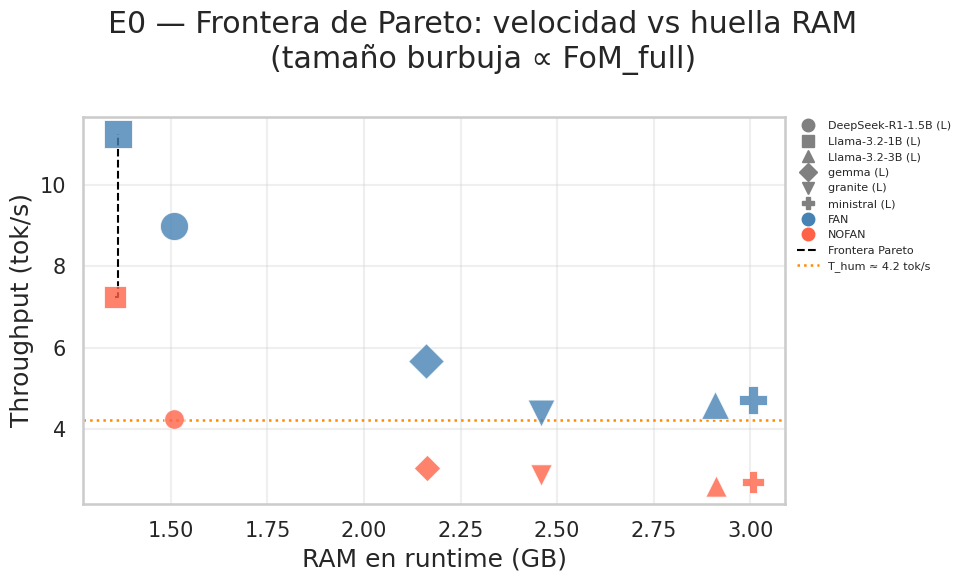

In [4]:
# ── Figura 2 — Frontera de Pareto: tok/s vs huella RAM ──────────────────────
# x=RAM en runtime (GB), y=tok/s, burbuja∝FoM_full, forma=modelo, color=FAN/NOFAN
try:
    def _pf(df, x_col, y_col, x_lower=True, y_lower=False):
        pts = df[[x_col, y_col]].to_numpy()
        n = len(pts)
        dom = [False] * n
        for i in range(n):
            for j in range(n):
                if i == j: continue
                xok = (pts[j,0] <= pts[i,0]) if x_lower else (pts[j,0] >= pts[i,0])
                yok = (pts[j,1] <= pts[i,1]) if y_lower else (pts[j,1] >= pts[i,1])
                if xok and yok and (pts[j,0] != pts[i,0] or pts[j,1] != pts[i,1]):
                    dom[i] = True; break
        return df.iloc[[not d for d in dom]].sort_values(x_col)

    # RAM runtime desde hw_df
    _fom_pareto = fom_df.copy()
    _hw_p = hw_df if "hw_df" in vars() else pd.DataFrame()
    if not _hw_p.empty and "mem_used_bytes" in _hw_p.columns and "run_id" in _fom_pareto.columns:
        _rp = _hw_p.groupby("run_id")["mem_used_bytes"].mean().reset_index()
        _rp["ram_used_gb"] = _rp["mem_used_bytes"] / 1e9
        _fom_pareto = _fom_pareto.merge(_rp[["run_id","ram_used_gb"]], on="run_id", how="left")

    _need = ["ram_used_gb", "tokens_per_s_mean"]
    _pd = _fom_pareto.dropna(subset=_need).copy()

    if _pd.empty:
        print("Sin datos suficientes para Pareto.")
    else:
        _has_fom = "fom_full" in _pd.columns and _pd["fom_full"].notna().any()
        _has_fan = "fan" in _pd.columns and _pd["fan"].nunique() > 1
        _fan_colors = {True: "steelblue", False: "tomato"}
        _fan_labels = {True: "FAN", False: "NOFAN"}

        # Marcadores por modelo
        _MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "<"]
        _models_sorted = sorted(_pd["model_label"].unique())
        _mk_map = {m: _MARKER_POOL[i % len(_MARKER_POOL)]
                   for i, m in enumerate(_models_sorted)}

        fig, ax = plt.subplots(figsize=(10, 6))

        for _fan_val in ([True, False] if _has_fan else [None]):
            _sub = _pd[_pd["fan"] == _fan_val] if _fan_val is not None else _pd
            if _sub.empty: continue
            _color = _fan_colors.get(_fan_val, "steelblue")
            for _, row in _sub.iterrows():
                _sz = float(row["fom_full"]) * 400 if _has_fom and pd.notna(row.get("fom_full")) else 150
                ax.scatter(row["ram_used_gb"], row["tokens_per_s_mean"],
                           s=max(_sz, 30), c=_color, marker=_mk_map[row["model_label"]],
                           alpha=0.80, zorder=3, edgecolors="white", linewidths=0.7)

        # Frontera de Pareto
        _front = _pf(_pd, "ram_used_gb", "tokens_per_s_mean")
        if len(_front) > 1:
            ax.step(_front["ram_used_gb"], _front["tokens_per_s_mean"],
                    where="post", color="black", lw=1.5, ls="--", zorder=2)

        # Línea T_hum
        if "T_hum" in _pd.columns and _pd["T_hum"].notna().any():
            _t_hum = _pd["T_hum"].mean()
            ax.axhline(_t_hum, color="darkorange", ls=":", lw=1.8)

        ax.set_xlabel("RAM en runtime (GB)")
        ax.set_ylabel("Throughput (tok/s)")
        fig.suptitle("E0 — Frontera de Pareto: velocidad vs huella RAM\n"
                     "(tamaño burbuja ∝ FoM_full)")
        ax.grid(True, alpha=0.3)

        # Leyenda exterior: modelos (forma) + fan (color) + referencias
        from matplotlib.lines import Line2D
        _legend_h = (
            [Line2D([0],[0], marker=_mk_map[m], color="gray", markerfacecolor="gray",
                     ms=9, label=m, ls="None") for m in _models_sorted]
            + [Line2D([0],[0], marker="o", color=c, markerfacecolor=c,
                       ms=9, label=lbl, ls="None")
               for c, lbl in [("steelblue","FAN"), ("tomato","NOFAN")]]
            + [Line2D([0],[0], color="black", lw=1.5, ls="--", label="Frontera Pareto")]
        )
        if "T_hum" in _pd.columns and _pd["T_hum"].notna().any():
            _legend_h.append(
                Line2D([0],[0], color="darkorange", lw=1.8, ls=":",
                        label=f"T_hum ≈ {_pd['T_hum'].mean():.1f} tok/s")
            )
        ax.legend(handles=_legend_h, fontsize=8,
                  bbox_to_anchor=(1.01, 1), loc="upper left",
                  borderaxespad=0, framealpha=0.9)
        fig.tight_layout()
        plt.show()

except NameError:
    print("fom_df no definido — ejecuta primero la celda de FoM_full.")
except Exception as e:
    import traceback; traceback.print_exc()


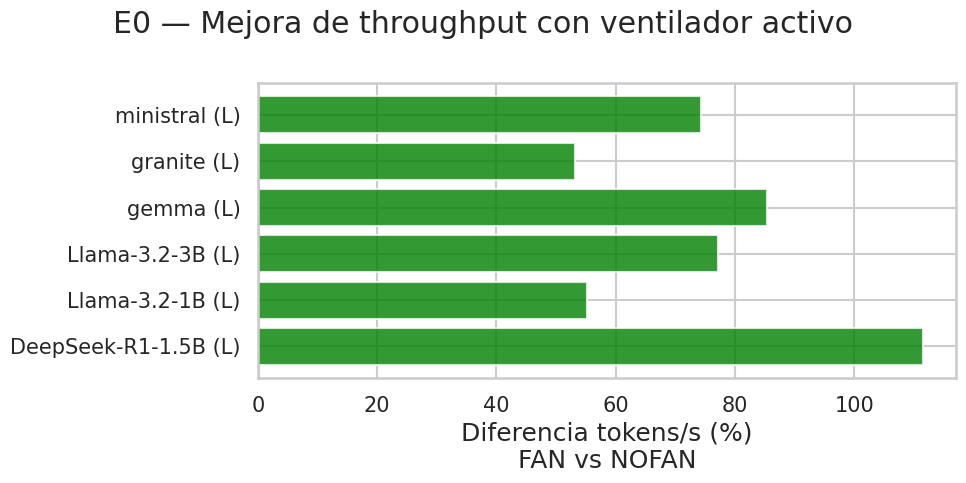


Diferencia absoluta y porcentual (FAN vs NOFAN):


,diff_tok_s,diff_pct
model_label,,
DeepSeek-R1-1.5B (L),4.733,111.5
Llama-3.2-1B (L),3.993,55.2
Llama-3.2-3B (L),2.006,77.1
gemma (L),2.616,85.3
granite (L),1.531,53.2
ministral (L),2.017,74.3


In [5]:
if (not summary.empty and 'fan' in summary.columns
        and 'tokens_per_s_mean' in summary.columns):
    fan_mean   = summary[summary['fan'] == True].groupby('model_label')['tokens_per_s_mean'].mean()
    nofan_mean = summary[summary['fan'] == False].groupby('model_label')['tokens_per_s_mean'].mean()
    common = fan_mean.index.intersection(nofan_mean.index)
    if len(common) > 0:
        diff     = fan_mean.loc[common] - nofan_mean.loc[common]
        diff_pct = diff / nofan_mean.loc[common] * 100
        fig, ax = plt.subplots(figsize=(10, 5))
        colors = ['green' if v > 0 else 'red' for v in diff_pct]
        ax.barh(common.tolist(), diff_pct.values, color=colors, alpha=0.8)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel('Diferencia tokens/s (%)\nFAN vs NOFAN')
        fig.suptitle('E0 — Mejora de throughput con ventilador activo')
        ax.tick_params(axis='y', rotation=0)
        plt.tight_layout()
        plt.show()

        print('\nDiferencia absoluta y porcentual (FAN vs NOFAN):')
        display(pd.DataFrame({'diff_tok_s': diff.round(3), 'diff_pct': diff_pct.round(1)}))
    else:
        print('Sin modelos comunes entre FAN y NOFAN.')
else:
    print('Sin datos para comparativa fan/nofan.')

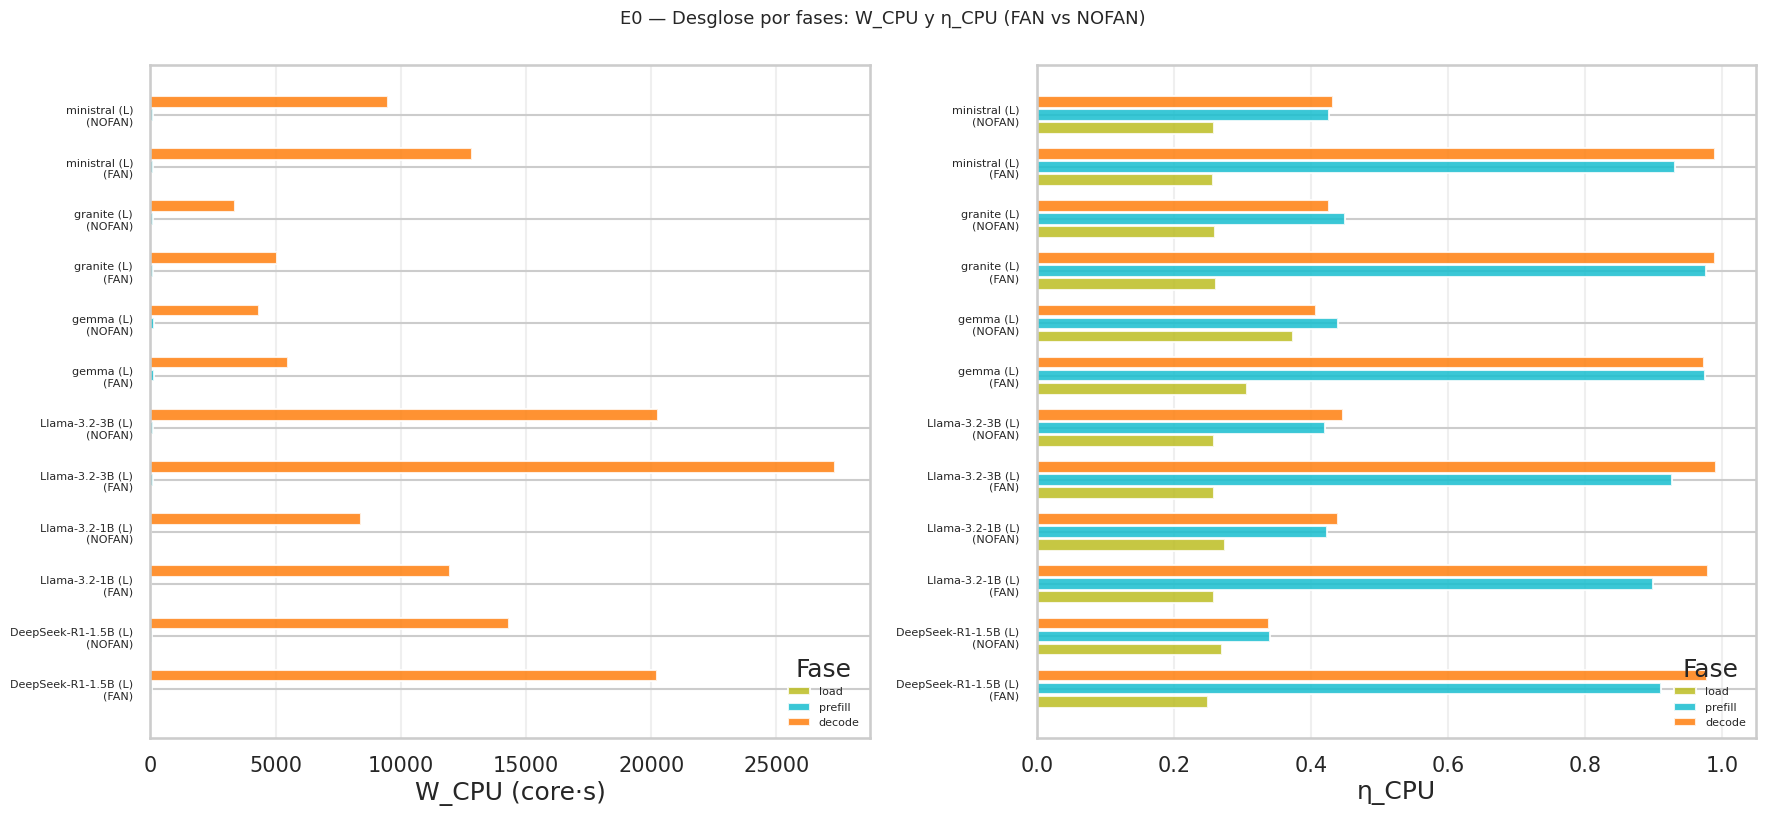

In [6]:
phase_df = coll.cpu_work_by_phase_df() if len(coll.runs) > 0 else pd.DataFrame()

if not phase_df.empty:
    if "run_id" in phase_df.columns:
        phase_df = phase_df.merge(
            summary[["run_id","config_label","fan"]].drop_duplicates(),
            on="run_id", how="left"
        )
    elif "model_label" in phase_df.columns and "fan" in phase_df.columns:
        phase_df = phase_df.merge(
            summary[["model_label","fan","config_label"]].drop_duplicates(),
            on=["model_label","fan"], how="left"
        )
    if "config_label" not in phase_df.columns:
        phase_df["config_label"] = phase_df.get("model_label", "?")

    PHASE_ORDER  = ["load","prefill","decode"]
    PHASE_COLORS = {"load":"#bcbd22","prefill":"#17becf","decode":"#ff7f0e"}
    configs = sorted(phase_df["config_label"].unique())
    y = np.arange(len(configs))
    width = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(configs) * 0.7)))
    for ax, (metric, xlabel, xlim) in zip(axes, [
        ("cpu_work_core_s", "W_CPU (core\u00b7s)", None),
        ("cpu_efficiency",  "\u03b7_CPU",           (0, 1.05)),
    ]):
        for i, phase in enumerate(PHASE_ORDER):
            sub  = phase_df[phase_df["phase"] == phase]
            vals = [sub[sub["config_label"] == c][metric].mean()
                    if c in sub["config_label"].values else float('nan')
                    for c in configs]
            ax.barh(y + (i - 1) * width, vals, width * 0.9,
                    label=phase, color=PHASE_COLORS[phase], alpha=0.85)
        ax.set_yticks(y)
        ax.set_yticklabels(configs, fontsize=8)
        ax.set_xlabel(xlabel)
        if xlim: ax.set_xlim(*xlim)
        ax.legend(title="Fase", loc="lower right", fontsize=8)
        ax.grid(True, axis='x', alpha=0.3)
    fig.suptitle("E0 \u2014 Desglose por fases: W_CPU y \u03b7_CPU (FAN vs NOFAN)", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print('Sin datos de fases de CPU work (requiere hw data con fases anotadas).')


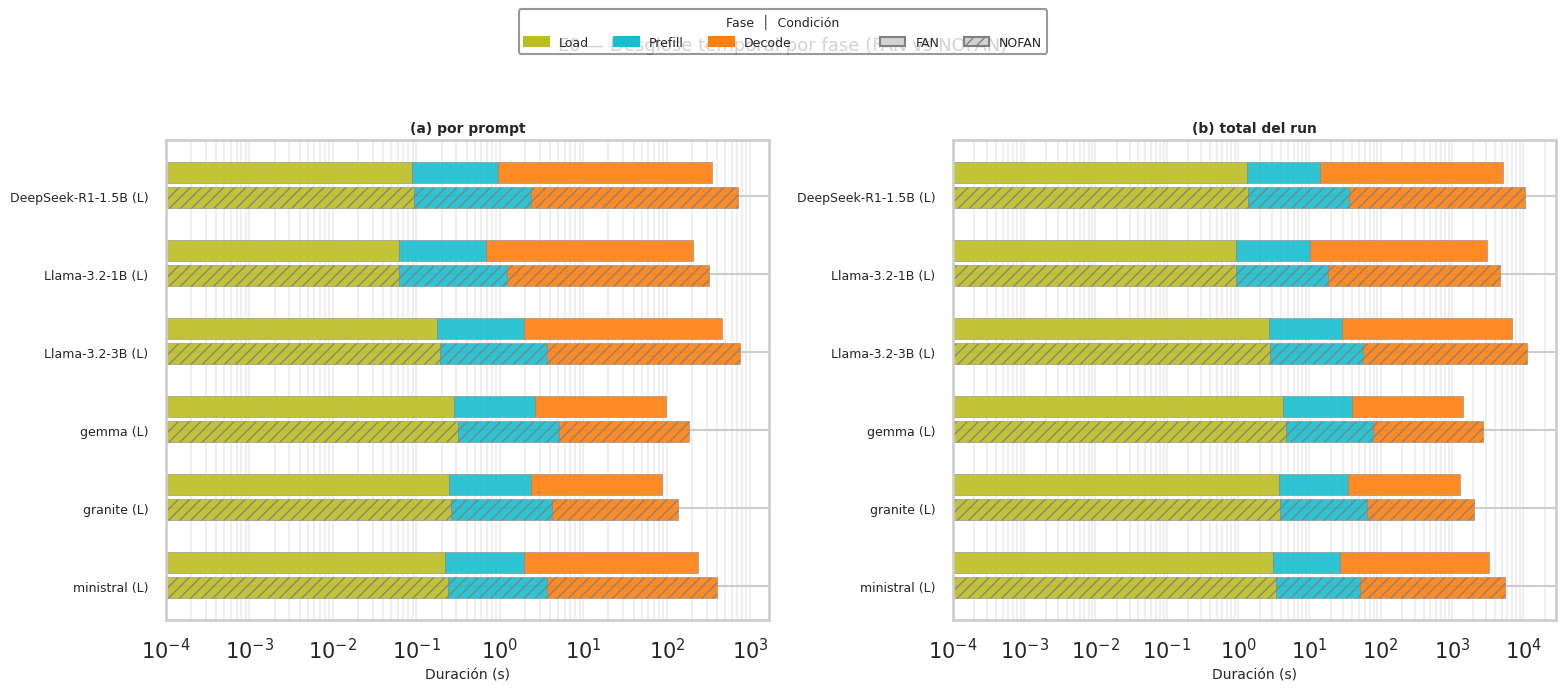

Exportado: figures/05_Resultados/E0/e0_desglose_fases.png


In [7]:
# ── E0.4 — Desglose temporal por fase (FAN vs NOFAN) ─────────────────────────
import os
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

_export_e04 = "figures/05_Resultados/E0/e0_desglose_fases.png"

# Construir dataframe de duraciones por fase directamente de los runs
_phase_rows = []
for _run in coll.runs:
    _rid   = _run.run_id
    _label = summary.loc[summary["run_id"] == _rid, "model_label"].values
    _fan   = summary.loc[summary["run_id"] == _rid, "fan"].values
    if len(_label) == 0:
        continue
    _non_empty = [p for p in _run.prompts if not p.is_empty_generation]
    if not _non_empty:
        continue
    _phase_rows.append({
        "model_label":     _label[0],
        "fan":             bool(_fan[0]),
        "load_s":          np.mean([p.load_duration_ns / 1e9 for p in _non_empty]),
        "prefill_s":       np.mean([p.prompt_eval_duration_ns / 1e9 for p in _non_empty]),
        "decode_s":        np.mean([p.eval_duration_ns / 1e9 for p in _non_empty]),
        "load_total_s":    np.sum([p.load_duration_ns / 1e9 for p in _non_empty]),
        "prefill_total_s": np.sum([p.prompt_eval_duration_ns / 1e9 for p in _non_empty]),
        "decode_total_s":  np.sum([p.eval_duration_ns / 1e9 for p in _non_empty]),
    })
_pf2 = pd.DataFrame(_phase_rows)

if not _pf2.empty:
    _PHASES_A = [("load_s",          "Load",    "#bcbd22"),
                 ("prefill_s",       "Prefill", "#17becf"),
                 ("decode_s",        "Decode",  "#ff7f0e")]
    _PHASES_B = [("load_total_s",    "Load",    "#bcbd22"),
                 ("prefill_total_s", "Prefill", "#17becf"),
                 ("decode_total_s",  "Decode",  "#ff7f0e")]

    _models = sorted(_pf2["model_label"].unique())
    _n   = len(_models)
    _bh  = 0.30        # altura de barra
    _gap = 0.05        # separación FAN/NOFAN dentro del mismo modelo
    _sep = 0.45        # separación entre grupos de modelos
    _step = 2 * _bh + _gap + _sep

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, _n * 1.1)))
    fig.suptitle("E0 — Desglose temporal por fase (FAN vs NOFAN)", fontsize=13, y=1.02)

    for ax, phases, subtitle in [
        (axes[0], _PHASES_A, "(a) por prompt"),
        (axes[1], _PHASES_B, "(b) total del run"),
    ]:
        ax.set_xscale("log")
        _yticks, _ytlabels = [], []

        for mi, model in enumerate(_models):
            _y_group = mi * _step
            _yticks.append(_y_group + _bh + _gap / 2)
            _ytlabels.append(model)

            for fi, (fan_val, hatch) in enumerate([(True, ""), (False, "///")]):
                sub = _pf2[(_pf2["model_label"] == model) & (_pf2["fan"] == fan_val)]
                if sub.empty:
                    continue
                y_pos = _y_group + fi * (_bh + _gap)
                left = 1e-4  # inicio positivo para escala log
                for col, lbl, color in phases:
                    val = max(float(sub[col].values[0]), 1e-4)
                    ax.barh(y_pos, val, height=_bh, left=left,
                            color=color, hatch=hatch,
                            edgecolor="grey", linewidth=0.4, alpha=0.9)
                    left += val

        ax.set_yticks(_yticks)
        ax.set_yticklabels(_ytlabels, fontsize=9)
        ax.set_xlabel("Duración (s)", fontsize=10)
        ax.set_title(subtitle, fontsize=10)
        ax.grid(True, axis="x", alpha=0.3, which="both")
        ax.invert_yaxis()

    # Leyenda doble: colores = Fase, relleno = Condición
    _ph_handles = [mpatches.Patch(color=c, label=l) for _, l, c in _PHASES_A]
    _cd_handles = [
        mpatches.Patch(facecolor="lightgrey", edgecolor="grey", label="FAN"),
        mpatches.Patch(facecolor="lightgrey", edgecolor="grey", hatch="///", label="NOFAN"),
    ]
    _sep_h = Line2D([0], [0], color="none", label=" ")
    fig.legend(handles=_ph_handles + [_sep_h] + _cd_handles,
               loc="upper center", bbox_to_anchor=(0.5, 1.07),
               ncol=len(_ph_handles) + 1 + len(_cd_handles),
               fontsize=9, title="Fase  │  Condición", title_fontsize=9,
               frameon=True, edgecolor="grey")

    plt.tight_layout()
    os.makedirs(os.path.dirname(_export_e04), exist_ok=True)
    fig.savefig(_export_e04, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Exportado: {_export_e04}")
else:
    print("Sin datos de fases temporales.")


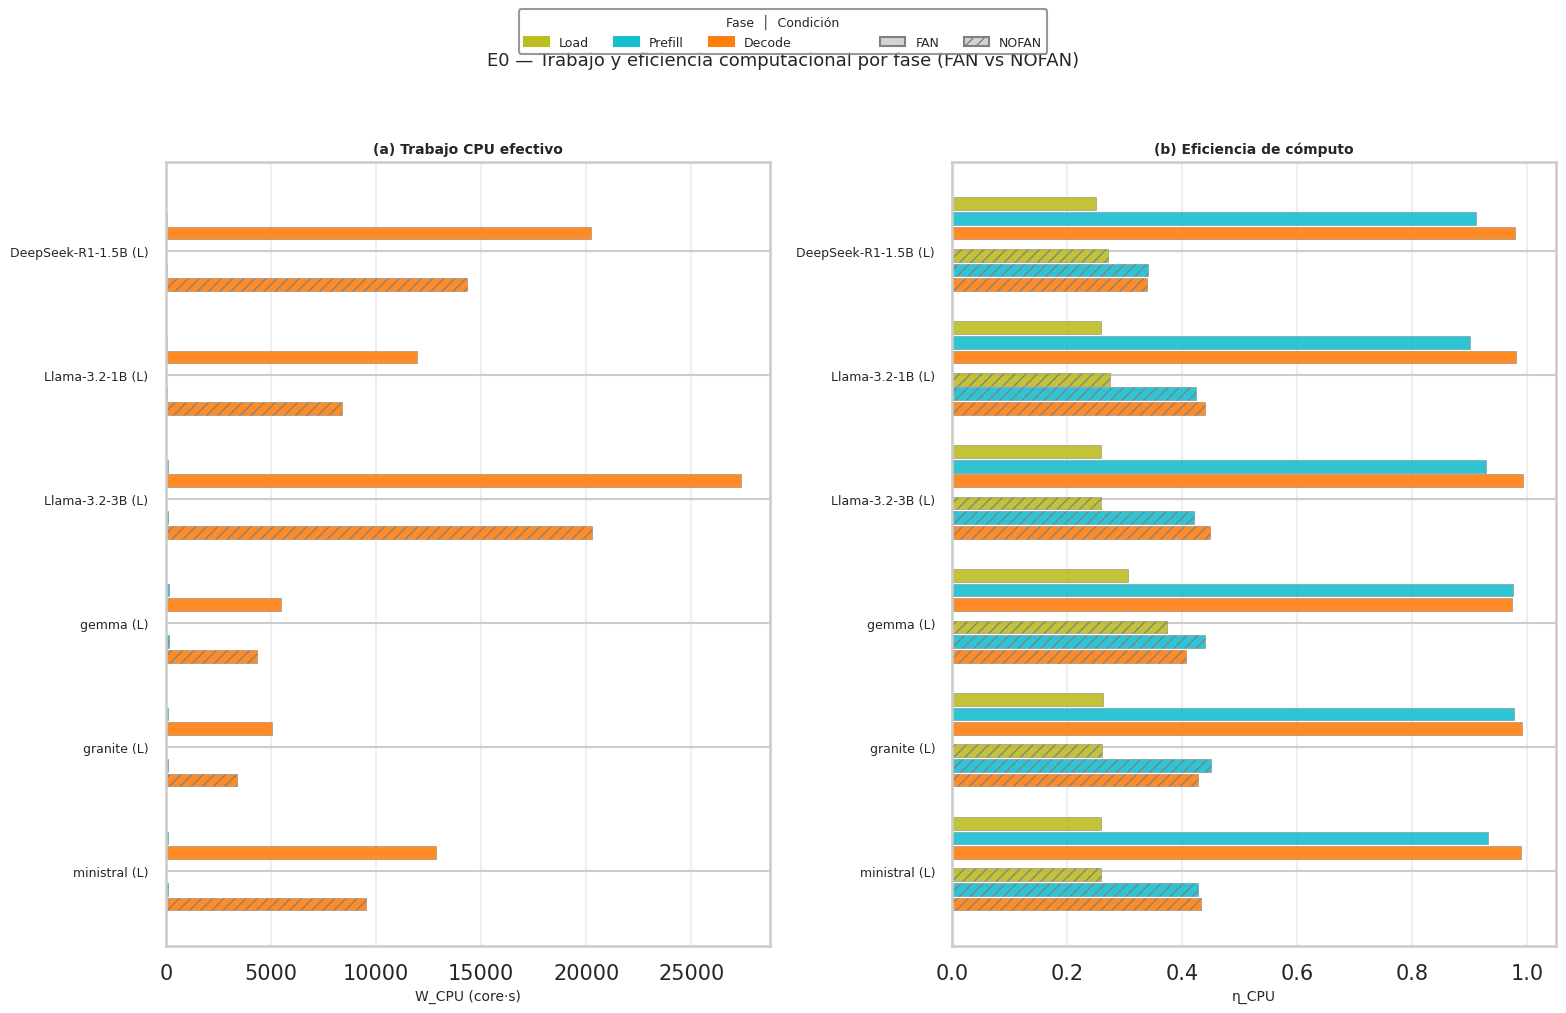

Exportado: figures/05_Resultados/E0/e0_trabajo_fases.png


In [8]:
# ── E0.5 — Trabajo y eficiencia computacional por fase (FAN vs NOFAN) ─────────
import os
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

_export_e05 = "figures/05_Resultados/E0/e0_trabajo_fases.png"

# Obtener phase_df limpio directamente de la colección (incluye fan desde el inicio)
_pf_cpu = coll.cpu_work_by_phase_df() if len(coll.runs) > 0 else pd.DataFrame()

if not _pf_cpu.empty and "fan" in _pf_cpu.columns:
    _PHASE_C = [("load",    "Load",    "#bcbd22"),
                ("prefill", "Prefill", "#17becf"),
                ("decode",  "Decode",  "#ff7f0e")]

    _models = sorted(_pf_cpu["model_label"].unique())
    _n   = len(_models)
    _bh  = 0.20        # altura de sub-barra por fase
    _ph_gap  = 0.03    # separación entre fases dentro del mismo grupo
    _cond_gap = 0.12   # separación entre grupo FAN y NOFAN
    _sep = 0.45        # separación entre modelos
    _group_h = 3 * (_bh + _ph_gap)  # altura del bloque de 3 fases de una condición
    _step = 2 * _group_h + _cond_gap + _sep

    fig, axes = plt.subplots(1, 2, figsize=(16, max(6, _n * 1.6)))
    fig.suptitle("E0 — Trabajo y eficiencia computacional por fase (FAN vs NOFAN)",
                 fontsize=13, y=1.02)

    for ax, metric, xlabel, xlim, subtitle in [
        (axes[0], "cpu_work_core_s", "W_CPU (core·s)", None,       "(a) Trabajo CPU efectivo"),
        (axes[1], "cpu_efficiency",  "η_CPU",           (0, 1.05), "(b) Eficiencia de cómputo"),
    ]:
        _yticks, _ytlabels = [], []

        for mi, model in enumerate(_models):
            _y_model = mi * _step
            _yticks.append(_y_model + _group_h + _cond_gap / 2)
            _ytlabels.append(model)

            for fi, (fan_val, hatch) in enumerate([(True, ""), (False, "///")]):
                y_base = _y_model + fi * (_group_h + _cond_gap)
                for pi, (ph, ph_lbl, color) in enumerate(_PHASE_C):
                    sub = _pf_cpu[
                        (_pf_cpu["model_label"] == model) &
                        (_pf_cpu["fan"] == fan_val) &
                        (_pf_cpu["phase"] == ph)
                    ]
                    if sub.empty:
                        continue
                    val = float(sub[metric].mean())
                    if not np.isfinite(val):
                        continue
                    y_pos = y_base + pi * (_bh + _ph_gap)
                    ax.barh(y_pos, val, height=_bh,
                            color=color, hatch=hatch,
                            edgecolor="grey", linewidth=0.4, alpha=0.9)

        ax.set_yticks(_yticks)
        ax.set_yticklabels(_ytlabels, fontsize=9)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_title(subtitle, fontsize=10)
        if xlim:
            ax.set_xlim(*xlim)
        ax.grid(True, axis="x", alpha=0.3)
        ax.invert_yaxis()

    _ph_handles = [mpatches.Patch(color=c, label=l) for _, l, c in _PHASE_C]
    _cd_handles = [
        mpatches.Patch(facecolor="lightgrey", edgecolor="grey", label="FAN"),
        mpatches.Patch(facecolor="lightgrey", edgecolor="grey", hatch="///", label="NOFAN"),
    ]
    _sep_h = Line2D([0], [0], color="none", label=" ")
    fig.legend(handles=_ph_handles + [_sep_h] + _cd_handles,
               loc="upper center", bbox_to_anchor=(0.5, 1.07),
               ncol=len(_ph_handles) + 1 + len(_cd_handles),
               fontsize=9, title="Fase  │  Condición", title_fontsize=9,
               frameon=True, edgecolor="grey")

    plt.tight_layout()
    os.makedirs(os.path.dirname(_export_e05), exist_ok=True)
    fig.savefig(_export_e05, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Exportado: {_export_e05}")
else:
    _missing = []
    if _pf_cpu.empty: _missing.append("phase_df vacío (sin hw data)")
    if "fan" not in _pf_cpu.columns: _missing.append(f"sin columna 'fan' (cols: {list(_pf_cpu.columns)})")
    print("Sin datos:", "; ".join(_missing) if _missing else "error desconocido")


---
# 📎 ANEXO — Material complementario (no incluido en la memoria principal)
---

Las siguientes figuras se conservan para validación y detalle; no forman parte de las 5 figuras de la memoria.


## 1. Validación de datos

In [9]:
if not summary.empty:
    _cols = [c for c in ['model_label', 'fan', 'engine',
                          'n_prompts', 'n_empty_generations', 'throttled_ratio']
             if c in summary.columns]
    display(summary[_cols].sort_values(['model_label', 'fan']).reset_index(drop=True))

    # Matriz del experimento: modelos × fan
    if 'tokens_per_s_mean' in summary.columns:
        matrix = summary.pivot_table(
            index='model_label', columns='fan',
            values='tokens_per_s_mean', aggfunc='count'
        ).fillna(0).astype(int)
        print('\nRuns por modelo × refrigeración (count):')
        display(matrix)

    alertas = summary[
        (summary.get('n_empty_generations', pd.Series(0, index=summary.index)) > 0) |
        (summary.get('throttled_ratio', pd.Series(0.0, index=summary.index)) > 0.8)
    ]
    if not alertas.empty:
        print('\n⚠️ Alertas:')
        _acols = [c for c in ['model_label', 'fan', 'n_empty_generations', 'throttled_ratio']
                  if c in alertas.columns]
        display(alertas[_acols])
    else:
        print('\n✅ Sin alertas.')
else:
    print('Sin datos cargados.')


,model_label,fan,engine,n_prompts,n_empty_generations,throttled_ratio
0,DeepSeek-R1-1.5B (L),False,LLAMA,15,0,0.999750
1,DeepSeek-R1-1.5B (L),True,LLAMA,15,0,0.000000
2,Llama-3.2-1B (L),False,LLAMA,15,0,0.998837
3,Llama-3.2-1B (L),True,LLAMA,15,0,0.000000
4,Llama-3.2-3B (L),False,LLAMA,15,0,0.999479
5,Llama-3.2-3B (L),True,LLAMA,15,0,0.000000
6,gemma (L),False,LLAMA,15,0,0.997967
7,gemma (L),True,LLAMA,15,0,0.000000
8,granite (L),False,LLAMA,15,0,0.997107
9,granite (L),True,LLAMA,15,0,0.000000



Runs por modelo × refrigeración (count):


fan,False,True
model_label,,
DeepSeek-R1-1.5B (L),1,1
Llama-3.2-1B (L),1,1
Llama-3.2-3B (L),1,1
gemma (L),1,1
granite (L),1,1
ministral (L),1,1



⚠️ Alertas:


,model_label,fan,n_empty_generations,throttled_ratio
0,ministral (L),True,1,0.000000
6,ministral (L),False,1,0.998979
7,Llama-3.2-3B (L),False,0,0.999479
8,Llama-3.2-1B (L),False,0,0.998837
9,granite (L),False,0,0.997107
10,gemma (L),False,0,0.997967
11,DeepSeek-R1-1.5B (L),False,0,0.999750


## 2. Evolución temporal del hardware

Timelines de temperatura, potencia y swap durante el run completo,
agrupados por modelo y refrigeración. Permiten identificar el momento
en que aparece el throttling térmico y su evolución.

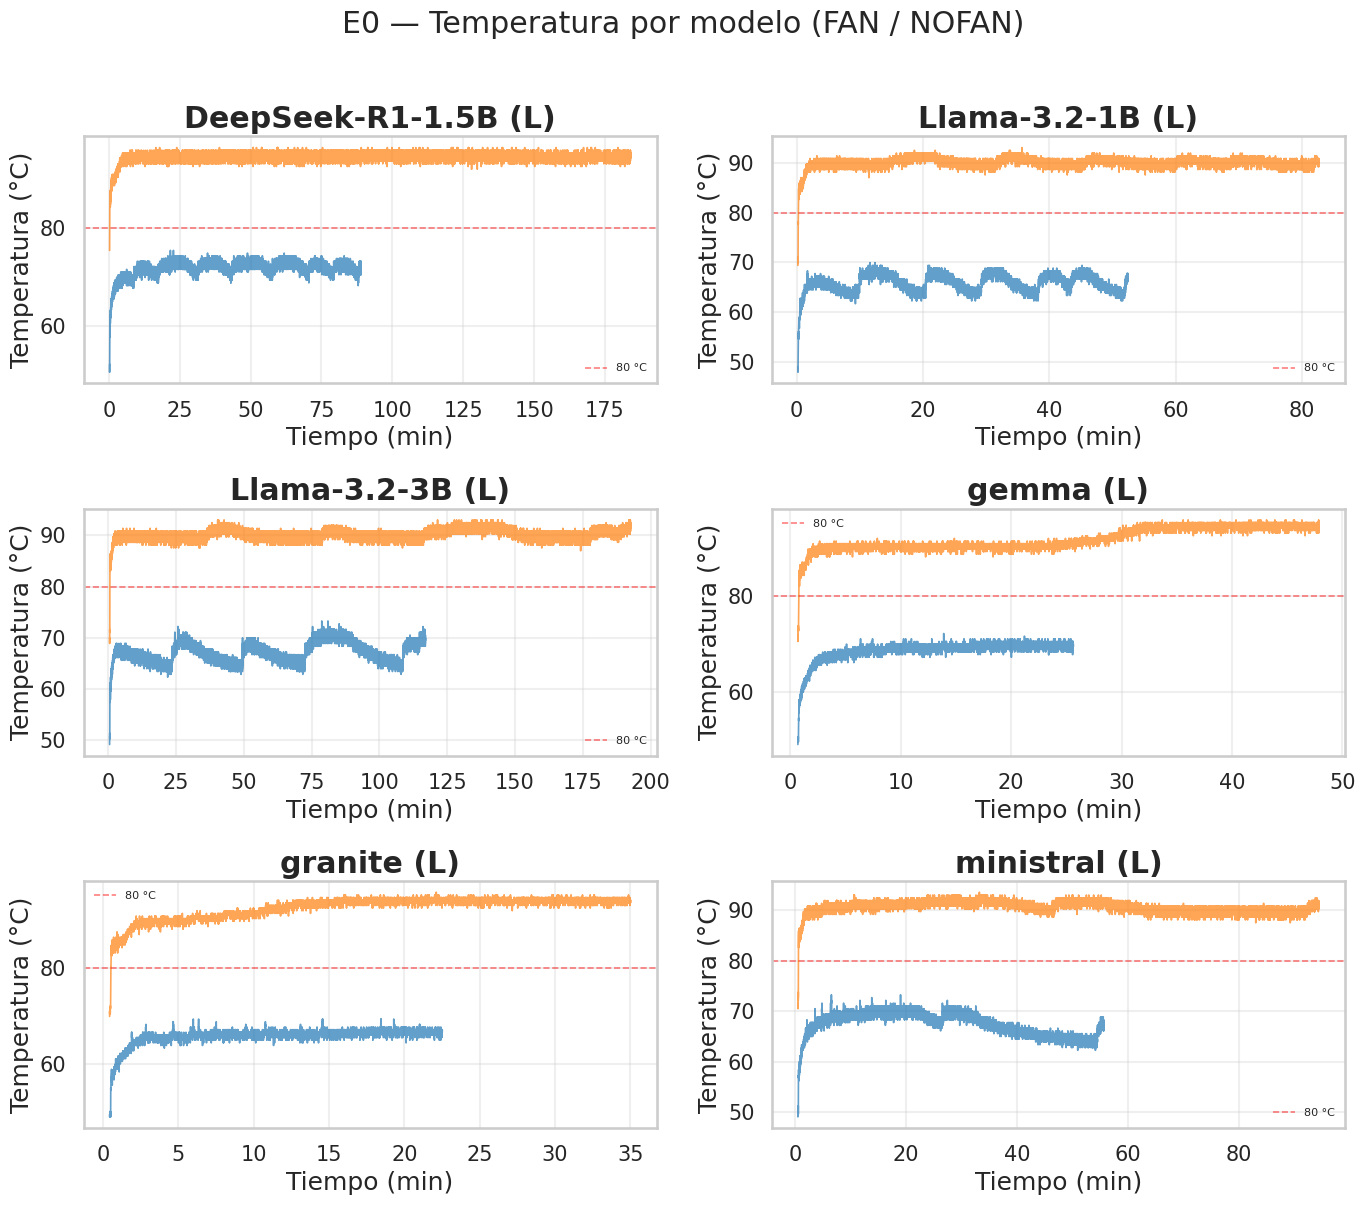

In [10]:
def _plot_timeline(hw_data, y_col, ylabel, suptitle, hline=None):
    models = sorted(hw_data['model_label'].unique())
    if not models:
        print(f'Sin datos para {suptitle}')
        return
    ncols = 2
    nrows = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        sub = hw_data[hw_data['model_label'] == model]
        if sub.empty:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        t_max = sub['t_rel_s'].max()
        x_vals = sub['t_rel_s'] / 60 if t_max > 1800 else sub['t_rel_s']
        ax.set_xlabel('Tiempo (min)' if t_max > 1800 else 'Tiempo (s)')
        for rid in sub['run_id'].unique():
            s = sub[sub['run_id'] == rid].sort_values('t_rel_s')
            xv = s['t_rel_s'] / 60 if t_max > 1800 else s['t_rel_s']
            ax.plot(xv.values, s[y_col].values, alpha=0.7, lw=1.2)
        if hline is not None:
            ax.axhline(hline, ls='--', color='red', alpha=0.5, lw=1.2,
                       label=f'{hline} °C')
            ax.legend(fontsize=8)
        ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight='bold')
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_df.empty:
    _plot_timeline(hw_df, 'temperature_c', 'Temperatura (°C)',
                   'E0 — Temperatura por modelo (FAN / NOFAN)', hline=80)
else:
    print('Sin datos de hardware para timelines de temperatura.')


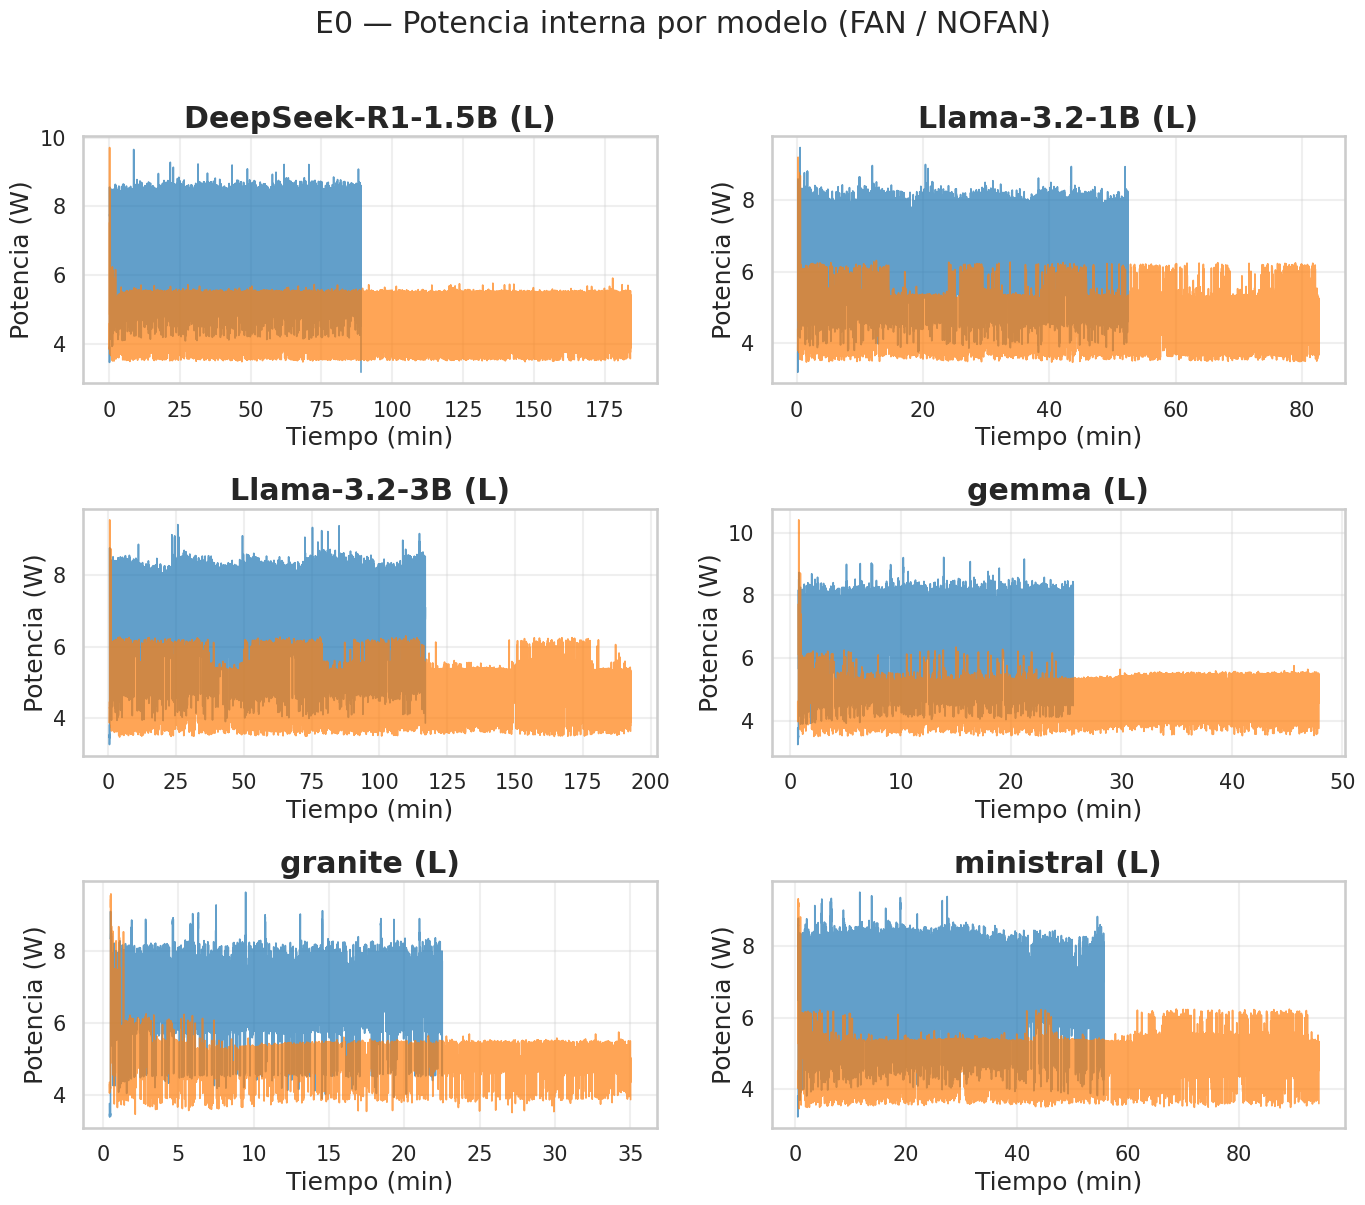

In [11]:
if not hw_df.empty:
    _plot_timeline(hw_df, 'internal_power_w', 'Potencia (W)',
                   'E0 — Potencia interna por modelo (FAN / NOFAN)')
else:
    print('Sin datos de hardware para timelines de potencia.')


Run representativo (más throttleado): DeepSeek-R1-Distill-Qwen-1.5B-Q4_K_M


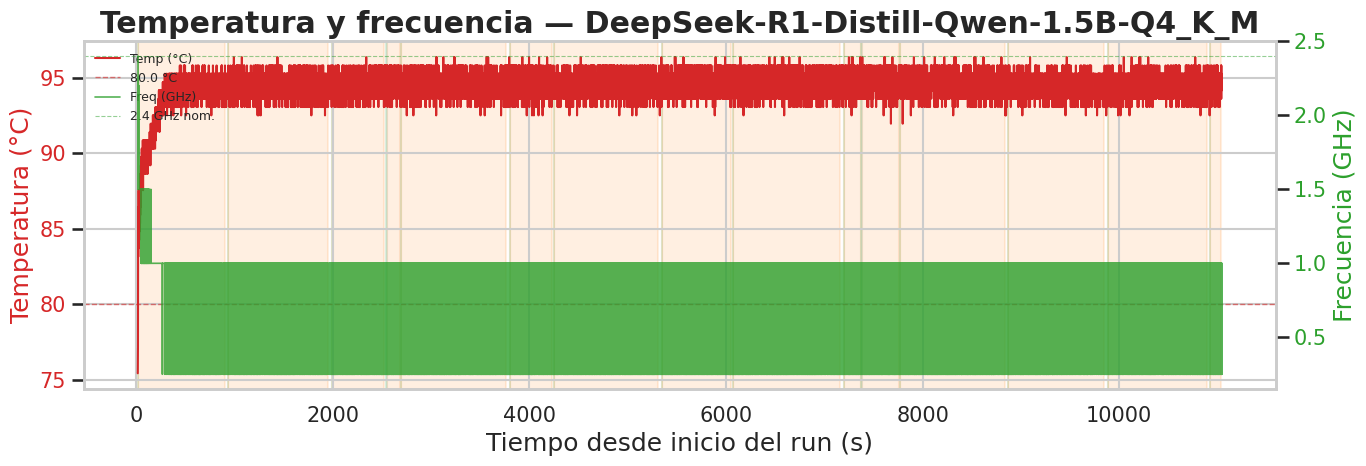

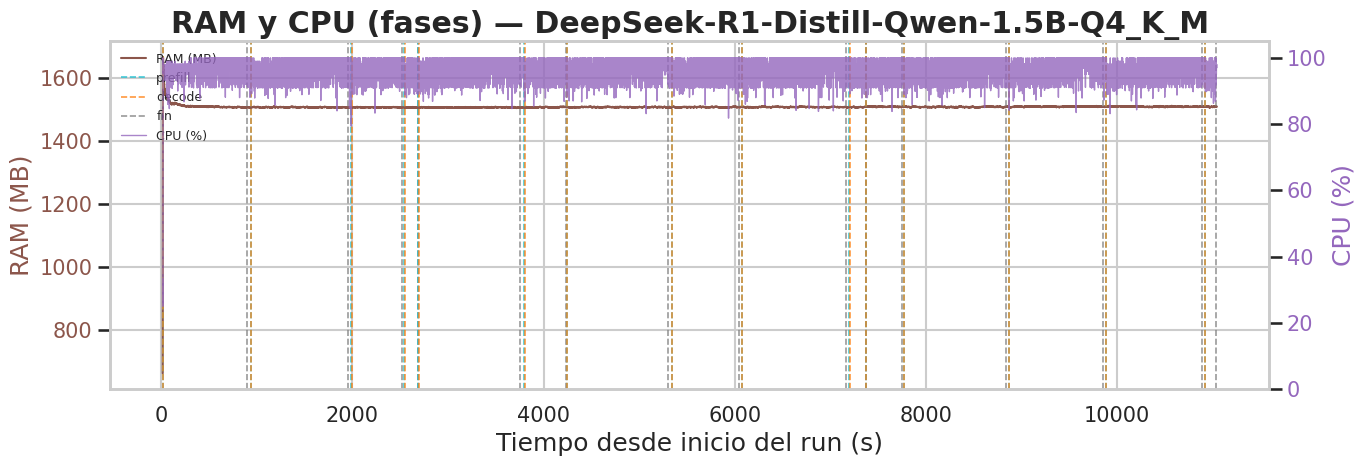

In [12]:
if not hw_df.empty and not summary.empty and 'throttled_ratio' in summary.columns:
    _best = summary.sort_values('throttled_ratio', ascending=False)
    _rep_id = _best['run_id'].iloc[0] if 'run_id' in _best.columns else None
    if _rep_id:
        run_rep = next((r for r in coll.runs if r.run_id == _rep_id), None)
        hw_rep  = hw_df[hw_df['run_id'] == _rep_id]
        if run_rep is not None and not hw_rep.empty:
            print(f'Run representativo (más throttleado): {run_rep.model_short}')
            try:
                fig = temp_freq_dual(hw_rep, run_rep)
                plt.show()
            except Exception as e:
                print(f'temp_freq_dual: {e}')
            try:
                fig = cpu_memory_dual_phases(hw_rep, run_rep)
                plt.show()
            except Exception as e:
                print(f'cpu_memory_dual_phases: {e}')
        else:
            print('Run representativo no encontrado.')
    else:
        print('Sin run_id disponible.')
else:
    print('Sin datos de hardware o throttled_ratio para run representativo.')


## 3. Distribuciones del entorno hardware

Distribuciones estadísticas de las métricas de hardware agregando todas
las muestras de todos los runs del experimento.

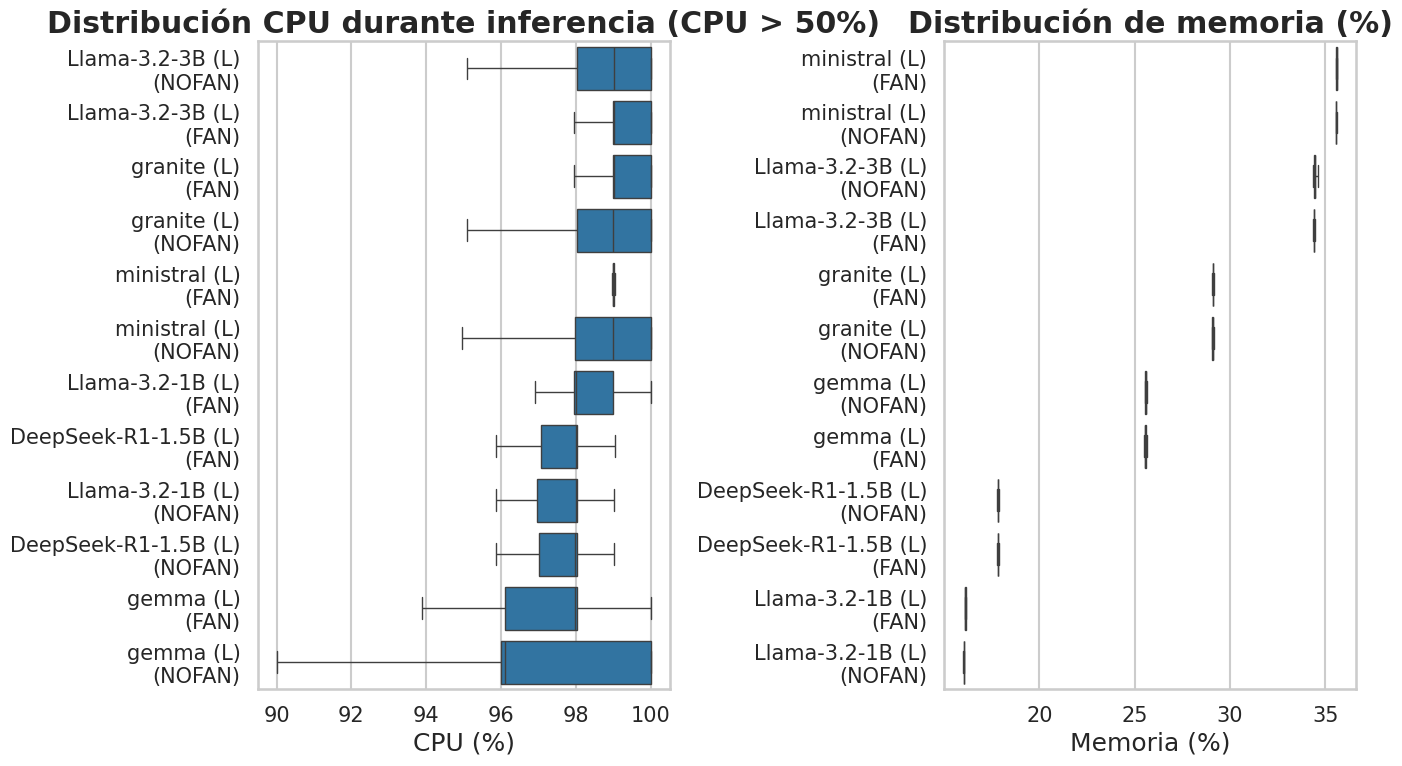

In [13]:
if not hw_df.empty:
    label_col = "config_label" if "config_label" in hw_df.columns else "model_label"
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    active = hw_df[hw_df['cpu_usage_pct'] > 50].copy()
    if not active.empty:
        order = (active.groupby(label_col)['cpu_usage_pct']
                 .median().sort_values(ascending=False).index.tolist())
        sns.boxplot(data=active, y=label_col, x='cpu_usage_pct',
                    order=order, showfliers=False, ax=axes[0])
        axes[0].set_title('Distribución CPU durante inferencia (CPU > 50%)')
        axes[0].set_xlabel('CPU (%)')
        axes[0].set_ylabel('')
    if 'mem_pct' in hw_df.columns:
        order_mem = (hw_df.groupby(label_col)['mem_pct']
                     .median().sort_values(ascending=False).index.tolist())
        sns.boxplot(data=hw_df, y=label_col, x='mem_pct',
                    order=order_mem, showfliers=False, ax=axes[1])
        axes[1].set_title('Distribución de memoria (%)')
        axes[1].set_xlabel('Memoria (%)')
        axes[1].set_ylabel('')
    fig.tight_layout()
    plt.show()
else:
    print('Sin datos de hardware para boxplots.')


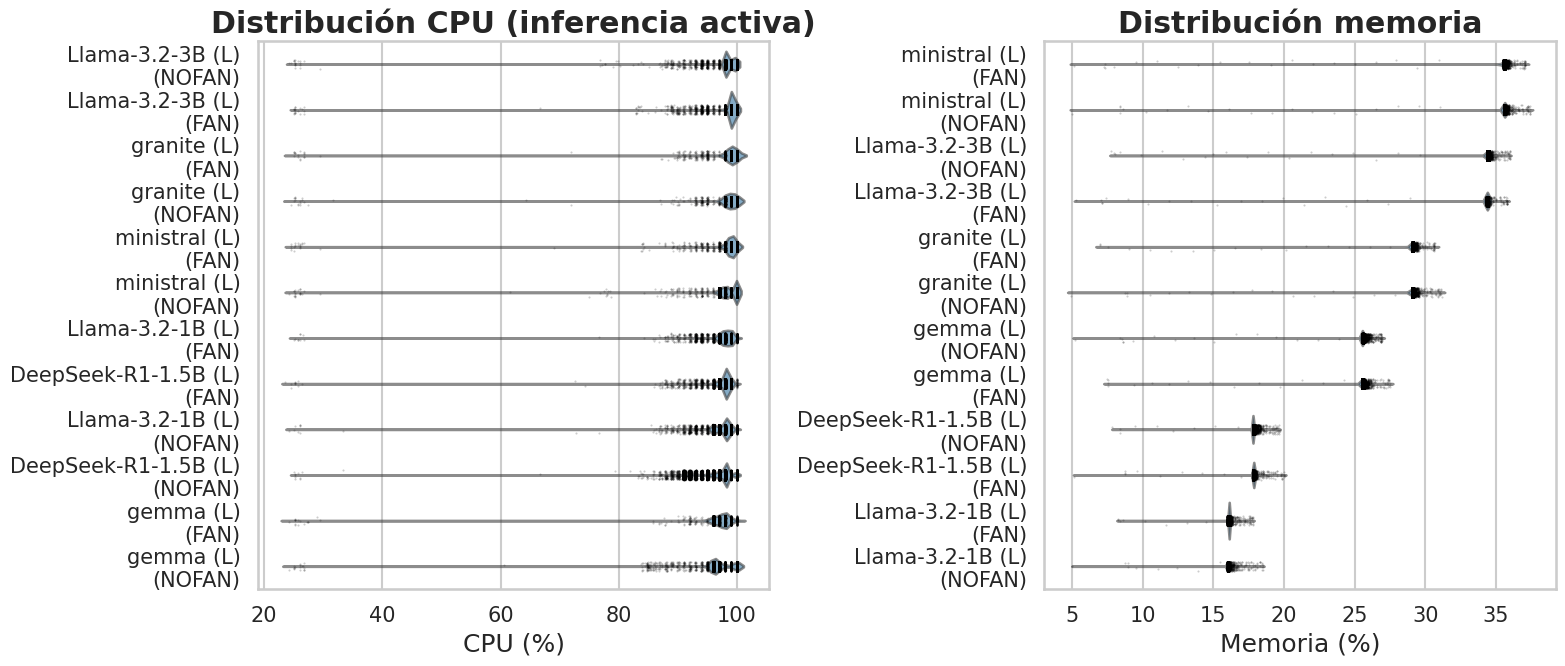

In [14]:
if not hw_df.empty:
    label_col = "config_label" if "config_label" in hw_df.columns else "model_label"
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, (col, xlabel, title) in zip(axes, [
        ('cpu_usage_pct', 'CPU (%)',     'Distribución CPU (inferencia activa)'),
        ('mem_pct',       'Memoria (%)', 'Distribución memoria'),
    ]):
        if col not in hw_df.columns:
            ax.text(0.5, 0.5, f'{col} no disponible', ha='center', va='center',
                    transform=ax.transAxes); continue
        data = hw_df[hw_df['cpu_usage_pct'] > 10].copy() if 'cpu' in col else hw_df.copy()
        if data.empty:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center',
                    transform=ax.transAxes); continue
        order = (data.groupby(label_col)[col]
                 .median().sort_values(ascending=False).index.tolist())
        sns.violinplot(data=data, y=label_col, x=col,
                       order=order, inner=None, alpha=0.6, ax=ax)
        sns.stripplot(data=data, y=label_col, x=col,
                      order=order, size=1.5, alpha=0.2, color='black', ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('')
    fig.tight_layout()
    plt.show()
else:
    print('Sin datos de hardware para violines.')


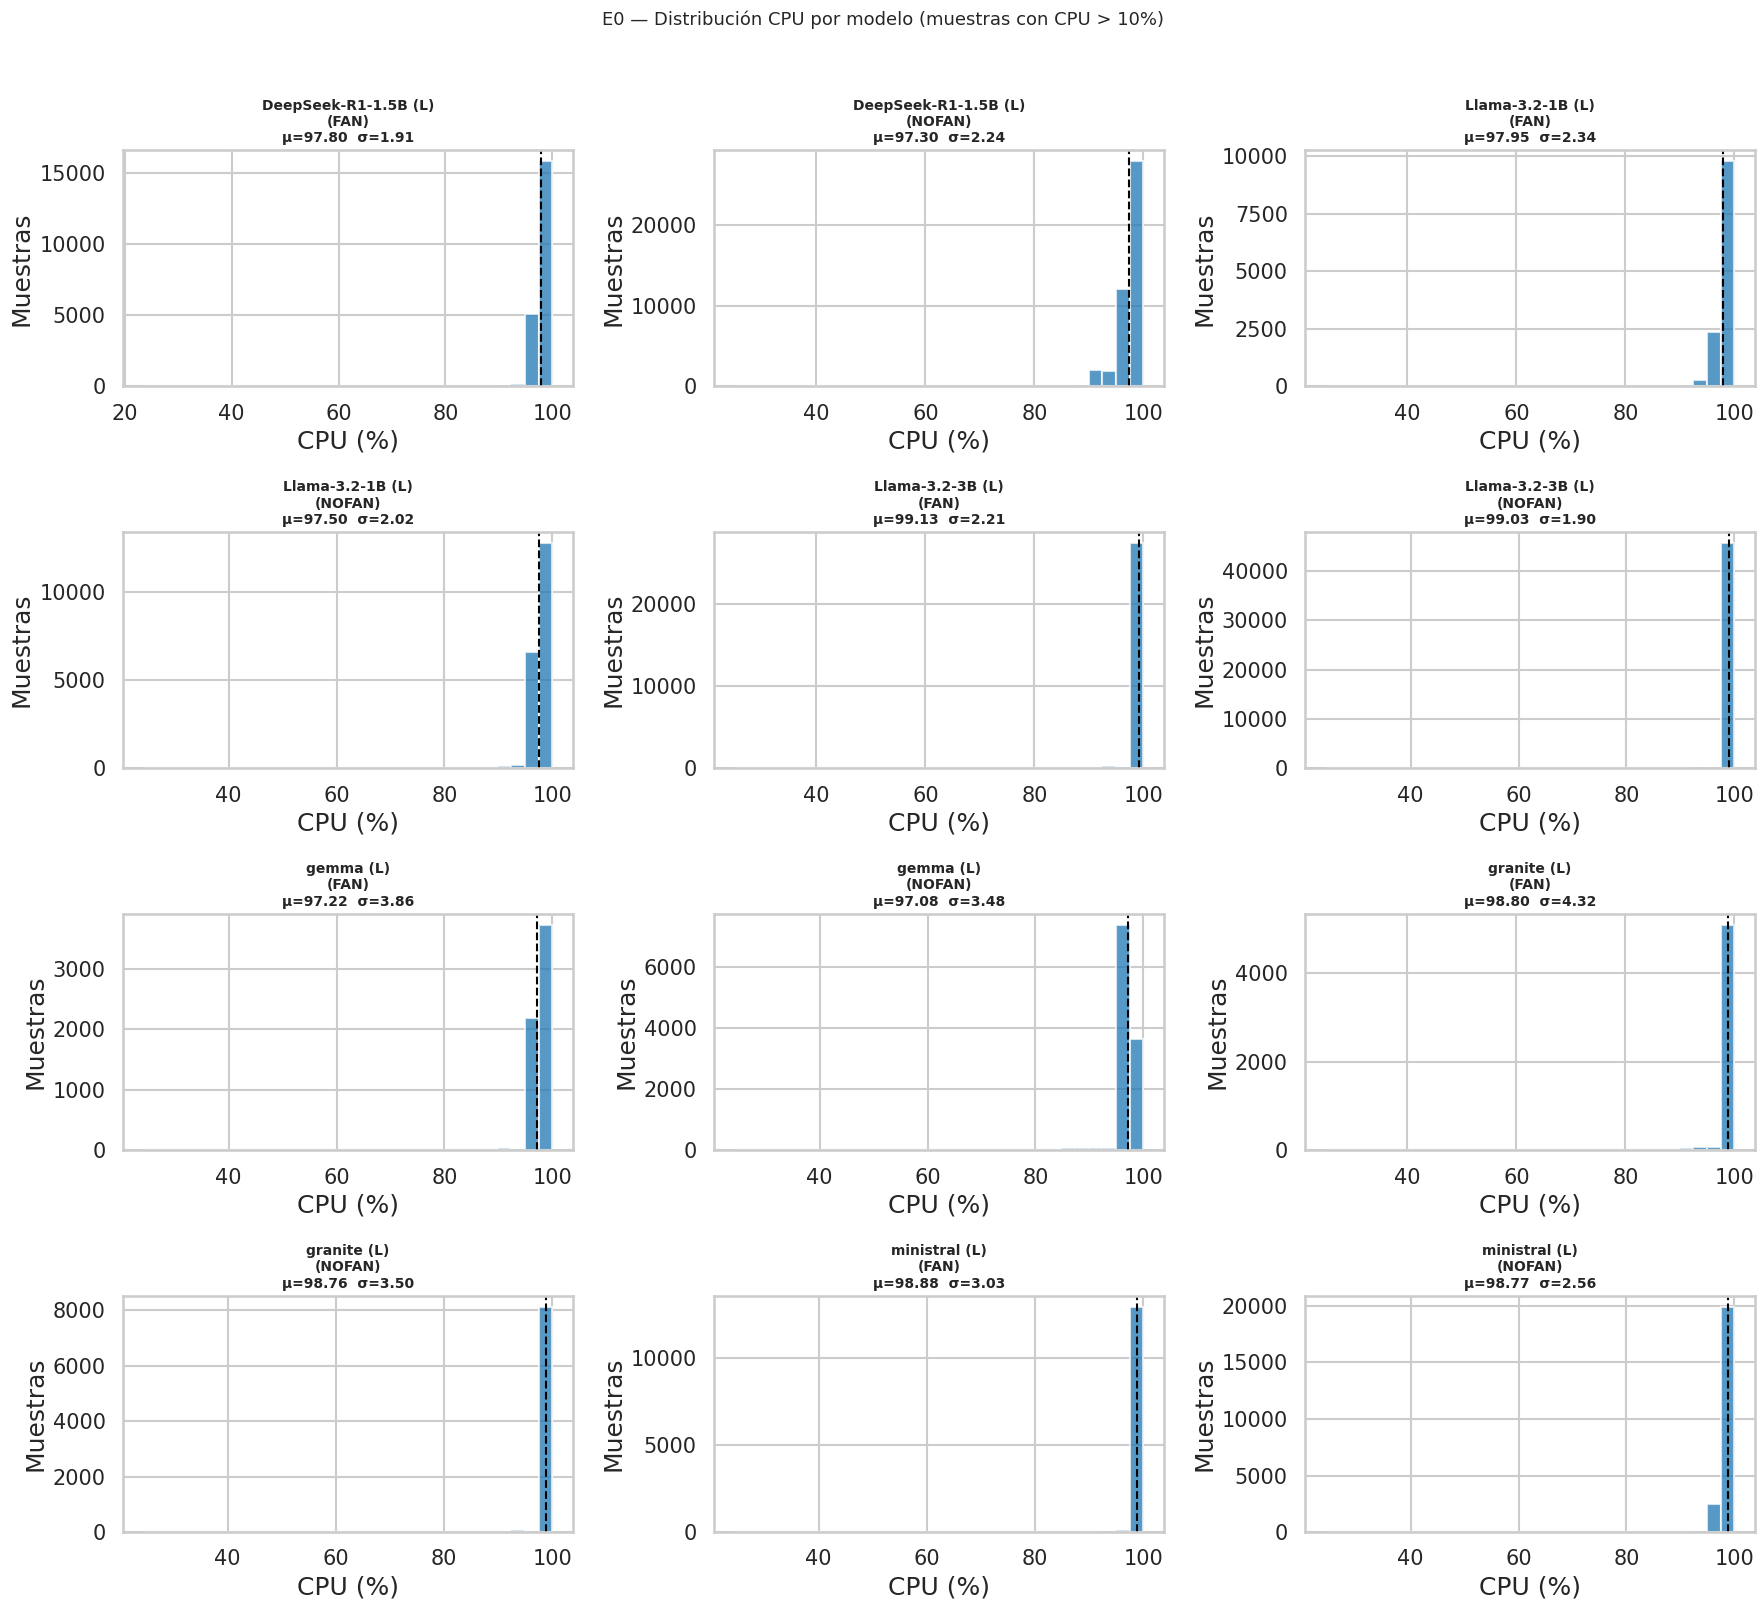

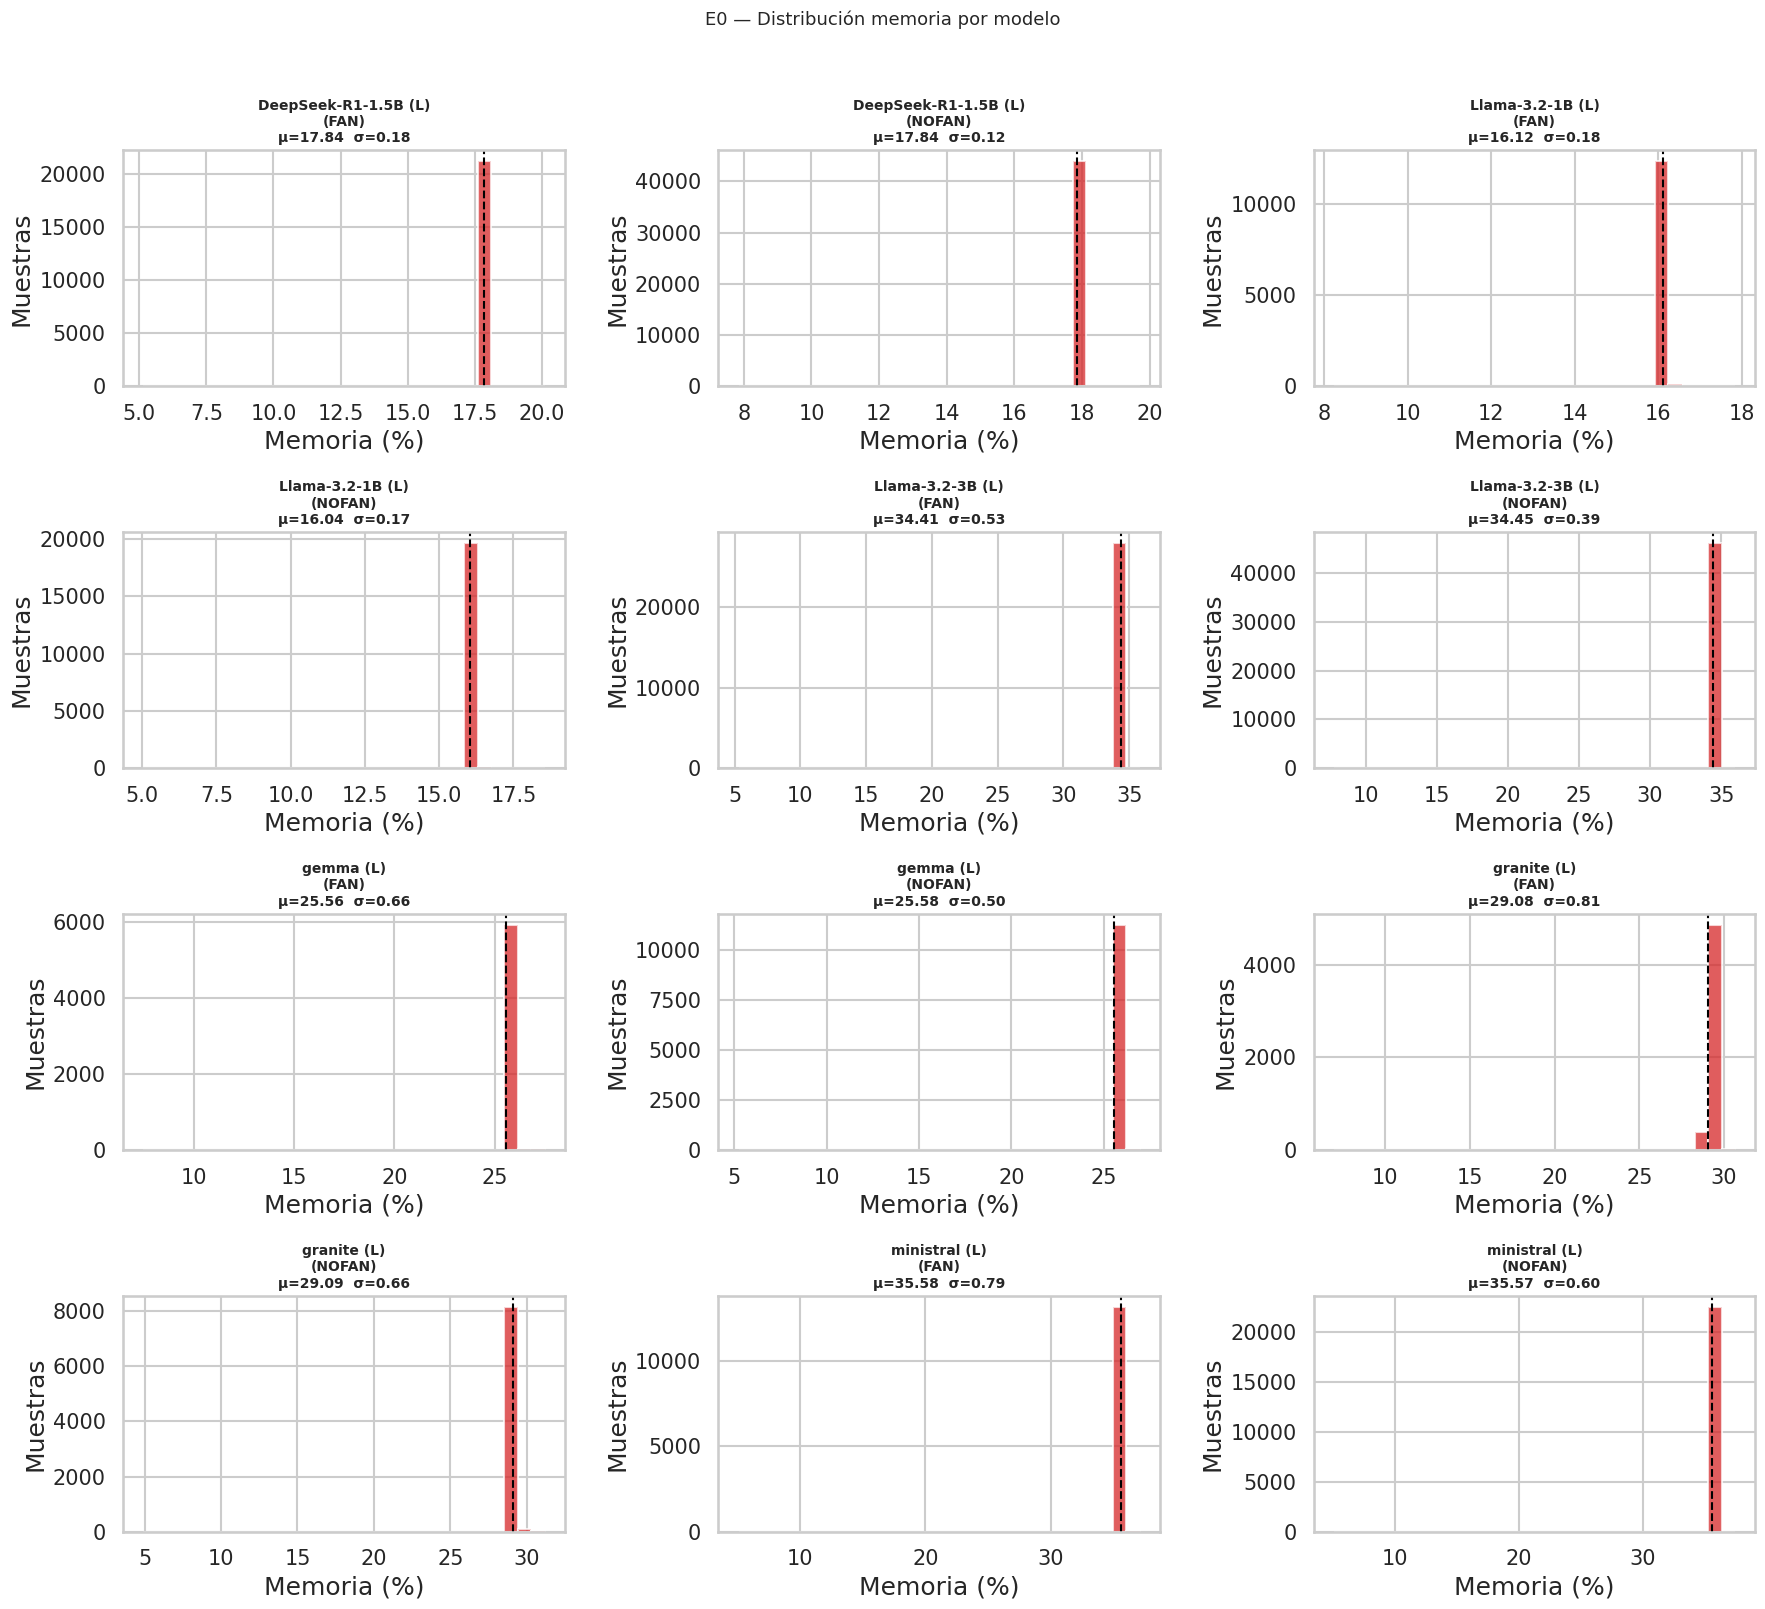

In [15]:
def _hist_by_model(hw_data, col, xlabel, color, suptitle,
                   xlim=None, vline=None):
    if col not in hw_data.columns:
        print(f'{col} no disponible'); return
    label_col = "config_label" if "config_label" in hw_data.columns else "model_label"
    models = sorted(hw_data[label_col].unique())
    ncols = 3
    nrows = -(-len(models) // ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4 * nrows),
                             sharey=False)
    axes_flat = axes.flatten() if nrows * ncols > 1 else [axes]
    for i, model in enumerate(models):
        ax = axes_flat[i]
        data = hw_data[hw_data[label_col] == model][col].dropna()
        if col == "cpu_usage_pct":
            data = data[data > 10]
        if data.empty:
            ax.set_visible(False); continue
        # Fijar rango explícito si xlim está definido para evitar expansión
        # automática de NumPy cuando todos los valores son iguales
        hist_range = xlim if xlim else (data.min(), data.max())
        if hist_range[0] == hist_range[1]:
            hist_range = (hist_range[0] - 0.5, hist_range[1] + 0.5)
        ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white',
                range=hist_range)
        ax.axvline(data.mean(), color='black', ls='--', lw=1.5)
        if vline is not None:
            ax.axvline(vline, color='gray', ls=':', lw=1.2,
                       label=f'{vline} GHz nom.')
            ax.legend(fontsize=7)
        if xlim:
            ax.set_xlim(*xlim)
        ax.set_title(f"{model}\n\u03bc={data.mean():.2f}  \u03c3={data.std():.2f}",
                     fontsize=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Muestras")
    for j in range(len(models), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_df.empty:
    _hist_by_model(hw_df, "cpu_usage_pct", "CPU (%)", "tab:blue",
                   "E0 \u2014 Distribuci\u00f3n CPU por modelo (muestras con CPU > 10%)")
    _hist_by_model(hw_df, "mem_pct", "Memoria (%)", "tab:red",
                   "E0 \u2014 Distribuci\u00f3n memoria por modelo")
else:
    print('Sin datos de hardware para histogramas.')


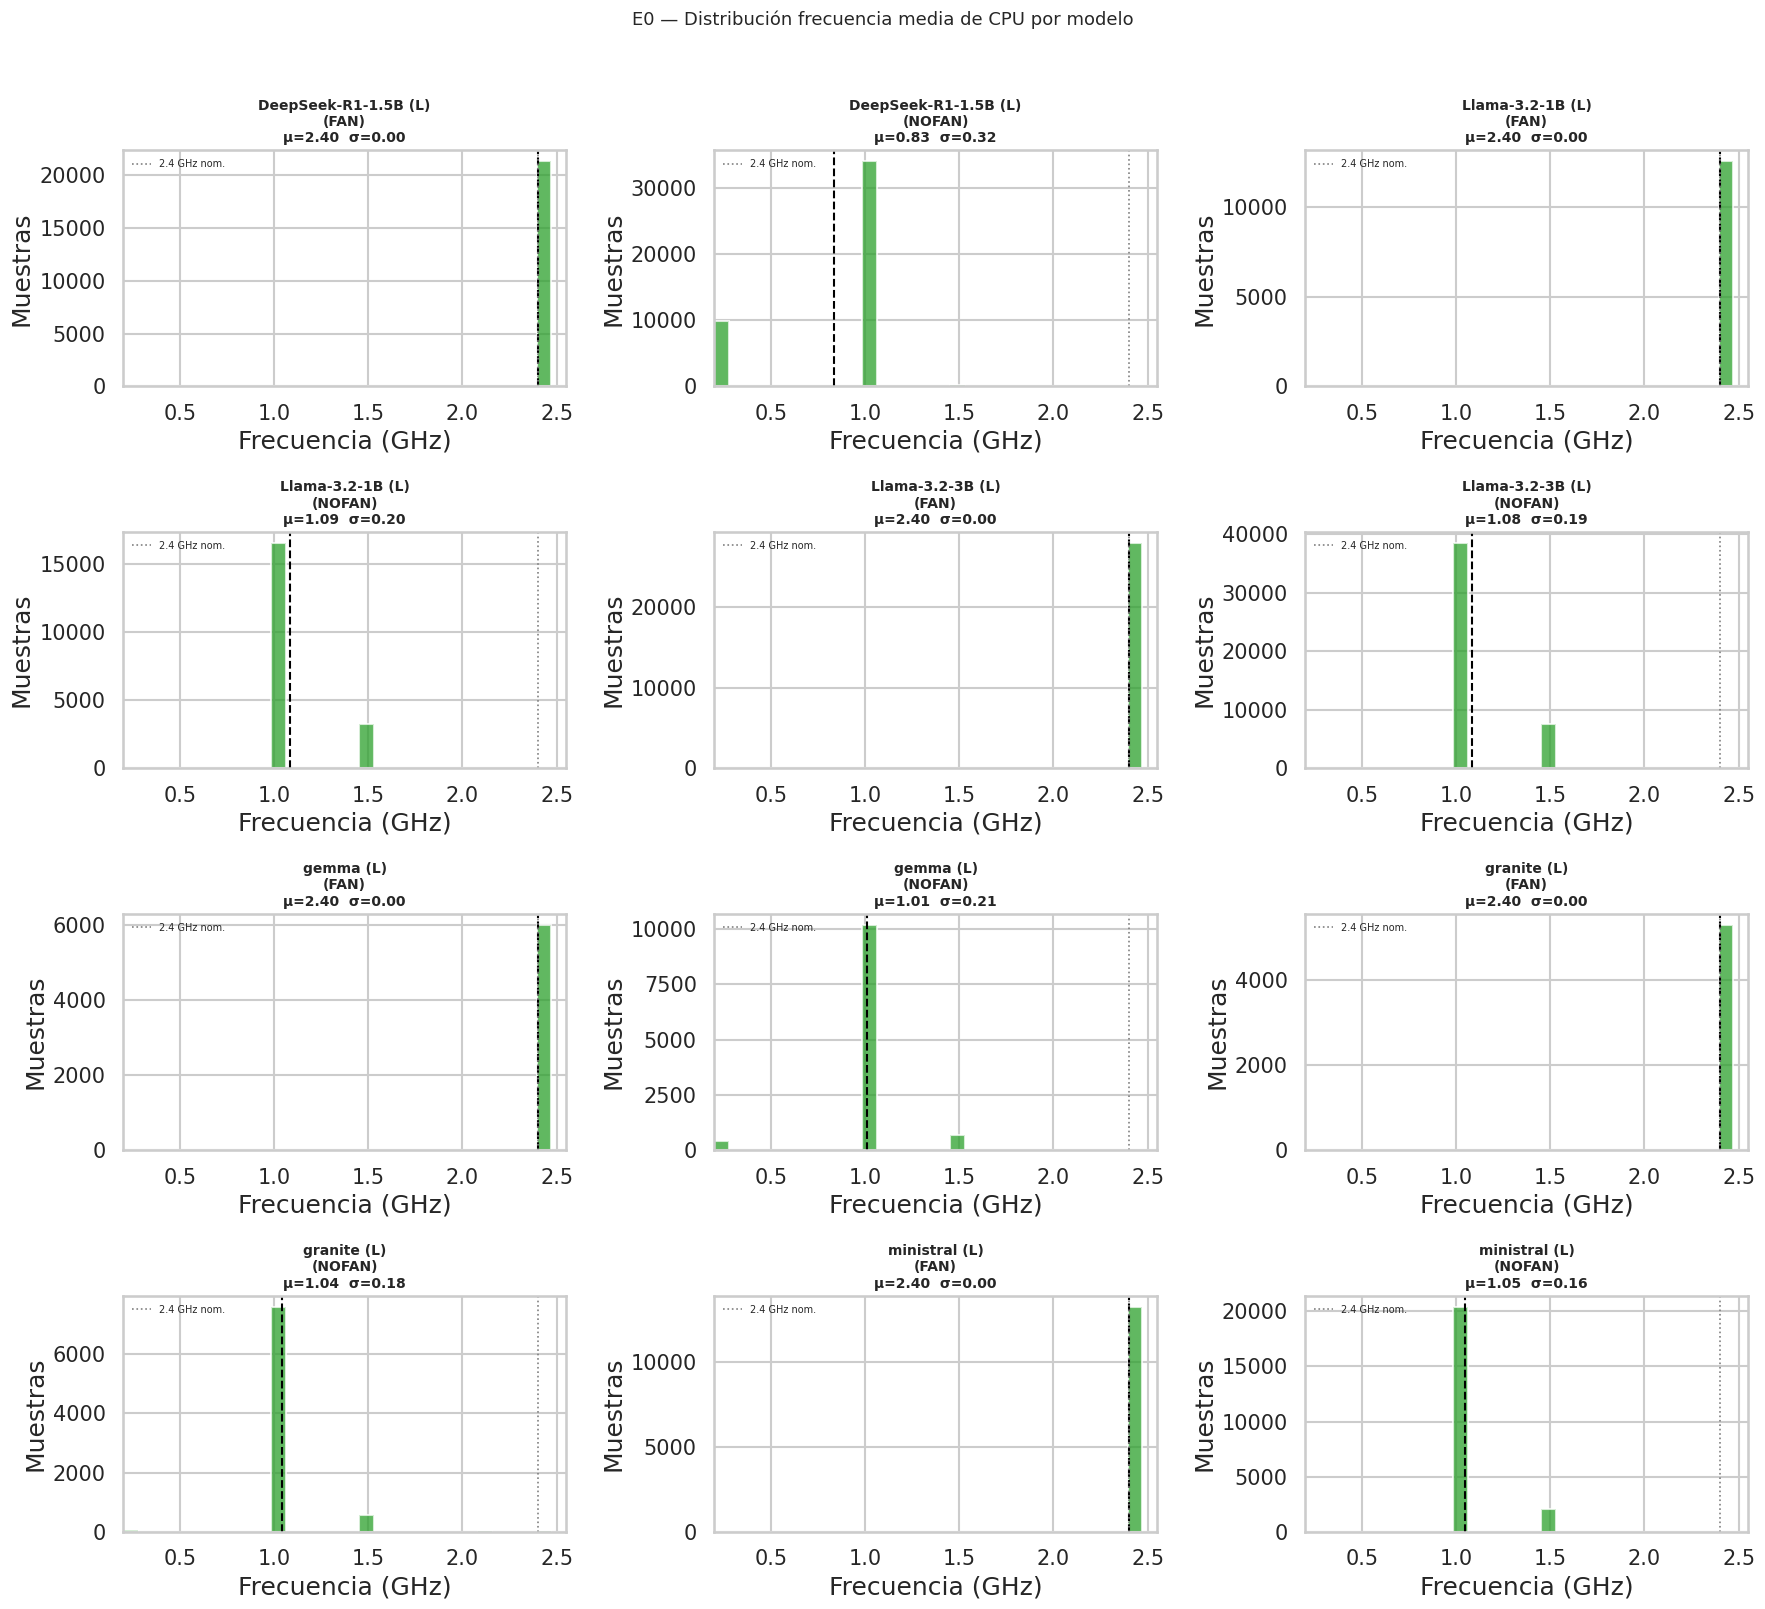

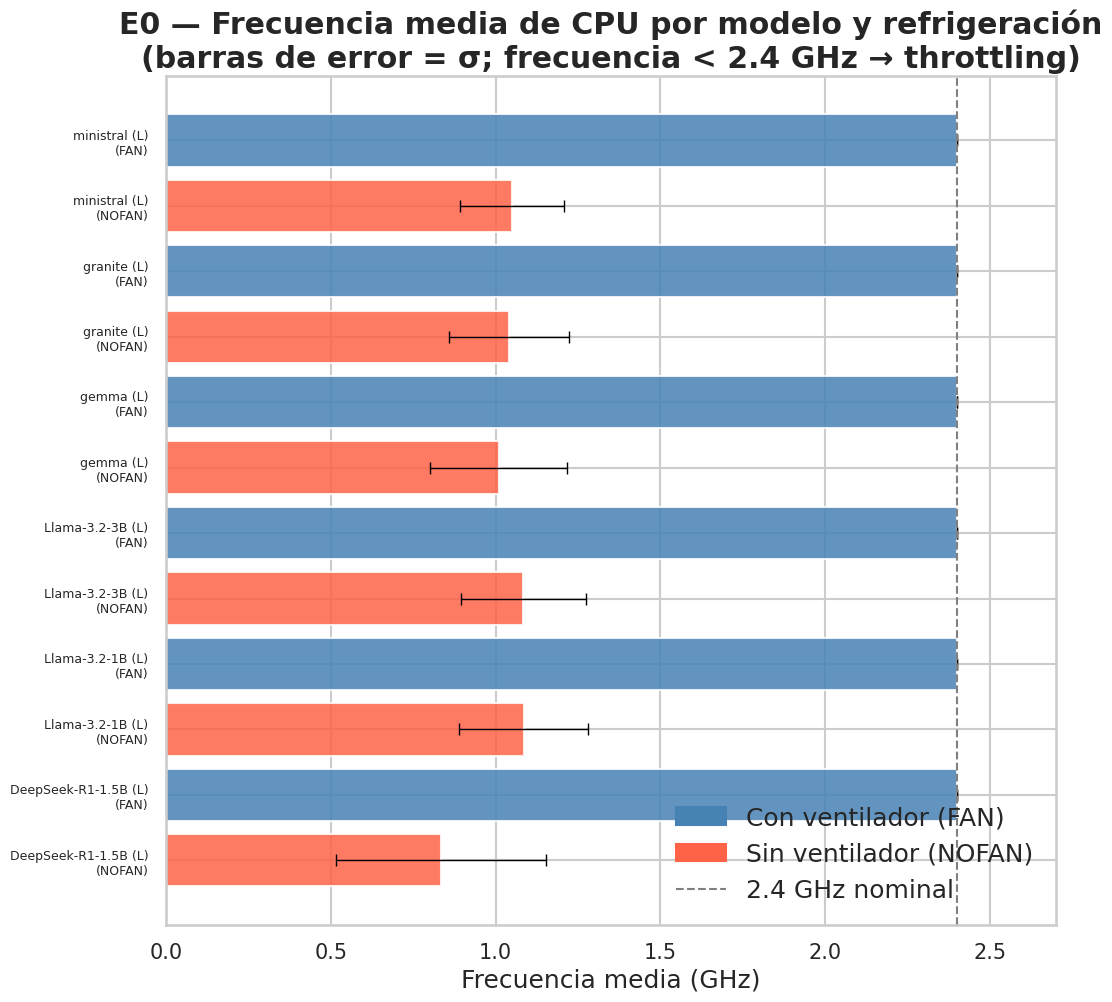


Frecuencia media (GHz) durante inferencia activa:


,config,mean,std
0,DeepSeek-R1-1.5B (L)\n(NOFAN),0.835,0.318
1,DeepSeek-R1-1.5B (L)\n(FAN),2.400,0.000
2,Llama-3.2-1B (L)\n(NOFAN),1.085,0.196
3,Llama-3.2-1B (L)\n(FAN),2.400,0.000
4,Llama-3.2-3B (L)\n(NOFAN),1.084,0.190
5,Llama-3.2-3B (L)\n(FAN),2.400,0.000
6,gemma (L)\n(NOFAN),1.009,0.207
7,gemma (L)\n(FAN),2.400,0.000
8,granite (L)\n(NOFAN),1.040,0.183
9,granite (L)\n(FAN),2.400,0.000


In [16]:
if not hw_df.empty and 'freq_mean_ghz' in hw_df.columns:
    _hist_by_model(hw_df, "freq_mean_ghz", "Frecuencia (GHz)", "tab:green",
                   "E0 — Distribución frecuencia media de CPU por modelo",
                   xlim=(0.2, 2.55), vline=2.4)

    freq_summary = (hw_df[hw_df["cpu_usage_pct"] > 10]
                    .groupby(["model_label","fan"])["freq_mean_ghz"]
                    .agg(mean="mean", std="std")
                    .reset_index())
    if not freq_summary.empty:
        freq_summary["config"] = (
            freq_summary["model_label"] + "\n(" +
            freq_summary["fan"].map({True: "FAN", False: "NOFAN"}) + ")"
        )
        freq_summary = freq_summary.sort_values(["model_label","fan"])

        n_bars  = len(freq_summary)
        fig_h   = max(6, n_bars * 0.9)
        fig, ax = plt.subplots(figsize=(11, fig_h))
        bar_colors = freq_summary["fan"].map({True: "steelblue", False: "tomato"})
        ax.barh(freq_summary["config"], freq_summary["mean"],
                xerr=freq_summary["std"], color=bar_colors, alpha=0.85,
                capsize=4, error_kw={"elinewidth": 1, "ecolor": "black"})
        ax.axvline(2.4, ls='--', color='gray', lw=1.5)
        ax.set_xlim(0, 2.7)
        ax.set_xlabel("Frecuencia media (GHz)")
        ax.set_title(
            "E0 — Frecuencia media de CPU por modelo y refrigeración\n"
            "(barras de error = σ; frecuencia < 2.4 GHz → throttling)"
        )
        from matplotlib.patches import Patch
        import matplotlib.lines as mlines
        leg_elems = [
            Patch(color="steelblue", label="Con ventilador (FAN)"),
            Patch(color="tomato",    label="Sin ventilador (NOFAN)"),
            mlines.Line2D([],[],color='gray',ls='--',lw=1.5,label="2.4 GHz nominal"),
        ]
        ax.legend(handles=leg_elems, loc="lower right")
        ax.tick_params(axis='y', labelsize=9)
        plt.subplots_adjust(left=0.28)
        plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])
        plt.show()

        print("\nFrecuencia media (GHz) durante inferencia activa:")
        display(freq_summary[["config","mean","std"]].round(3))
else:
    print('freq_mean_ghz no disponible en hw_df.')


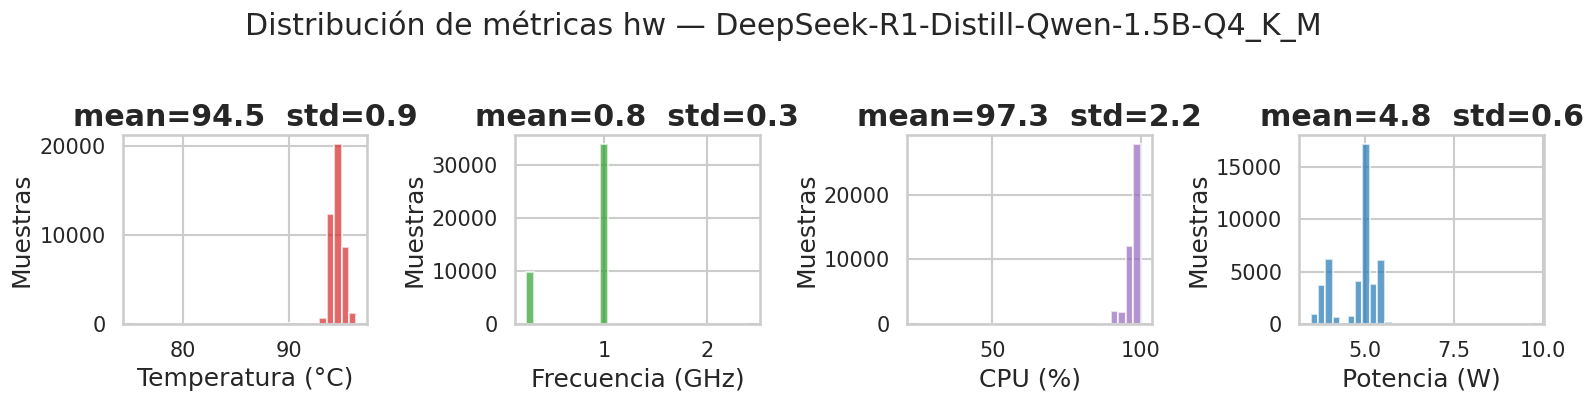

In [17]:
if not hw_df.empty and not summary.empty and 'throttled_ratio' in summary.columns:
    _rep_id = summary.sort_values('throttled_ratio', ascending=False)['run_id'].iloc[0]
    hw_rep  = hw_df[hw_df['run_id'] == _rep_id]
    run_rep = next((r for r in coll.runs if r.run_id == _rep_id), None)
    if run_rep is not None and not hw_rep.empty:
        try:
            fig = hw_distributions_panel(hw_rep, run_rep)
            plt.show()
        except Exception as e:
            print(f'hw_distributions_panel: {e}')
    else:
        print('Run representativo no encontrado para hw_distributions_panel.')
else:
    print('Sin datos para panel de histogramas hw.')


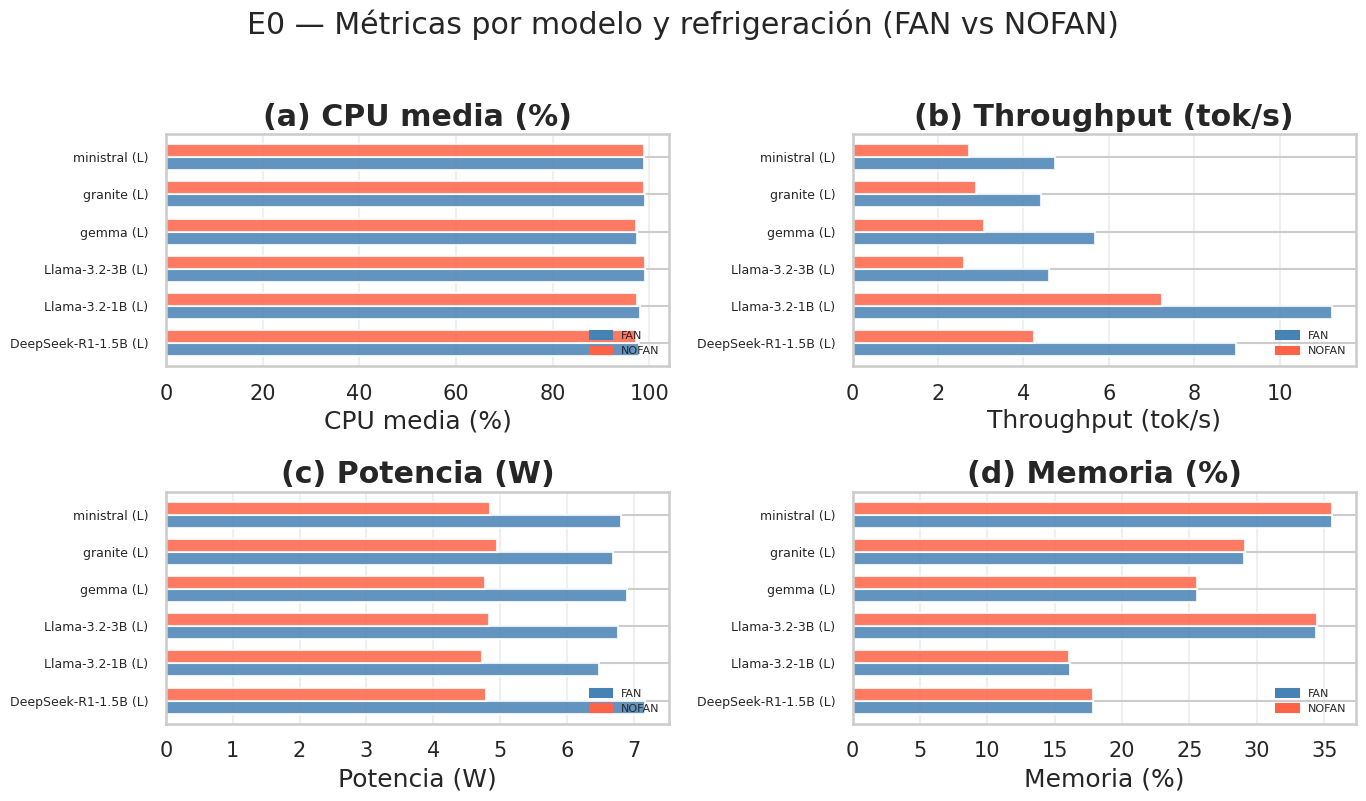

In [18]:
if not hw_df.empty and not pm_df.empty and not summary.empty:
    pm_valid_tmp = pm_df[~pm_df['is_empty_generation']].copy()

    hw_rows = []
    for _, row in summary.iterrows():
        rid   = row.get('run_id')
        fan_v = row.get('fan', False)
        hw_r  = hw_df[hw_df['run_id'] == rid] if rid else pd.DataFrame()
        pm_r  = pm_valid_tmp[pm_valid_tmp['run_id'] == rid] if rid else pd.DataFrame()
        if hw_r.empty: continue
        active_r = hw_r[hw_r['cpu_usage_pct'] > 50]
        hw_rows.append({
            'model_label': row['model_label'],
            'fan':    'FAN' if fan_v else 'NOFAN',
            'cpu_pct':  active_r['cpu_usage_pct'].mean() if not active_r.empty else float('nan'),
            'tokens_s': pm_r['tokens_per_second'].mean() if not pm_r.empty else float('nan'),
            'power_w':  hw_r['internal_power_w'].mean(),
            'mem_pct':  hw_r['mem_pct'].mean() if 'mem_pct' in hw_r.columns else float('nan'),
        })

    if hw_rows:
        from matplotlib.patches import Patch
        hw_sum  = pd.DataFrame(hw_rows)
        models  = sorted(hw_sum['model_label'].unique())
        y       = np.arange(len(models))
        width   = 0.35
        METRICS = [
            ('cpu_pct',  'CPU media (%)',      '(a)'),
            ('tokens_s', 'Throughput (tok/s)', '(b)'),
            ('power_w',  'Potencia (W)',        '(c)'),
            ('mem_pct',  'Memoria (%)',         '(d)'),
        ]
        fig, axes = plt.subplots(2, 2, figsize=(14, max(8, len(models) * 1.1)))
        for ax, (col, xlabel, label) in zip(axes.flatten(), METRICS):
            for offset, fan_str, color in [
                (-width/2, 'FAN',   'steelblue'),
                ( width/2, 'NOFAN', 'tomato'),
            ]:
                vals = [
                    hw_sum[(hw_sum['model_label'] == m) & (hw_sum['fan'] == fan_str)][col].mean()
                    if not hw_sum[(hw_sum['model_label'] == m) & (hw_sum['fan'] == fan_str)].empty
                    else float('nan')
                    for m in models
                ]
                ax.barh(y + offset, vals, width, label=fan_str,
                        color=color, alpha=0.85)
            ax.set_yticks(y)
            ax.set_yticklabels(models, fontsize=9)
            ax.set_xlabel(xlabel)
            ax.set_title(f'{label} {xlabel}', fontweight='bold')
            ax.grid(True, axis='x', alpha=0.3)
            ax.legend(handles=[Patch(color='steelblue', label='FAN'),
                                Patch(color='tomato',   label='NOFAN')],
                      fontsize=8, loc='lower right')
        fig.suptitle('E0 \u2014 M\u00e9tricas por modelo y refrigeraci\u00f3n (FAN vs NOFAN)',
                     y=1.01)
        fig.tight_layout(); plt.show()
    else:
        print('Sin datos para grouped bar chart.')
else:
    print('Sin datos suficientes para grouped bar chart.')


## 4. Métricas de inferencia

Distribución de las métricas de rendimiento por prompt para cada
configuración del experimento.

In [19]:
def _plot_metric(df, metric, ylabel='', title='', unit_label=''):
    """Barplot horizontal agrupado por config_label cuando está disponible."""
    label_col = 'config_label' if 'config_label' in df.columns else 'model_label'
    data = df.dropna(subset=[metric]).copy()
    if data.empty:
        print(f'Sin datos para {metric}'); return
    means = data.groupby(label_col)[metric].mean().sort_values()
    full_title = f'{title}' + (f' ({unit_label})' if unit_label else '')
    fig, ax = plt.subplots(figsize=(10, max(4, len(means) * 0.55)))
    ax.barh(range(len(means)), means.values, alpha=0.85, color='steelblue')
    ax.set_yticks(range(len(means)))
    ax.set_yticklabels(means.index, fontsize=9)
    ax.set_xlabel(unit_label or ylabel or metric)
    ax.set_title(full_title)
    ax.grid(True, axis='x', alpha=0.3)
    fig.tight_layout()
    plt.show()


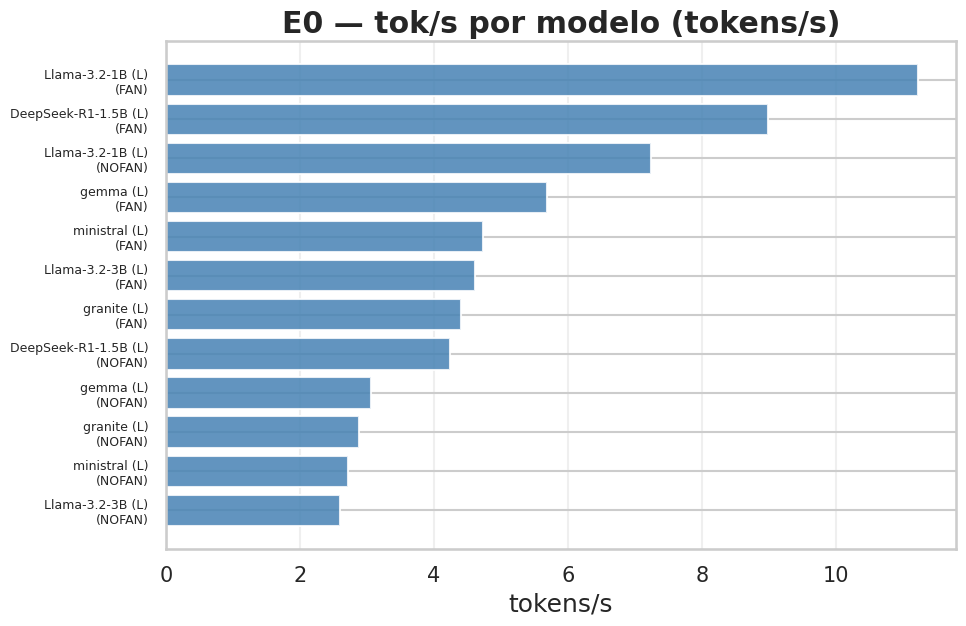

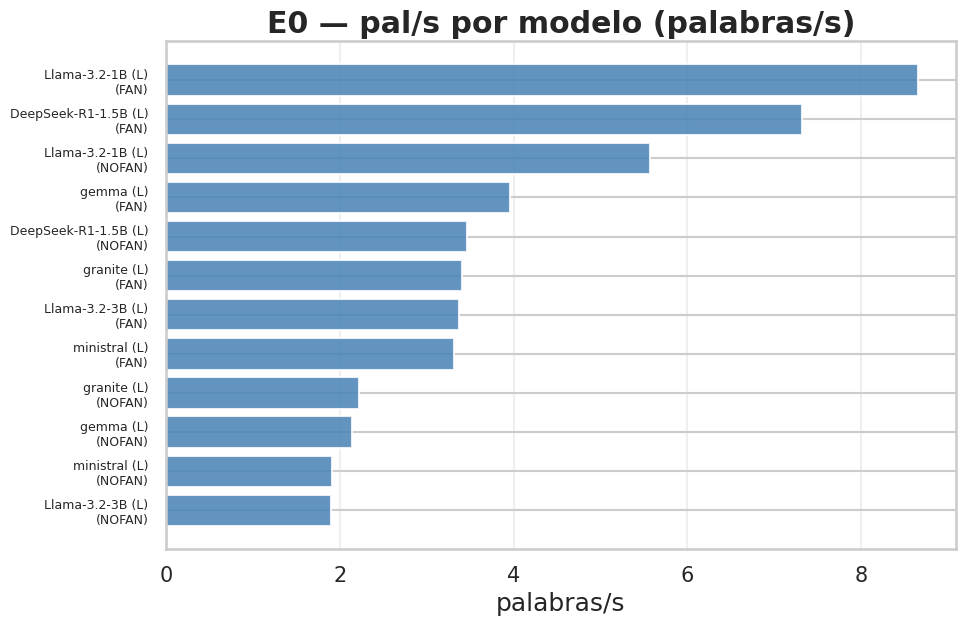

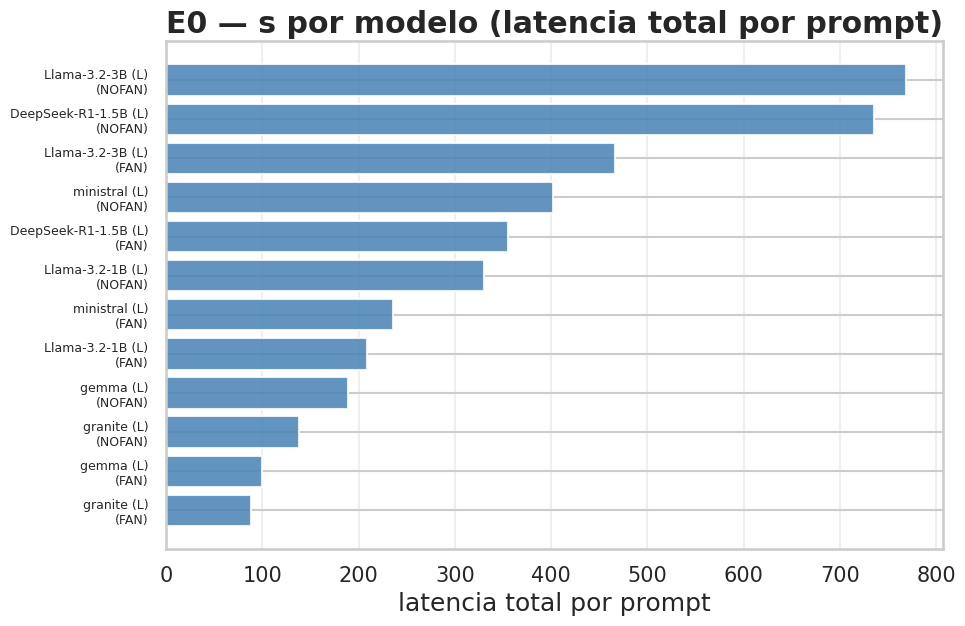

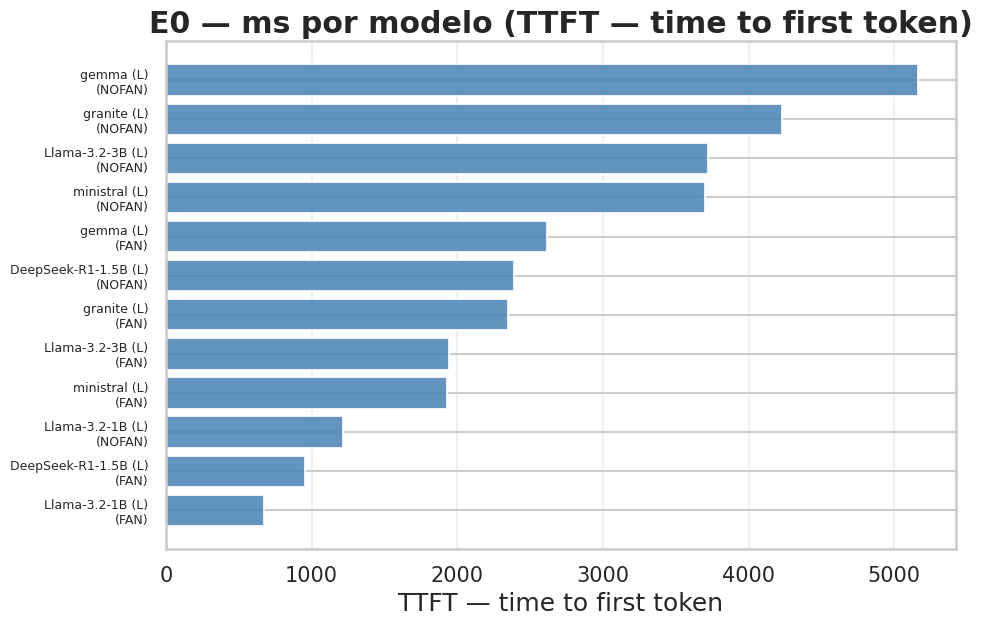

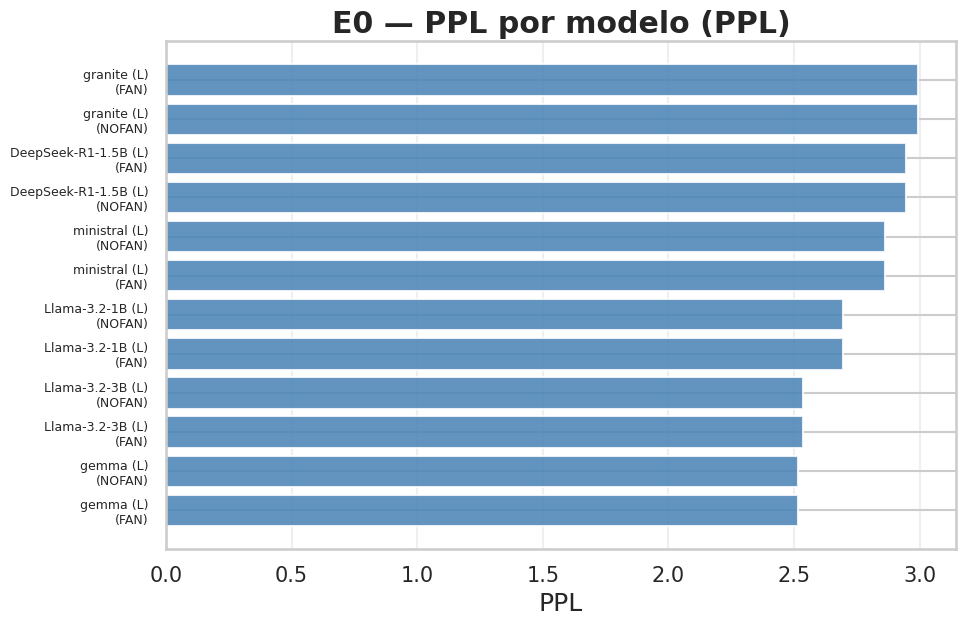

In [20]:
pm_valid = pm_df[~pm_df['is_empty_generation']].copy() if not pm_df.empty else pd.DataFrame()

if not pm_valid.empty:
    if 'latency_ms' in pm_valid.columns:
        pm_valid['latency_s'] = pm_valid['latency_ms'] / 1000

    for metric, ylabel, unit in [
        ('tokens_per_second',      'tok/s', 'tokens/s'),
        ('words_per_second',       'pal/s', 'palabras/s'),
        ('latency_s',              's',     'latencia total por prompt'),
        ('time_to_first_token_ms', 'ms',    'TTFT — time to first token'),
        ('perplexity',             'PPL',   'PPL'),
    ]:
        if metric in pm_valid.columns:
            _plot_metric(pm_valid, metric, ylabel=ylabel,
                         title=f'E0 \u2014 {ylabel} por modelo', unit_label=unit)
        else:
            print(f'M\u00e9trica no disponible: {metric}')
else:
    print('Sin prompts v\u00e1lidos para m\u00e9tricas de inferencia.')


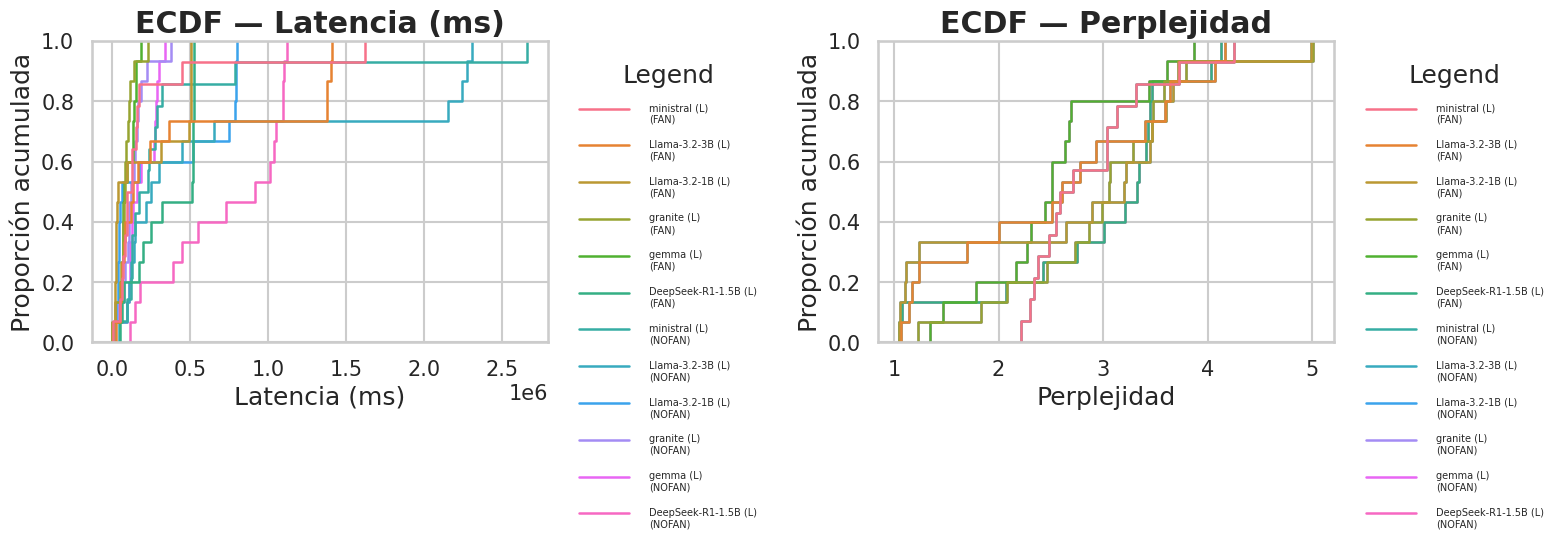

In [21]:
if not pm_valid.empty:
    hue_col   = 'config_label' if 'config_label' in pm_valid.columns else 'model_label'
    ecdf_cols = [(c, lbl) for c, lbl in [
        ('latency_ms', 'Latencia (ms)'),
        ('perplexity', 'Perplejidad'),
    ] if c in pm_valid.columns]
    if ecdf_cols:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        for ax, (col, xlabel) in zip(axes, ecdf_cols):
            sns.ecdfplot(data=pm_valid.dropna(subset=[col]),
                         x=col, hue=hue_col, ax=ax)
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Proporci\u00f3n acumulada')
            ax.set_title(f'ECDF \u2014 {xlabel}')
            lgd = ax.get_legend()
            if lgd:
                lgd.set_title("Legend")
                lgd.set_bbox_to_anchor((1.02, 1))
                lgd.set_loc('upper left')
                for txt in lgd.get_texts():
                    txt.set_fontsize(7)
        # Ocultar segundo ax si solo hay un ECDF
        if len(ecdf_cols) == 1:
            axes[1].set_visible(False)
        fig.tight_layout()
        plt.show()
else:
    print('Sin datos para ECDFs.')


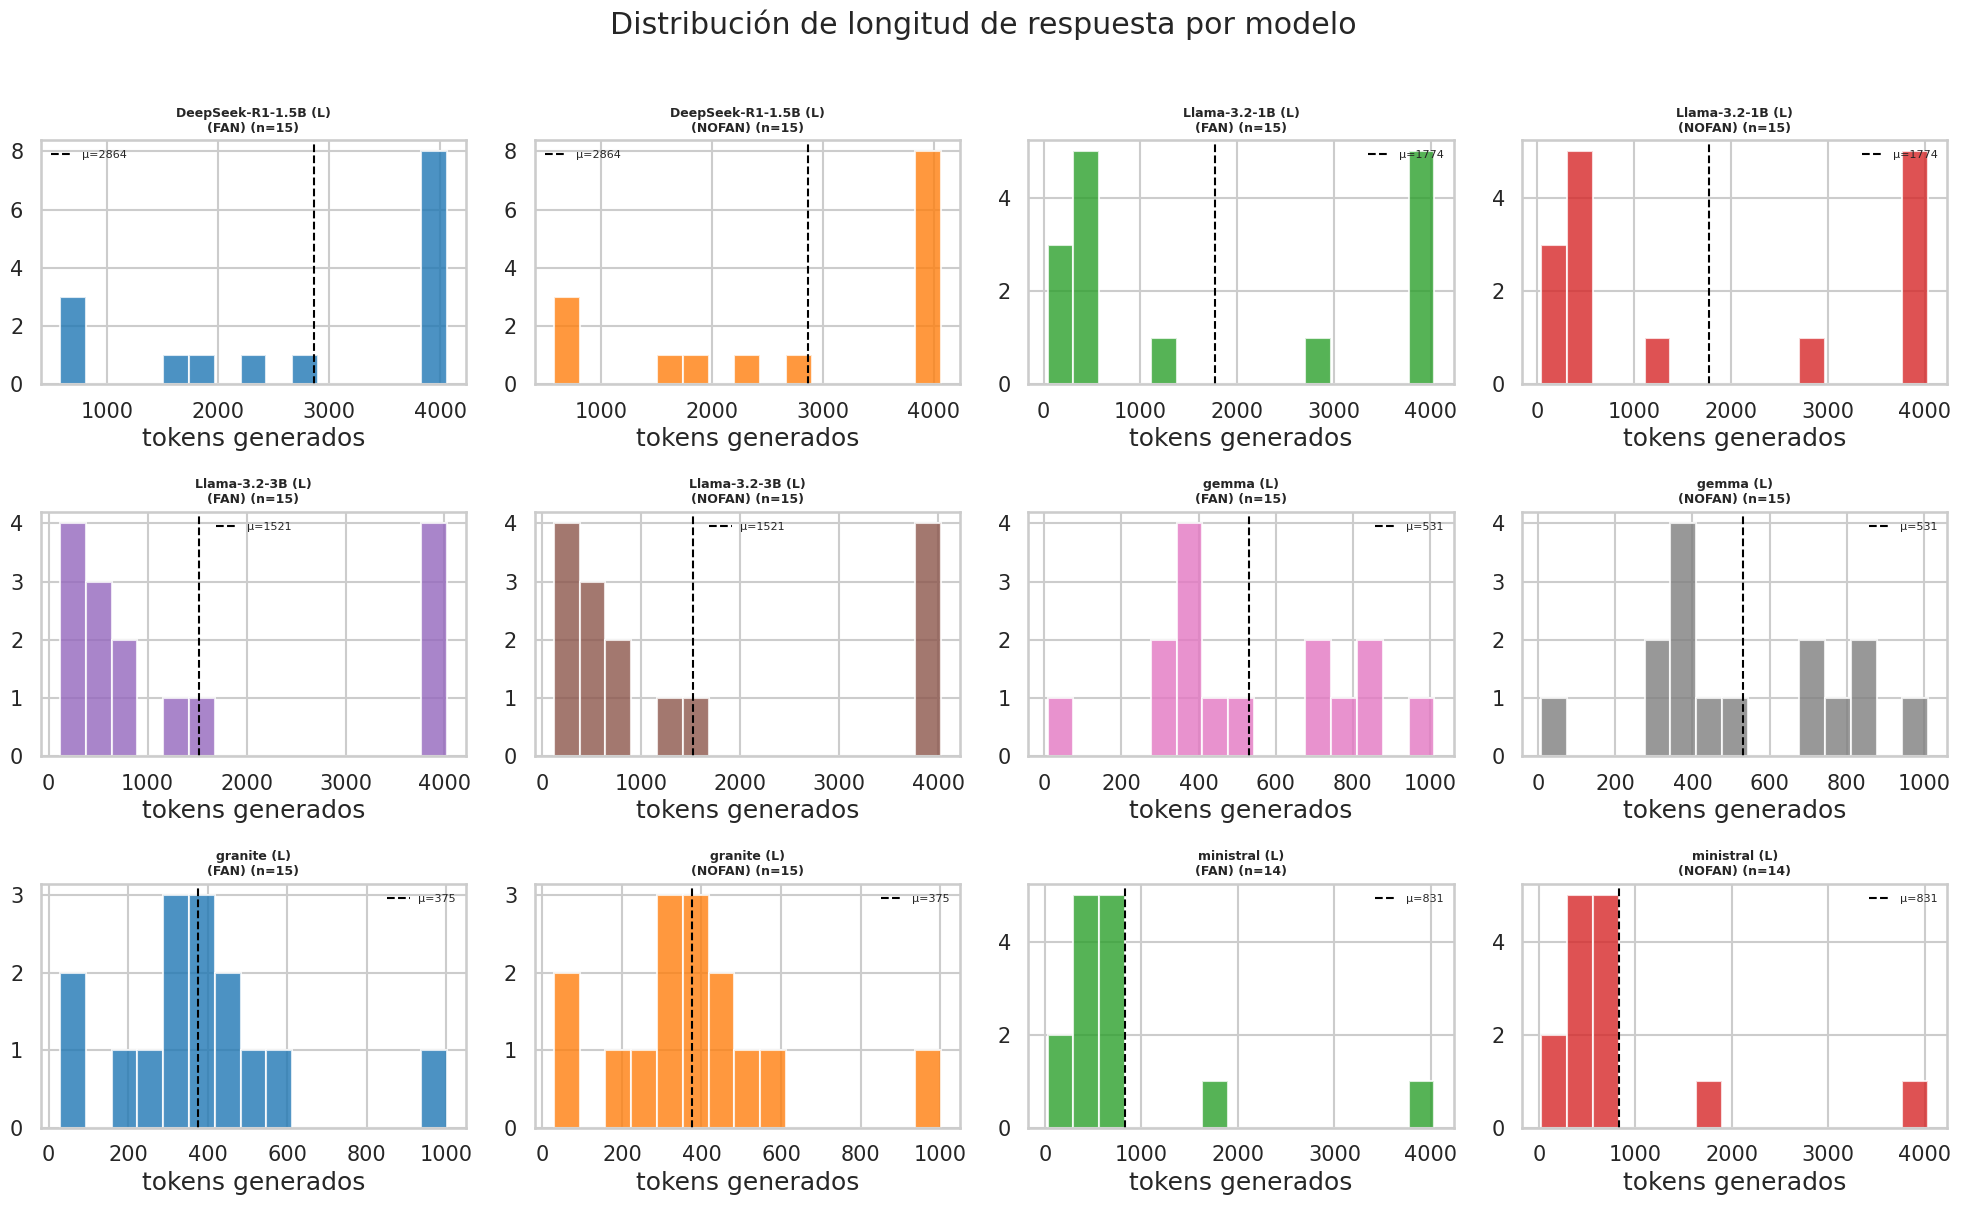


Resumen (tokens generados):


,count,mean,std,min,max
config_label,,,,,
DeepSeek-R1-1.5B (L)\n(FAN),15,2863.7,1402.2,574,4059
DeepSeek-R1-1.5B (L)\n(NOFAN),15,2863.7,1402.2,574,4059
Llama-3.2-1B (L)\n(FAN),15,1773.5,1765.7,42,4035
Llama-3.2-1B (L)\n(NOFAN),15,1773.5,1765.7,42,4035
Llama-3.2-3B (L)\n(FAN),15,1520.9,1582.0,115,4023
Llama-3.2-3B (L)\n(NOFAN),15,1520.9,1582.0,115,4023
gemma (L)\n(FAN),15,530.9,273.7,9,1011
gemma (L)\n(NOFAN),15,530.9,273.7,9,1011
granite (L)\n(FAN),15,375.2,228.7,29,1001


In [22]:
if not pm_valid.empty and 'eval_count' in pm_valid.columns:
    label_col = 'config_label' if 'config_label' in pm_valid.columns else 'model_label'
    models = sorted(pm_valid[label_col].unique())
    ncols = min(4, len(models))
    nrows = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    for i, model in enumerate(models):
        if i >= len(axes_flat):
            break
        ax = axes_flat[i]
        data = pm_valid[pm_valid[label_col] == model]['eval_count'].dropna()
        ax.hist(data, bins=15, color=f'C{i}', alpha=0.8, edgecolor='white')
        ax.axvline(data.mean(), ls='--', color='black', lw=1.5,
                   label=f'\u03bc={data.mean():.0f}')
        ax.set_title(f'{model} (n={len(data)})', fontsize=9)
        ax.set_xlabel('tokens generados')
        ax.legend(fontsize=8)
    for j in range(len(models), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle('Distribuci\u00f3n de longitud de respuesta por modelo', y=1.01)
    fig.tight_layout()
    plt.show()

    print('\nResumen (tokens generados):')
    display(pm_valid.groupby(label_col)['eval_count']
            .agg(['count', 'mean', 'std', 'min', 'max']).round(1))
else:
    print('Sin datos para distribuci\u00f3n de longitud de respuesta.')


## 5. Eficiencia energética y trabajo CPU efectivo

**W_CPU (core·s)**: trabajo computacional efectivo = ∫(f(t)/f_nom)·(CPU(t)/100)·N_cores·dt.  
Análogo a "persona-hora". Con throttling al 50% de frecuencia, W_CPU es
la mitad que a frecuencia nominal en el mismo tiempo real.

**η_CPU**: eficiencia CPU = W_CPU / (N_cores·T). Rango [0,1].

**W_token (core·s/token)**: coste computacional por token generado.

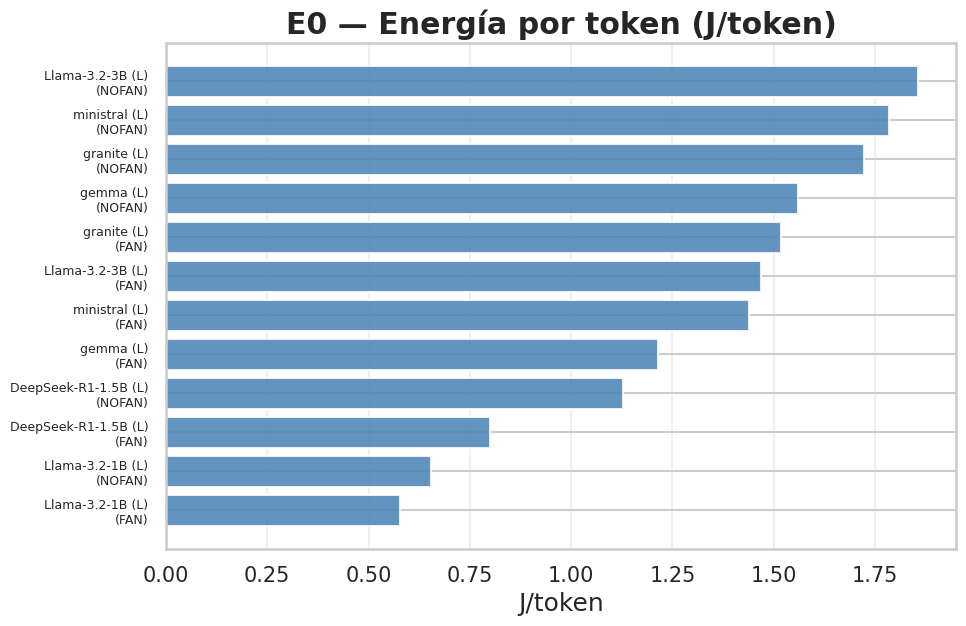

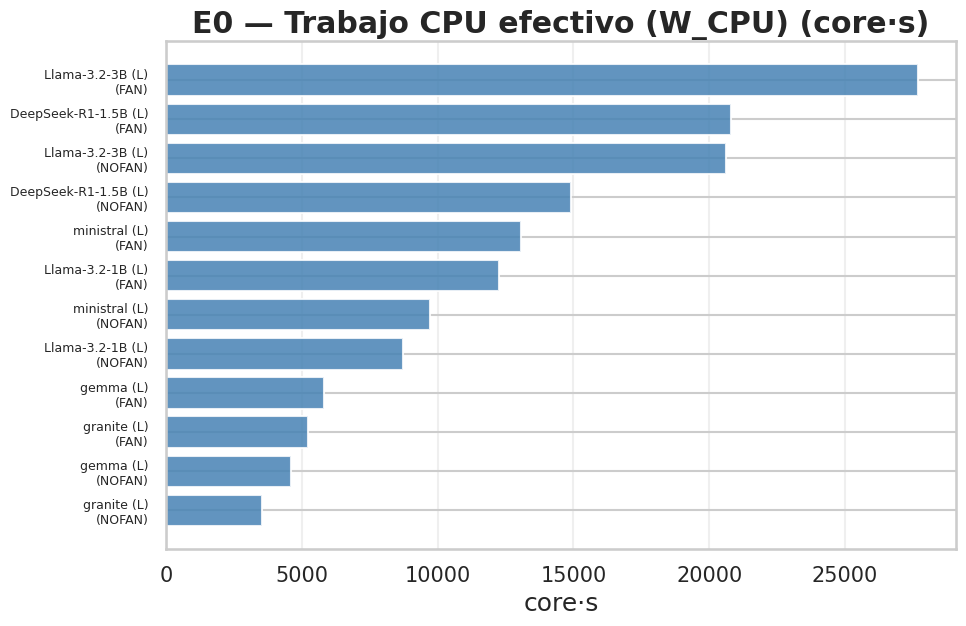

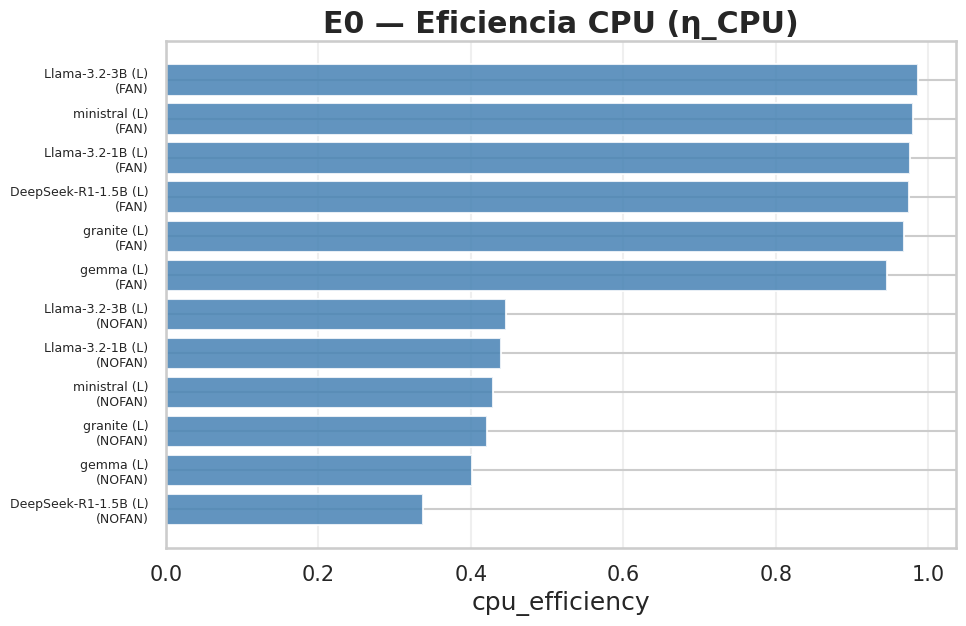

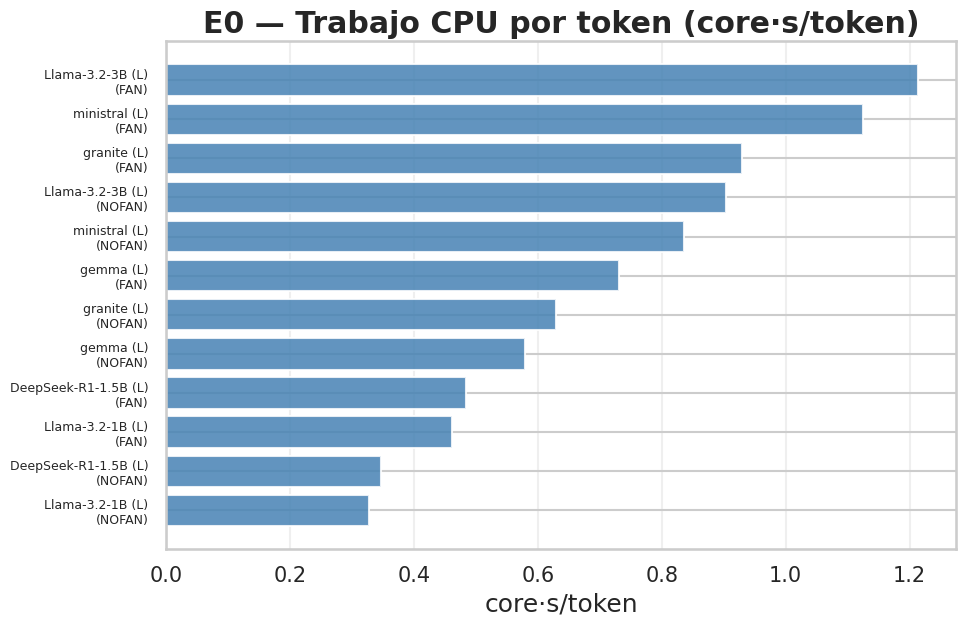

In [23]:
if not summary.empty:
    for metric, title, unit in [
        ('energy_per_token_j',  'Energía por token',           'J/token'),
        ('cpu_work_core_s',     'Trabajo CPU efectivo (W_CPU)', 'core·s'),
        ('cpu_efficiency',      'Eficiencia CPU (η_CPU)',       ''),
        ('cpu_work_per_token',  'Trabajo CPU por token',        'core·s/token'),
    ]:
        if metric in summary.columns:
            _plot_metric(summary, metric, ylabel=unit,
                         title=f'E0 \u2014 {title}', unit_label=unit)
        else:
            print(f'Métrica no disponible en summary: {metric}')
else:
    print('Sin datos de summary para eficiencia energética.')


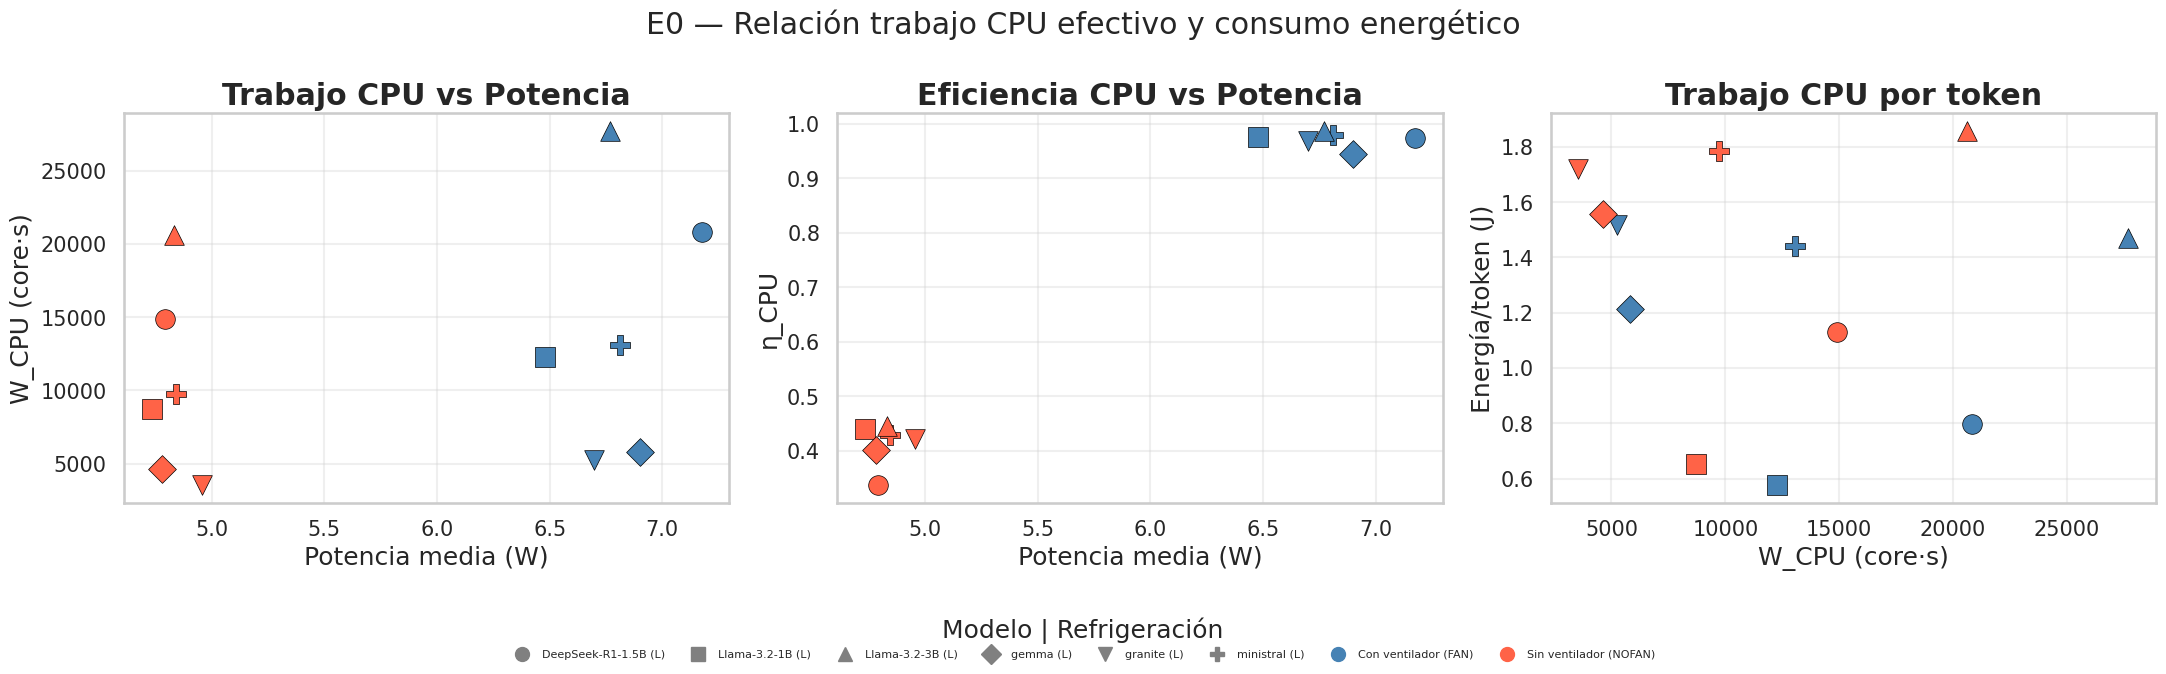

In [24]:
# Helpers de scatter reutilizables en el notebook
MARKERS    = ["o", "s", "^", "D", "v", "P", "*", "X", "h", "<"]
COLORS_FAN = {True: "steelblue", False: "tomato"}
LABELS_FAN = {True: "FAN", False: "NOFAN"}
OFFSETS    = [(5,5),(-5,-10),(10,-5),(-10,5),(5,-15),(-5,10),
              (15,0),(-15,0),(0,12),(-12,-5),(8,-8),(-8,8)]

def scatter_with_legend(ax, data, x, y, label_col="model_label", fan_col="fan"):
    models    = sorted(data[label_col].unique())
    marker_map = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}
    seen = set()
    for _, row in data.iterrows():
        model = row[label_col]; fan = row.get(fan_col, True); key = (model, fan)
        lbl = f"{model} ({LABELS_FAN.get(fan, str(fan))})" if key not in seen else None
        ax.scatter(row[x], row[y], marker=marker_map[model],
                   color=COLORS_FAN.get(fan, "gray"), s=150, zorder=3, label=lbl)
        seen.add(key)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8,
              title="Modelo (refrigeraci\u00f3n)", framealpha=0.9)
    ax.grid(True, alpha=0.3)

def scatter_cpu_energy(ax, df, x_col, y_col, x_label, y_label, title):
    models  = sorted(df["model_label"].unique())
    mk_map  = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}
    for idx, (_, row) in enumerate(df.iterrows()):
        if pd.isna(row.get(x_col)) or pd.isna(row.get(y_col)): continue
        m, fan = row["model_label"], row["fan"]
        ax.scatter(row[x_col], row[y_col],
                marker=mk_map[m], color=COLORS_FAN[fan],

                   s=200, zorder=3, edgecolors='black', linewidths=0.5)
        ox, oy = OFFSETS[idx % len(OFFSETS)]
        # ax.annotate(
        #     f"{m}\n({LABELS_FAN[fan]})",
        #     xy=(row[x_col], row[y_col]),
        #     xytext=(ox, oy), textcoords="offset points",
        #     fontsize=7, ha='center',
        #     arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        # )
    ax.set_xlabel(x_label); ax.set_ylabel(y_label)
    ax.set_title(title); ax.grid(True, alpha=0.3)

if not summary.empty:
    cpu_e = summary.dropna(subset=["cpu_work_core_s", "power_mean_w"]).copy()
    if not cpu_e.empty:
        fig, axes = plt.subplots(1, 3, figsize=(22, 6))
        scatter_cpu_energy(axes[0], cpu_e,
            "power_mean_w",    "cpu_work_core_s",
            "Potencia media (W)", "W_CPU (core\u00b7s)", "Trabajo CPU vs Potencia")
        scatter_cpu_energy(axes[1], cpu_e,
            "power_mean_w",    "cpu_efficiency",
            "Potencia media (W)", "\u03b7_CPU", "Eficiencia CPU vs Potencia")
        scatter_cpu_energy(axes[2], cpu_e,
            "cpu_work_core_s", "energy_per_token_j",
            "W_CPU (core\u00b7s)", "Energ\u00eda/token (J)", "Trabajo CPU por token")
        from matplotlib.lines import Line2D
        models = sorted(cpu_e["model_label"].unique())
        mk_map = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}
        legend_elements = (
            [Line2D([0],[0], marker=mk_map[m], color='gray',
                     markerfacecolor='gray', ms=10, label=m, linestyle='None')
             for m in models] +
            [Line2D([0],[0], marker='o', color=c, markerfacecolor=c,
                     ms=10, label=l, linestyle='None')
             for c, l in [("steelblue","Con ventilador (FAN)"),
                           ("tomato",  "Sin ventilador (NOFAN)")]]
        )
        fig.legend(handles=legend_elements, loc='lower center',
                   ncol=len(models)+2, fontsize=8,
                   bbox_to_anchor=(0.5, -0.12), title="Modelo | Refrigeraci\u00f3n")
        fig.suptitle("E0 \u2014 Relaci\u00f3n trabajo CPU efectivo y consumo energ\u00e9tico")
        fig.tight_layout(); plt.show()
    else:
        print('Sin datos suficientes para gr\u00e1ficas de CPU vs Potencia.')
else:
    print('Sin datos de summary para an\u00e1lisis CPU vs Potencia.')


## 6. Rendimiento combinado y utilización de hardware

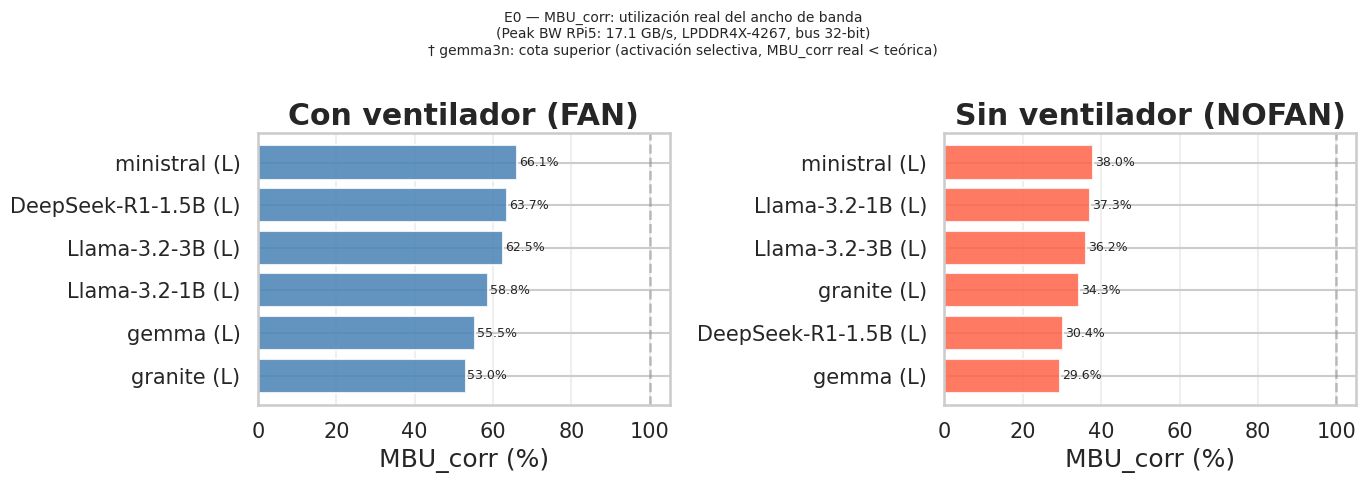

Correcciones aplicadas:


,model_label,mbu_corr,mbu_corr_notes
0,ministral (L),66.13,dense
1,Llama-3.2-3B (L),62.46,dense
2,Llama-3.2-1B (L),58.78,dense
3,granite (L),52.96,"Granite SSM hybrid: M_state=74.4 MiB, L_ssm=36..."
4,gemma (L),55.46,Gemma 3n MatFormer: N_params_act=1.910B (verif...
5,DeepSeek-R1-1.5B (L),63.65,dense


In [25]:
# MBU_corr — Memory Bandwidth Utilization (arquitectura corregida)
from monitorviz.viz.style import TARGET_PEAK_MEMORY_BANDWIDTH_GBs

_mbu_col = "mbu_corr" if "mbu_corr" in summary.columns else (
           "mbu_pct"  if "mbu_pct"  in summary.columns else None)

if _mbu_col is not None:
    mbu_data = summary.dropna(subset=[_mbu_col]).copy()
    if not mbu_data.empty:
        has_fan = "fan" in mbu_data.columns and mbu_data["fan"].nunique() > 1
        fan_groups = (
            [(True, "Con ventilador (FAN)", "steelblue"),
             (False, "Sin ventilador (NOFAN)", "tomato")]
            if has_fan else [(None, "MBU_corr", "steelblue")]
        )
        fig, axes = plt.subplots(1, len(fan_groups),
                                  figsize=(7 * len(fan_groups), 5), sharey=False)
        if len(fan_groups) == 1:
            axes = [axes]
        for ax, (fan_val, lbl, color) in zip(axes, fan_groups):
            sub = (mbu_data[mbu_data["fan"] == fan_val]
                   if fan_val is not None else mbu_data).copy()
            sub = sub.sort_values(_mbu_col)
            if sub.empty:
                ax.set_axis_off(); continue
            ax.barh(sub["model_label"], sub[_mbu_col], color=color, alpha=0.85)
            ax.axvline(100, ls="--", color="gray", alpha=0.5)
            ax.set_xlabel("MBU_corr (%)")
            ax.set_title(lbl)
            ax.grid(True, axis="x", alpha=0.3)
            for bar, val in zip(ax.patches, sub[_mbu_col]):
                ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                        f"{val:.1f}%", va="center", fontsize=9)
        fig.suptitle(
            f"E0 — MBU_corr: utilización real del ancho de banda\n"
            f"(Peak BW RPi5: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s, LPDDR4X-4267, bus 32-bit)\n"
            "† gemma3n: cota superior (activación selectiva, MBU_corr real < teórica)",
            fontsize=10)
        plt.tight_layout()
        plt.show()
        if "mbu_corr_notes" in mbu_data.columns:
            notes = (mbu_data[["model_label","mbu_corr","mbu_corr_notes"]]
                     .drop_duplicates("model_label").round(2))
            print("Correcciones aplicadas:")
            display(notes)
else:
    print("mbu_corr no disponible en este experimento.")


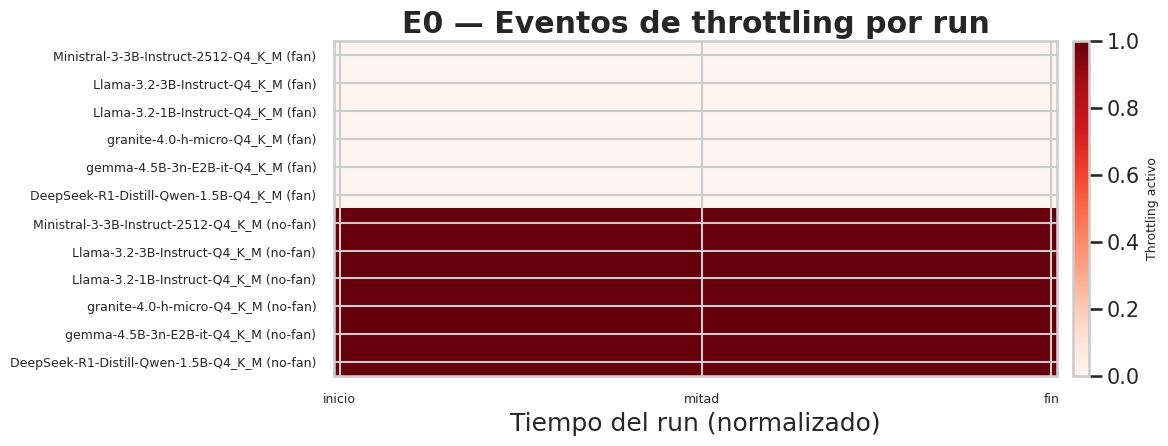

In [26]:
if not hw_df.empty:
    runs_con_hw = [r for r in coll.runs
                   if not hw_df[hw_df['run_id'] == r.run_id].empty]
    if runs_con_hw:
        try:
            fig = throttling_heatmap(hw_df, runs_con_hw,
                                     title='E0 \u2014 Eventos de throttling por run')
            plt.show()
        except Exception as e:
            print(f'throttling_heatmap: {e}')
    else:
        print('Sin runs con datos de hardware para throttling heatmap.')
else:
    print('Sin datos de hardware para throttling heatmap.')


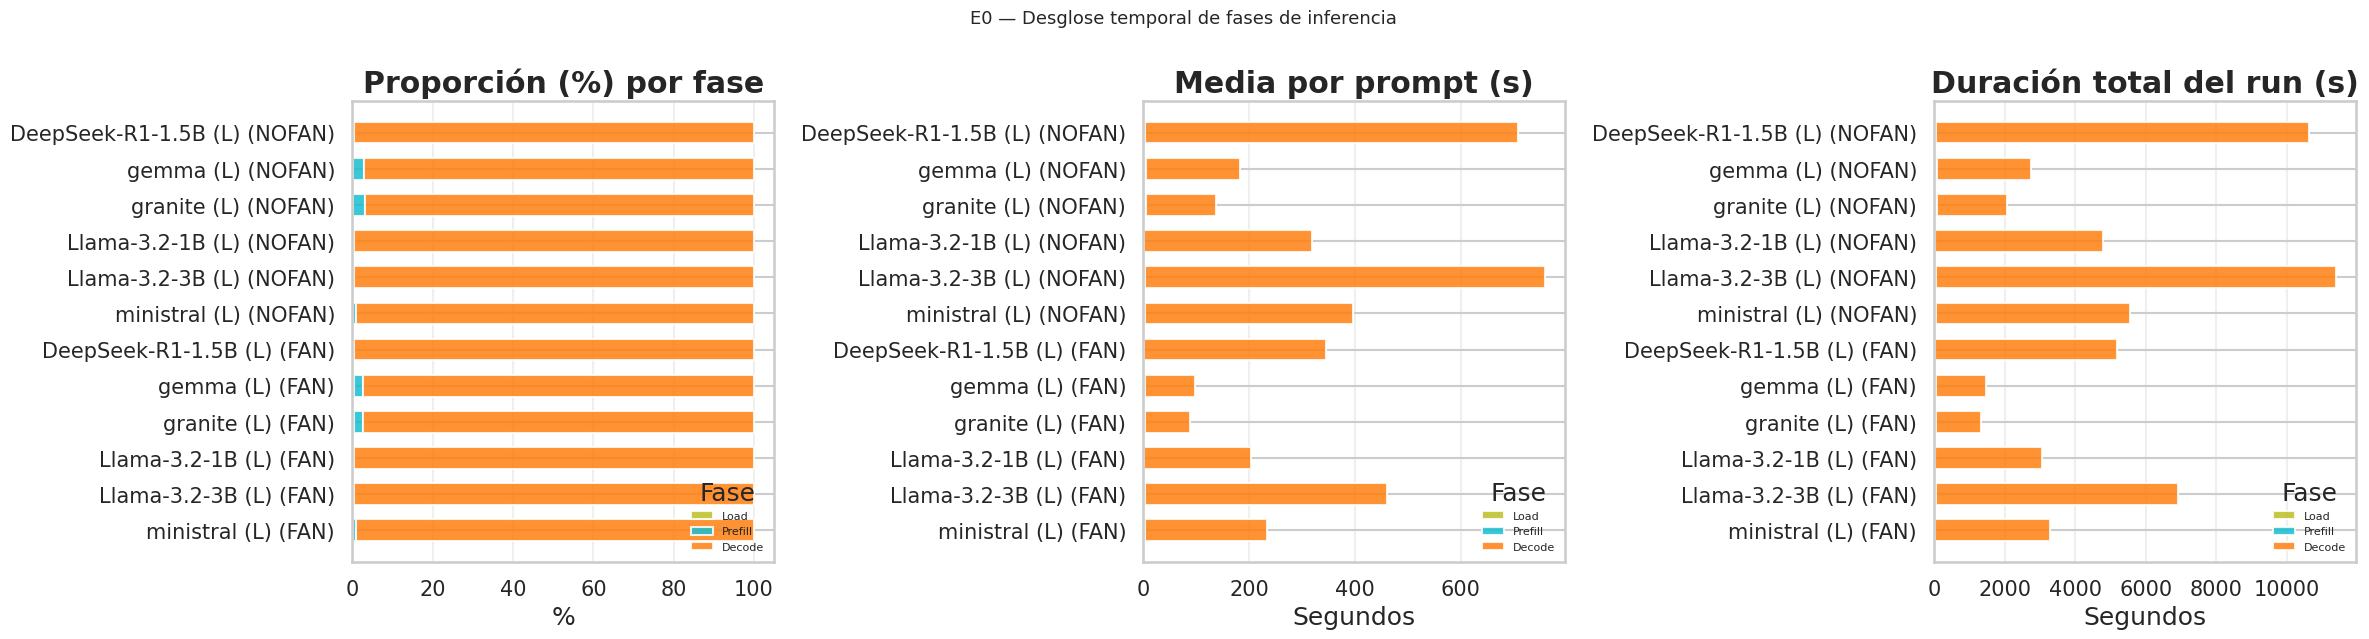

In [27]:
if not summary.empty:
    phase_cols = {}
    for run in coll.runs:
        rid   = run.run_id
        label = summary.loc[summary["run_id"] == rid, "model_label"].values
        fan   = summary.loc[summary["run_id"] == rid, "fan"].values
        if len(label) == 0: continue
        non_empty = [p for p in run.prompts if not p.is_empty_generation]
        if not non_empty: continue
        phase_cols.setdefault("model_label", []).append(label[0])
        phase_cols.setdefault("fan",         []).append(fan[0])
        # Media por prompt
        phase_cols.setdefault("load_s",      []).append(
            np.mean([p.load_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("prefill_s",   []).append(
            np.mean([p.prompt_eval_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("decode_s",    []).append(
            np.mean([p.eval_duration_ns / 1e9 for p in non_empty]))
        # Total del run (suma sobre todos los prompts)
        phase_cols.setdefault("load_total_s",    []).append(
            np.sum([p.load_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("prefill_total_s", []).append(
            np.sum([p.prompt_eval_duration_ns / 1e9 for p in non_empty]))
        phase_cols.setdefault("decode_total_s",  []).append(
            np.sum([p.eval_duration_ns / 1e9 for p in non_empty]))

    phase_df2 = pd.DataFrame(phase_cols)
    if not phase_df2.empty:
        phase_df2["config"] = (
            phase_df2["model_label"] + " (" +
            phase_df2["fan"].map({True: "FAN", False: "NOFAN"}) + ")"
        )

    PHASES       = ["load_s",       "prefill_s",       "decode_s"]
    PHASES_TOTAL = ["load_total_s", "prefill_total_s", "decode_total_s"]
    LABELS  = {"load_s": "Load", "prefill_s": "Prefill", "decode_s": "Decode",
               "load_total_s": "Load", "prefill_total_s": "Prefill", "decode_total_s": "Decode"}
    COLORS  = {"load_s": "#bcbd22", "prefill_s": "#17becf", "decode_s": "#ff7f0e",
               "load_total_s": "#bcbd22", "prefill_total_s": "#17becf", "decode_total_s": "#ff7f0e"}

    if not phase_df2.empty:
        n_configs = len(phase_df2)
        fig, axes = plt.subplots(1, 3, figsize=(24, max(5, n_configs * 0.55)))

        # Panel 1: Proporci\u00f3n (%) — usa totales para la proporci\u00f3n real
        ax = axes[0]
        total_run = phase_df2[PHASES_TOTAL].sum(axis=1)
        left = np.zeros(n_configs)
        for ph, ph_t in zip(PHASES, PHASES_TOTAL):
            vals = phase_df2[ph_t] / total_run * 100
            ax.barh(phase_df2["config"], vals, left=left,
                    label=LABELS[ph], color=COLORS[ph], alpha=0.85, height=0.6)
            left += vals.to_numpy()
        ax.set_title("Proporci\u00f3n (%) por fase")
        ax.set_xlim(0, 105); ax.set_xlabel("%")
        ax.set_ylabel(""); ax.legend(title="Fase", loc="lower right", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

        # Panel 2: Media por prompt (s)
        ax = axes[1]
        left = np.zeros(n_configs)
        for ph in PHASES:
            ax.barh(phase_df2["config"], phase_df2[ph], left=left,
                    label=LABELS[ph], color=COLORS[ph], alpha=0.85, height=0.6)
            left += phase_df2[ph].to_numpy()
        ax.set_title("Media por prompt (s)")
        ax.set_xlabel("Segundos"); ax.set_ylabel("")
        ax.legend(title="Fase", loc="lower right", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

        # Panel 3: Total del run (s)
        ax = axes[2]
        left = np.zeros(n_configs)
        for ph_t in PHASES_TOTAL:
            ax.barh(phase_df2["config"], phase_df2[ph_t], left=left,
                    label=LABELS[ph_t], color=COLORS[ph_t], alpha=0.85, height=0.6)
            left += phase_df2[ph_t].to_numpy()
        ax.set_title("Duraci\u00f3n total del run (s)")
        ax.set_xlabel("Segundos"); ax.set_ylabel("")
        ax.legend(title="Fase", loc="lower right", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

        fig.suptitle("E0 \u2014 Desglose temporal de fases de inferencia", fontsize=13)
        fig.tight_layout(); plt.show()
    else:
        print("Sin datos de fases.")
else:
    print("Sin datos de summary para desglose de fases.")
    phase_df2 = pd.DataFrame()
    PHASES = []; PHASES_TOTAL = []; COLORS = {}


In [28]:
if not phase_df2.empty and "power_mean_w" in summary.columns:
    merged = phase_df2.merge(
        summary[["model_label", "fan", "power_mean_w"]],
        on=["model_label", "fan"], how="left"
    )
    # Energía = potencia media × duración total de cada fase
    for ph, ph_t in zip(PHASES, PHASES_TOTAL):
        merged[ph.replace("_s", "_mean_j")] = merged["power_mean_w"] * merged[ph]
        merged[ph_t.replace("_total_s", "_total_j")] = merged["power_mean_w"] * merged[ph_t]

    result_rows = []
    for model in sorted(merged["model_label"].unique()):
        row = {"Modelo": model}
        for fan_val, fan_label in [(True, "FAN"), (False, "NOFAN")]:
            sub = merged[(merged["model_label"] == model) & (merged["fan"] == fan_val)]
            if sub.empty:
                continue
            for ph_base, ph_label in [("load", "Load"), ("prefill", "Prefill"), ("decode", "Decode")]:
                row[f"{ph_label} s/prompt ({fan_label})"] = sub[f"{ph_base}_s"].values[0]
                row[f"{ph_label} s total ({fan_label})"]  = sub[f"{ph_base}_total_s"].values[0]
                row[f"{ph_label} J total ({fan_label})"]  = sub[f"{ph_base}_total_j"].values[0]
        result_rows.append(row)

    result = pd.DataFrame(result_rows).round(2)
    print("E0 \u2014 Duraci\u00f3n y energ\u00eda por fase (s/prompt = media; total = suma del run)")
    display(result)


E0 — Duración y energía por fase (s/prompt = media; total = suma del run)


,Modelo,Load s/prompt (FAN),Load s total (FAN),Load J total (FAN),Prefill s/prompt (FAN),Prefill s total (FAN),Prefill J total (FAN),Decode s/prompt (FAN),Decode s total (FAN),Decode J total (FAN),Load s/prompt (NOFAN),Load s total (NOFAN),Load J total (NOFAN),Prefill s/prompt (NOFAN),Prefill s total (NOFAN),Prefill J total (NOFAN),Decode s/prompt (NOFAN),Decode s total (NOFAN),Decode J total (NOFAN)
0,DeepSeek-R1-1.5B (L),0.09,1.32,9.46,0.86,12.95,92.93,344.84,5172.61,37116.22,0.09,1.39,6.67,2.30,34.47,165.22,707.24,10608.53,50847.76
1,Llama-3.2-1B (L),0.06,0.92,5.97,0.61,9.17,59.39,203.49,3052.33,19777.22,0.06,0.93,4.41,1.15,17.28,81.79,318.51,4777.68,22614.48
2,Llama-3.2-3B (L),0.18,2.68,18.15,1.76,26.43,178.93,459.79,6896.82,46682.66,0.19,2.84,13.75,3.53,52.92,255.74,756.07,11341.12,54805.54
3,gemma (L),0.29,4.28,29.56,2.33,34.91,240.88,94.05,1410.78,9734.13,0.31,4.71,22.53,4.85,72.76,347.87,176.90,2653.51,12685.83
4,granite (L),0.25,3.70,24.75,2.10,31.53,211.19,85.17,1277.58,8557.09,0.26,3.93,19.49,3.96,59.47,294.82,132.34,1985.11,9840.37
5,ministral (L),0.22,3.05,20.80,1.71,23.95,163.17,231.70,3243.76,22099.57,0.24,3.35,16.24,3.46,48.49,234.85,393.13,5503.80,26653.47


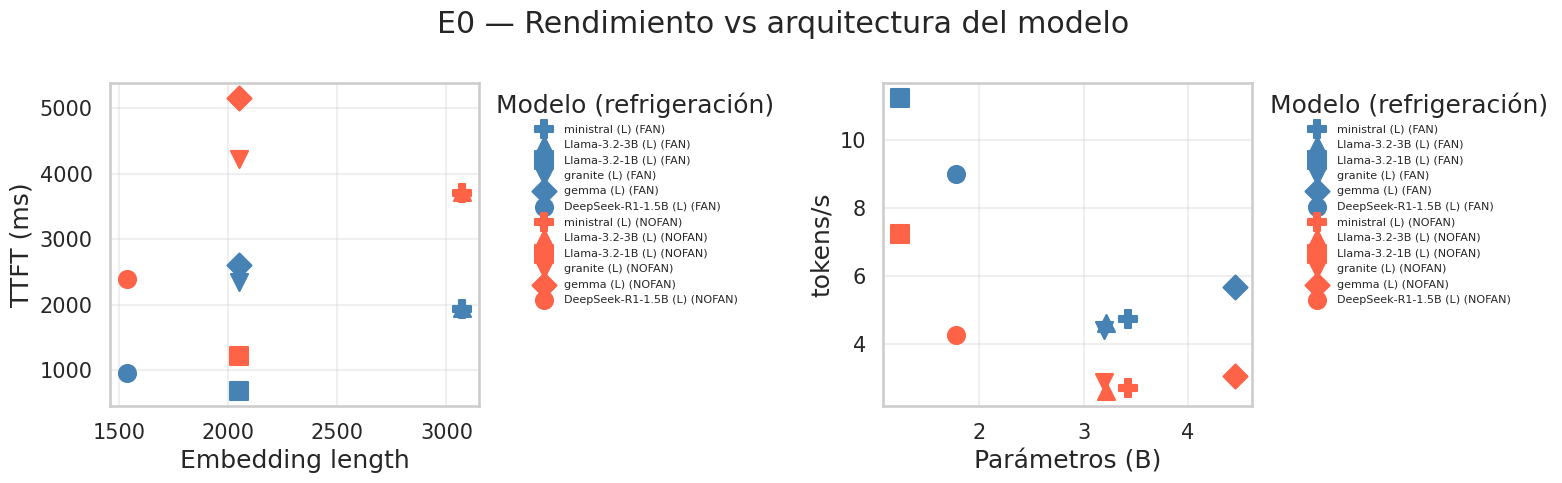

In [29]:
if not summary.empty:
    run_map = {r.run_id: r for r in coll.runs}
    n_params_list, emb_len_list = [], []
    for rid in summary['run_id']:
        r = run_map.get(rid)
        mi = (r.summary.model_info or {}) if r else {}
        n_params_list.append(mi.get('n_params', float('nan')))
        emb_len_list.append(mi.get('embedding_length', float('nan')))
    summary_arch = summary.copy()
    summary_arch['n_params_b'] = pd.array(n_params_list, dtype='float64') / 1e9
    summary_arch['emb_len']    = pd.array(emb_len_list, dtype='float64')

    arch = summary_arch.dropna(subset=['n_params_b', 'emb_len'])
    if not arch.empty:
        plot_triples = [
            ('emb_len',    'ttft_ms_mean',      'Embedding length', 'TTFT (ms)'),
            ('n_params_b', 'tokens_per_s_mean', 'Par\u00e1metros (B)', 'tokens/s'),
            ('n_params_b', 'ttlm_ms',           'Par\u00e1metros (B)', 'TTLM (ms)'),
        ]
        plot_triples = [(x, y, xl, yl) for x, y, xl, yl in plot_triples
                        if y in arch.columns]
        if plot_triples:
            fig, axes = plt.subplots(1, len(plot_triples),
                                     figsize=(8 * len(plot_triples), 5))
            if len(plot_triples) == 1:
                axes = [axes]
            for ax, (x, y, xl, yl) in zip(axes, plot_triples):
                scatter_with_legend(ax, arch, x, y)
                ax.set_xlabel(xl)
                ax.set_ylabel(yl)
            fig.suptitle('E0 \u2014 Rendimiento vs arquitectura del modelo')
            plt.tight_layout()
            plt.show()
    else:
        print('Sin model_info disponible para gr\u00e1ficas de arquitectura.')
else:
    print('Sin datos de summary para an\u00e1lisis de arquitectura.')


## 7. Trade-offs y análisis multidimensional

Columnas normalizadas por parámetros:
             model_label      n_params  tokens_per_s_mean  tok_s_per_Mparam  energy_per_token_j  j_token_x_Mparam
0          ministral (L)  3.429006e+09             4.7313            0.0014              1.4400         4937.6820
1       Llama-3.2-3B (L)  3.212750e+09             4.6081            0.0014              1.4689         4719.1773
2       Llama-3.2-1B (L)  1.235814e+09            11.2293            0.0091              0.5770          713.0757
3            granite (L)  3.191396e+09             4.4099            0.0014              1.5188         4847.2171
4              gemma (L)  1.910000e+09             5.6829            0.0030              1.2141         2318.9966
5   DeepSeek-R1-1.5B (L)  1.777088e+09             8.9783            0.0051              0.7992         1420.2608
6          ministral (L)  3.429006e+09             2.7142            0.0008              1.7842         6118.0814
7       Llama-3.2-3B (L)  3.212750e+09            

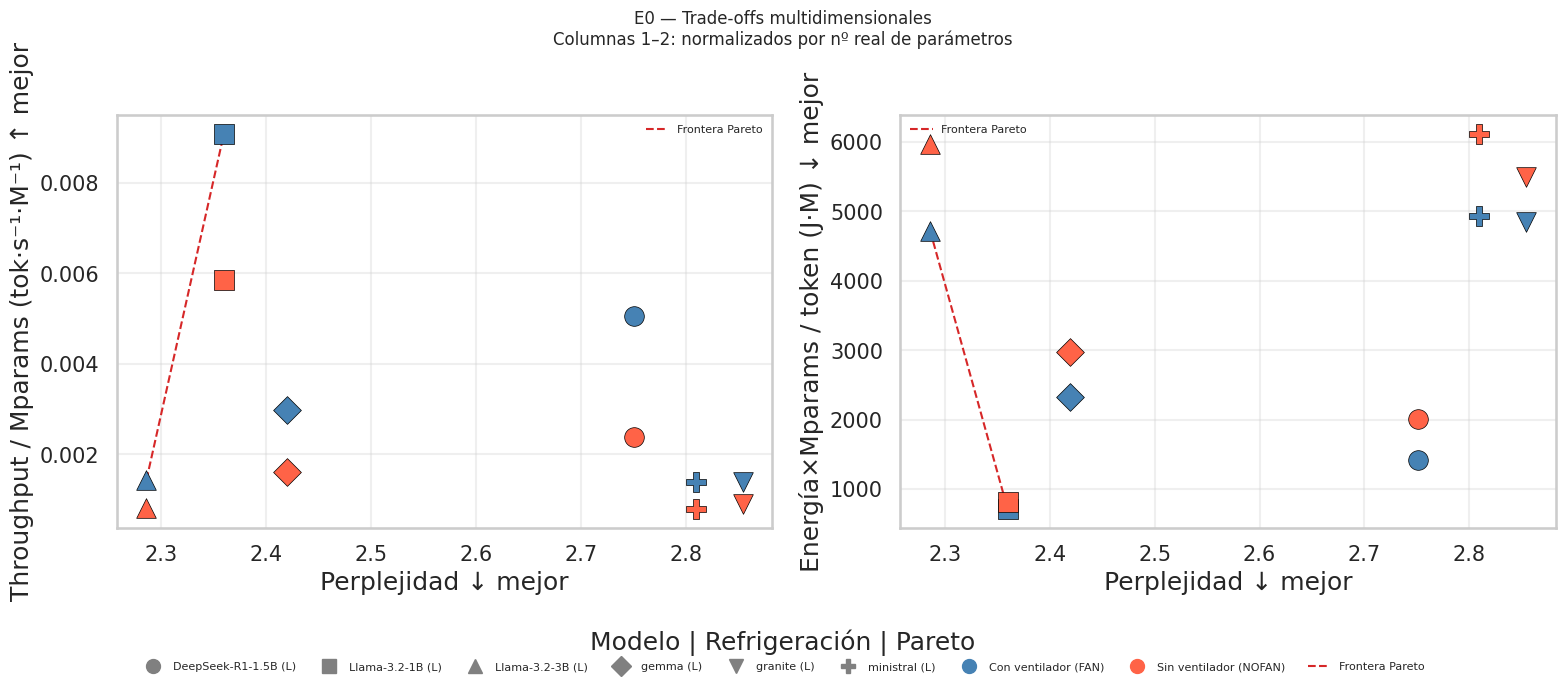

In [30]:
def _pareto_front(df, x_col, y_col, x_lower, y_lower):
    """Devuelve las filas en la frontera de Pareto."""
    pts = df[[x_col, y_col]].to_numpy()
    n = len(pts)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            x_ok = (pts[j,0] <= pts[i,0]) if x_lower else (pts[j,0] >= pts[i,0])
            y_ok = (pts[j,1] <= pts[i,1]) if y_lower else (pts[j,1] >= pts[i,1])
            strict = (pts[j,0] != pts[i,0]) or (pts[j,1] != pts[i,1])
            if x_ok and y_ok and strict:
                dominated[i] = True; break
    return df[~dominated].sort_values(x_col)

if not summary.empty:
    # ── Métricas normalizadas por número real de parámetros ──────────────────
    # Se escala a "por millón de parámetros" (÷1e6) para mantener
    # los valores del eje en rango legible manteniendo la precisión real.
    if "n_params" in summary.columns and summary["n_params"].notna().any():
        n_M = summary["n_params"] / 1e6

        # tok/s por millón de parámetros (↑ mejor)
        summary["tok_s_per_Mparam"] = summary["tokens_per_s_mean"] / n_M

        # J/token × millones de parámetros (↓ mejor)
        summary["j_token_x_Mparam"] = summary["energy_per_token_j"] * n_M

        print("Columnas normalizadas por parámetros:")
        print(
            summary[["model_label", "n_params", "tokens_per_s_mean",
                      "tok_s_per_Mparam", "energy_per_token_j", "j_token_x_Mparam"]]
            .round(4)
        )
    else:
        print("n_params no disponible; se omiten pares normalizados del Pareto.")

    PAIRS = [
        # ── Bloque A: valores ABSOLUTOS ──────────────────────────────────────
        # (
        #     "perplexity_geomean", "tokens_per_s_mean",
        #     "Perplejidad ↓ mejor", "Throughput (tok/s) ↑ mejor",
        #     True, False,
        # ),
        # (
        #     "perplexity_geomean", "energy_per_token_j",
        #     "Perplejidad ↓ mejor", "Energía/token (J) ↓ mejor",
        #     True, True,
        # ),
        # (
        #     "power_mean_w", "tokens_per_s_mean",
        #     "Potencia media (W) ↓ mejor", "Throughput (tok/s) ↑ mejor",
        #     True, False,
        # ),
        # ── Bloque B: valores NORMALIZADOS por nº real de parámetros ─────────
        (
            "perplexity_geomean", "tok_s_per_Mparam",
            "Perplejidad ↓ mejor", "Throughput / Mparams (tok·s⁻¹·M⁻¹) ↑ mejor",
            True, False,
        ),
        (
            "perplexity_geomean", "j_token_x_Mparam",
            "Perplejidad ↓ mejor", "Energía×Mparams / token (J·M) ↓ mejor",
            True, True,
        ),
    ]

    pairs = [
        (x, y, xl, yl, xb, yb)
        for x, y, xl, yl, xb, yb in PAIRS
        if x in summary.columns and y in summary.columns
        and summary[[x, y]].dropna().shape[0] >= 2
    ]

    n_abs  = sum(1 for p in pairs if "Mparam" not in p[3])
    n_norm = sum(1 for p in pairs if "Mparam"     in p[3])
    print(f"Pares Pareto: {n_abs} absolutos + {n_norm} normalizados = {len(pairs)} total")

    if pairs:
        from matplotlib.lines import Line2D
        ncols = len(pairs)
        fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 6))
        if ncols == 1: axes = [axes]

        models = sorted(summary["model_label"].unique())
        mk_map = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(models)}

        for ax, (x_col, y_col, x_label, y_label, x_lower, y_lower) in zip(axes, pairs):
            data = summary.dropna(subset=[x_col, y_col]).copy().reset_index(drop=True)
            if data.empty:
                ax.set_visible(False); continue

            for idx, (_, row) in enumerate(data.iterrows()):
                m, fan = row["model_label"], row["fan"]
                ax.scatter(row[x_col], row[y_col],
                           marker=mk_map[m], color=COLORS_FAN[fan],
                           s=200, zorder=3, edgecolors='black', linewidths=0.5)

            front = _pareto_front(data, x_col, y_col, x_lower, y_lower)
            ax.plot(front[x_col], front[y_col],
                    color="tab:red", lw=1.5, ls="--", zorder=2,
                    label="Frontera Pareto")
            ax.legend(fontsize=8, loc="best")

            # Labels ya incluyen ↓/↑ mejor — no añadir de nuevo
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            ax.grid(True, alpha=0.3)

        legend_elements = (
            [Line2D([0],[0], marker=mk_map[m], color='gray',
                     markerfacecolor='gray', ms=10, label=m, linestyle='None')
             for m in models] +
            [Line2D([0],[0], marker='o', color=c, markerfacecolor=c,
                     ms=10, label=l, linestyle='None')
             for c, l in [("steelblue", "Con ventilador (FAN)"),
                           ("tomato",   "Sin ventilador (NOFAN)")]] +
            [Line2D([0],[0], color='tab:red', lw=1.5, ls='--',
                     label='Frontera Pareto')]
        )
        fig.legend(handles=legend_elements, loc='lower center',
                   ncol=len(models) + 3, fontsize=8,
                   bbox_to_anchor=(0.5, -0.10),
                   title="Modelo | Refrigeración | Pareto")
        fig.suptitle(
            "E0 — Trade-offs multidimensionales\n"
            # f"Columnas 1–{n_abs}: valores absolutos  |  "
            f"Columnas {n_abs+1}–{ncols}: normalizados por nº real de parámetros",
            fontsize=12, y=1.02,
        )
        plt.tight_layout(); plt.show()
    else:
        print('Columnas insuficientes para Pareto.')
else:
    print('Sin datos de summary para Pareto.')


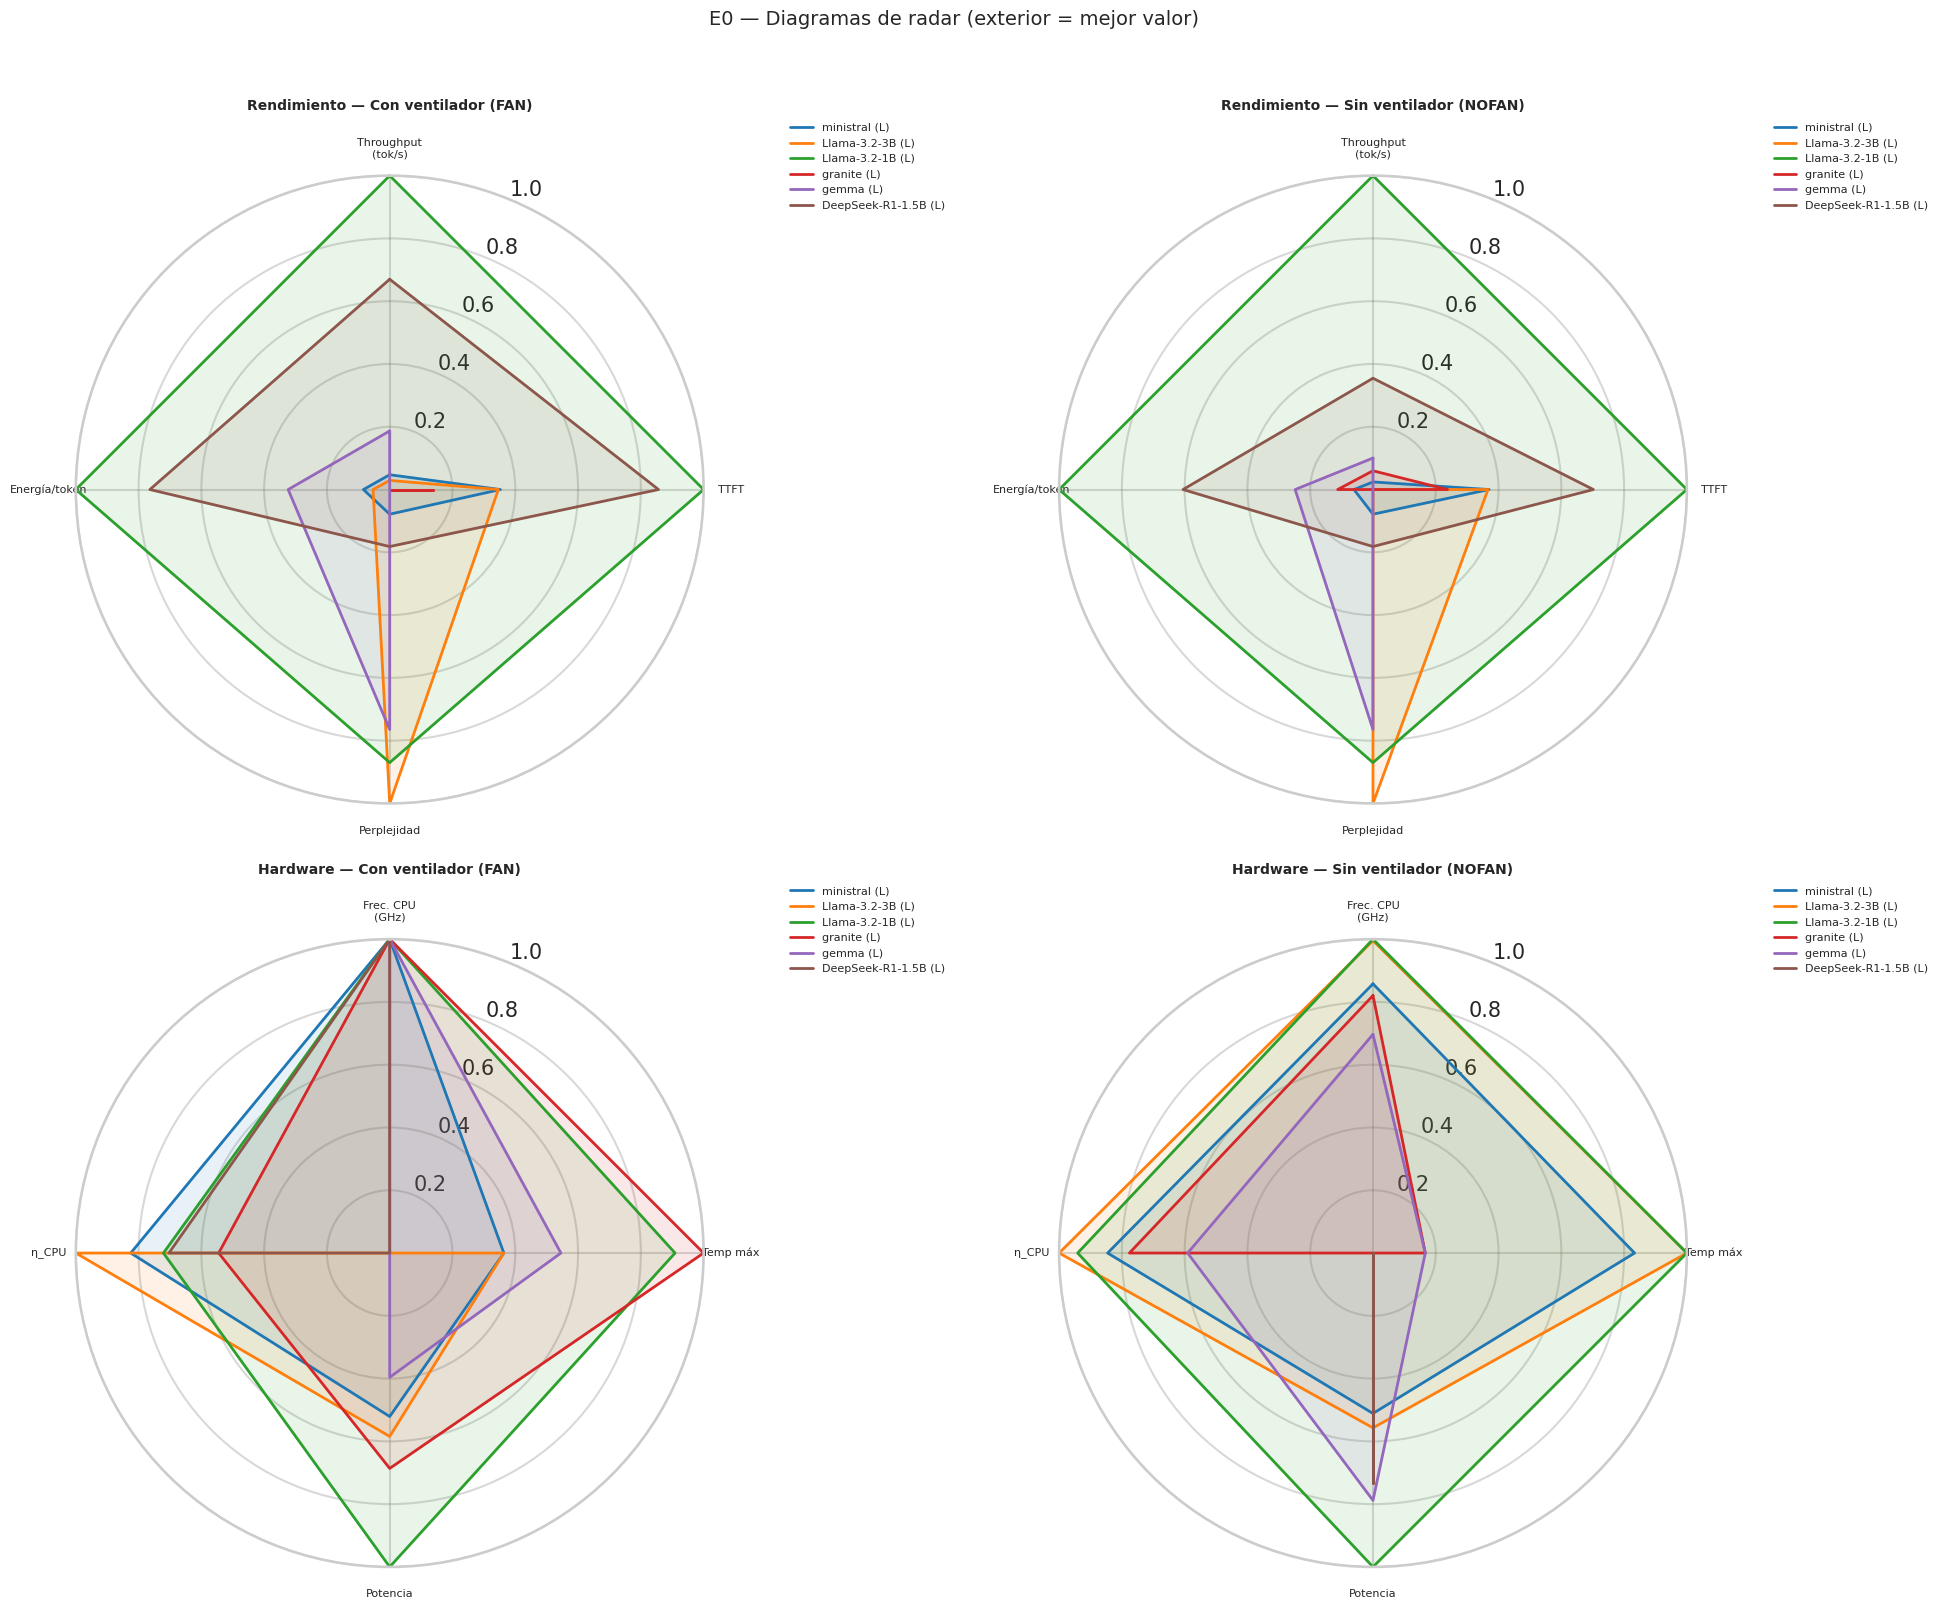

In [31]:
def _radar_chart(ax, df, metrics, title, colors):
    """Radar chart sobre un eje polar."""
    cols             = [m[0] for m in metrics]
    labels           = [m[1] for m in metrics]
    higher_is_better = [m[2] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.set_title(f"{title}\n(sin datos)", pad=15)
        return
    N      = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=8)
    ax.set_ylim(0, 1)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=20, fontsize=10, fontweight="bold")
    for col, hib in zip(cols, higher_is_better):
        mn, mx = data[col].min(), data[col].max()
        rng = mx - mn if mx != mn else 1.0
        data[f"_n_{col}"] = (data[col] - mn) / rng if hib else (mx - data[col]) / rng
    for i, (_, row) in enumerate(data.iterrows()):
        vals = [row[f"_n_{c}"] for c in cols] + [row[f"_n_{cols[0]}"]]
        ax.plot(angles, vals, lw=2, color=colors[i % len(colors)],
                label=row["model_label"])
        ax.fill(angles, vals, alpha=0.10, color=colors[i % len(colors)])
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)

if not summary.empty:
    PERF_METRICS = [
        ("tokens_per_s_mean",  "Throughput\n(tok/s)", True),
        ("ttft_ms_mean",       "TTFT",                False),
        ("perplexity_geomean", "Perplejidad",          False),
        ("energy_per_token_j", "Energía/token",        False),
    ]
    HW_METRICS = [
        ("freq_mean_inference_ghz", "Frec. CPU\n(GHz)", True),   # ↑ mejor: menos throttling
        ("temp_max_c",              "Temp máx",          False),  # ↓ mejor
        ("power_mean_w",            "Potencia",          False),  # ↓ mejor
        ("cpu_efficiency",          "η_CPU",             True),   # ↑ mejor
    ]
    COLORS_R = [f"C{i}" for i in range(10)]

    s_fan   = summary[summary["fan"] == True].copy()
    s_nofan = summary[summary["fan"] == False].copy()

    fig = plt.figure(figsize=(20, 16))
    panels = [
        (221, s_fan,   PERF_METRICS, "Rendimiento — Con ventilador (FAN)"),
        (222, s_nofan, PERF_METRICS, "Rendimiento — Sin ventilador (NOFAN)"),
        (223, s_fan,   HW_METRICS,   "Hardware — Con ventilador (FAN)"),
        (224, s_nofan, HW_METRICS,   "Hardware — Sin ventilador (NOFAN)"),
    ]
    for pos, data, metrics, title in panels:
        ax = fig.add_subplot(pos, polar=True)
        avail = [(c, l, h) for c, l, h in metrics if c in data.columns]
        _radar_chart(ax, data, avail, title, COLORS_R)

    fig.suptitle("E0 — Diagramas de radar (exterior = mejor valor)",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Sin datos para diagramas polares.')


In [32]:
# ── Anexo: Tablas comparativas E0 (inferencia + hardware con σ) ─────────────
if not summary.empty:
    _hw0 = hw_df if "hw_df" in vars() else (hw_full if "hw_full" in vars() else pd.DataFrame())
    _pm0 = pm_df if "pm_df" in vars() else (pm_full if "pm_full" in vars() else pd.DataFrame())

    # σ inferencia desde pm por prompt
    _smry0 = summary.copy()
    if not _pm0.empty and "run_id" in _pm0.columns:
        _valid0 = _pm0[~_pm0["is_empty_generation"]] if "is_empty_generation" in _pm0.columns else _pm0
        _si_cols = [c for c in ["tokens_per_second", "time_to_first_token_ms", "perplexity"]
                    if c in _valid0.columns]
        if _si_cols:
            _si = (_valid0.groupby("run_id")[_si_cols].std().reset_index()
                   .rename(columns={"tokens_per_second":      "tokens_per_s_std",
                                    "time_to_first_token_ms": "ttft_ms_std",
                                    "perplexity":             "perplexity_std"}))
            _smry0 = _smry0.merge(_si, on="run_id", how="left")

    # σ hardware desde muestras hw por run
    if not _hw0.empty and "run_id" in _hw0.columns:
        _sh_cols = [c for c in ["temperature_c", "internal_power_w", "freq_mean_ghz"]
                    if c in _hw0.columns]
        if _sh_cols:
            _sh = (_hw0.groupby("run_id")[_sh_cols].std().reset_index()
                   .rename(columns={"temperature_c":   "temp_std_c",
                                    "internal_power_w": "power_std_w",
                                    "freq_mean_ghz":   "freq_std_ghz"}))
            _smry0 = _smry0.merge(_sh, on="run_id", how="left")

    _fan_fmt = lambda x: "FAN ✓" if x else "NOFAN ✗"

    # Tabla 1 — Inferencia
    _inf_cols = [c for c in [
        "model_label", "fan",
        "tokens_per_s_mean", "tokens_per_s_std",
        "ttft_ms_mean",      "ttft_ms_std",
        "latency_ms_mean",
        "perplexity_geomean","perplexity_std",
    ] if c in _smry0.columns]
    _t1 = _smry0[_inf_cols].sort_values(["model_label","fan"]).round(3).copy()
    _t1["fan"] = _t1["fan"].map(_fan_fmt)
    _t1.columns = (_t1.columns
                   .str.replace("_mean","").str.replace("_std"," σ")
                   .str.replace("tokens_per_s","tok/s").str.replace("ttft_ms","TTFT (ms)")
                   .str.replace("latency_ms","lat (ms)").str.replace("perplexity_geomean","PPL")
                   .str.replace("_"," "))
    print("Tabla comparativa E0 — Inferencia")
    display(_t1.reset_index(drop=True))

    # Tabla 2 — Hardware
    _hw_cols = [c for c in [
        "model_label", "fan",
        "temp_max_c", "temp_mean_c", "temp_std_c",
        "power_mean_w", "power_std_w",
        "freq_mean_inference_ghz", "freq_std_ghz",
        "throttled_ratio",
        "energy_per_token_j", "cpu_work_core_s", "cpu_efficiency",
    ] if c in _smry0.columns]
    _t2 = _smry0[_hw_cols].sort_values(["model_label","fan"]).round(3).copy()
    _t2["fan"] = _t2["fan"].map(_fan_fmt)
    print("\nTabla comparativa E0 — Hardware")
    display(_t2.reset_index(drop=True))
else:
    print("Sin datos de summary.")


Tabla comparativa E0 — Inferencia


,model label,fan,tok/s,tok/s σ,TTFT (ms),TTFT (ms) σ,lat (ms),PPL,perplexity σ
0,DeepSeek-R1-1.5B (L),NOFAN ✗,4.245,0.422,2390.779,923.554,735182.399,2.751,0.931
1,DeepSeek-R1-1.5B (L),FAN ✓,8.978,1.290,951.215,554.058,354852.604,2.751,0.931
2,Llama-3.2-1B (L),NOFAN ✗,7.236,2.050,1214.026,439.939,329843.562,2.360,1.265
3,Llama-3.2-1B (L),FAN ✓,11.229,2.466,672.521,363.270,208961.936,2.360,1.265
4,Llama-3.2-3B (L),NOFAN ✗,2.602,0.519,3717.702,1629.602,768643.753,2.286,1.100
5,Llama-3.2-3B (L),FAN ✓,4.608,1.108,1941.097,1201.586,465896.357,2.286,1.100
6,gemma (L),NOFAN ✗,3.067,0.377,5165.099,2247.225,188696.209,2.420,0.716
7,gemma (L),FAN ✓,5.683,0.088,2612.957,1885.336,99787.023,2.420,0.716
8,granite (L),NOFAN ✗,2.879,0.302,4227.045,1893.114,138322.946,2.854,0.898
9,granite (L),FAN ✓,4.410,0.059,2348.398,1611.212,88334.534,2.854,0.898



Tabla comparativa E0 — Hardware


,model_label,fan,temp_max_c,temp_mean_c,temp_std_c,power_mean_w,power_std_w,freq_mean_inference_ghz,freq_std_ghz,throttled_ratio,energy_per_token_j,cpu_work_core_s,cpu_efficiency
0,DeepSeek-R1-1.5B (L),NOFAN ✗,96.35,94.540,0.893,4.793,0.570,0.835,0.318,1.000,1.129,14906.214,0.337
1,DeepSeek-R1-1.5B (L),FAN ✓,75.45,71.991,1.629,7.176,0.861,2.400,0.000,0.000,0.799,20812.114,0.975
2,Llama-3.2-1B (L),NOFAN ✗,93.05,90.062,1.022,4.733,0.515,1.085,0.196,0.999,0.654,8719.579,0.440
3,Llama-3.2-1B (L),FAN ✓,69.95,65.955,1.777,6.479,0.934,2.400,0.000,0.000,0.577,12274.635,0.975
4,Llama-3.2-3B (L),NOFAN ✗,93.05,90.250,1.034,4.832,0.415,1.084,0.190,0.999,1.857,20617.614,0.446
5,Llama-3.2-3B (L),FAN ✓,73.25,67.206,2.004,6.769,0.766,2.400,0.000,0.000,1.469,27700.777,0.987
6,gemma (L),NOFAN ✗,95.80,91.820,2.299,4.781,0.515,1.009,0.207,0.998,1.559,4613.335,0.402
7,gemma (L),FAN ✓,72.15,68.640,2.151,6.900,1.039,2.400,0.000,0.000,1.214,5819.354,0.946
8,granite (L),NOFAN ✗,95.80,92.601,2.409,4.957,0.416,1.040,0.183,0.997,1.722,3544.509,0.422
9,granite (L),FAN ✓,69.40,65.898,1.828,6.698,0.809,2.400,0.000,0.000,1.519,5234.229,0.968


## 8. Matriz de correlación de Pearson

Correlaciones entre las métricas clave del experimento.
Permite identificar relaciones entre throughput, temperatura,
potencia, eficiencia y calidad.

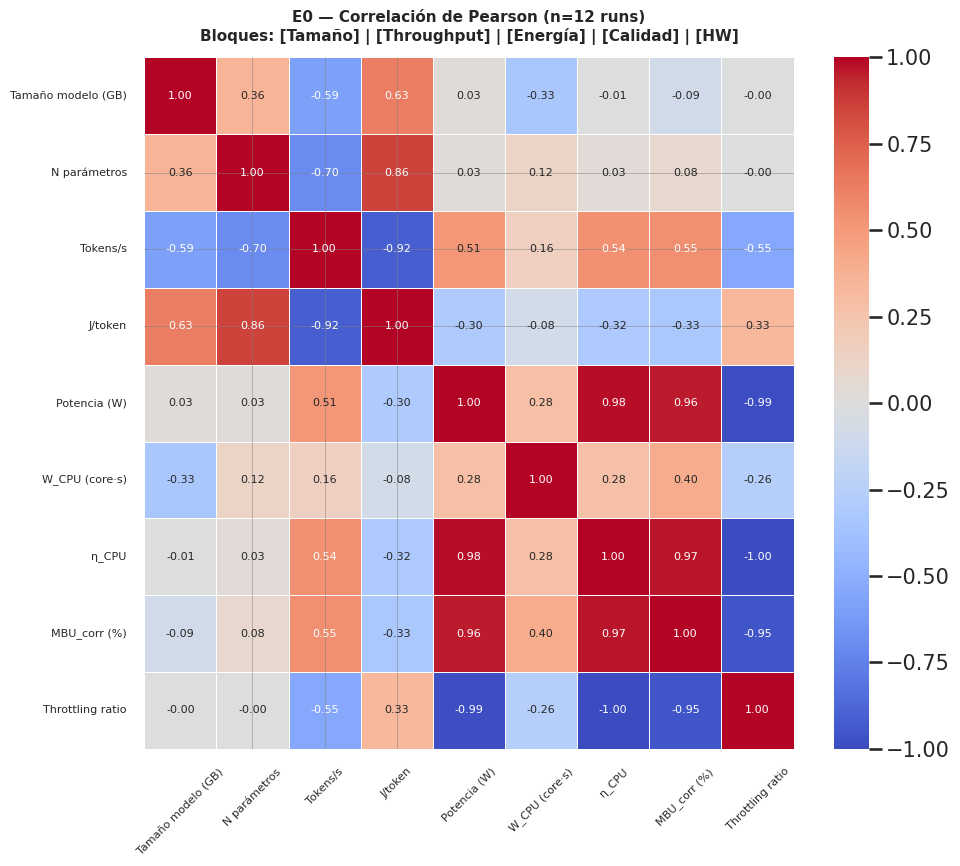

In [33]:
if not summary.empty and len(summary) >= 3:
    pearson_src = summary.copy()

    PEARSON_COLS_E0 = [
        "model_size_gb",
        "n_params",
        "tokens_per_s_mean",
        "latency_ms",
        "time_to_first_token_ms",
        "tokens_per_joule",
        "energy_per_token_j",
        "perplexity",
        "power_mean_w",
        "temp_max",
        "cpu_work_core_s",
        "cpu_efficiency",
        "mbu_corr",
        "throttled_ratio",
    ]
    available = [c for c in PEARSON_COLS_E0
                 if c in pearson_src.columns
                 and pd.api.types.is_numeric_dtype(pearson_src[c])]

    PEARSON_LABELS_E0 = {
        "model_size_gb":          "Tamaño modelo (GB)",
        "n_params":               "N parámetros",
        "tokens_per_s_mean":      "Tokens/s",
        "latency_ms":             "Latencia (ms)",
        "time_to_first_token_ms": "TTFT (ms)",
        "tokens_per_joule":       "tok/J",
        "energy_per_token_j":     "J/token",
        "perplexity":             "Perplejidad",
        "power_mean_w":           "Potencia (W)",
        "temp_max":               "Temp. máx (°C)",
        "cpu_work_core_s":        "W_CPU (core·s)",
        "cpu_efficiency":         "η_CPU",
        "mbu_corr":               "MBU_corr (%)",
        "throttled_ratio":        "Throttling ratio",
    }

    corr_df = (pearson_src[available]
               .dropna(how="all")
               .corr(numeric_only=True))
    corr_df = corr_df.rename(index=PEARSON_LABELS_E0, columns=PEARSON_LABELS_E0)
    n_vars  = len(corr_df)

    block_ends = []
    cumul = 0
    for group in [
        ["Tamaño modelo (GB)", "N parámetros"],
        ["Tokens/s", "Latencia (ms)", "TTFT (ms)"],
        ["tok/J", "J/token"],
        ["Perplejidad"],
        ["Potencia (W)", "Temp. máx (°C)", "W_CPU (core·s)", "η_CPU", "MBU_corr (%)", "Throttling ratio"],
    ]:
        count = sum(1 for g in group if g in corr_df.columns)
        cumul += count
        if count and cumul < n_vars:
            block_ends.append(cumul - 0.5)

    fig_sz  = max(10, n_vars * 0.85)
    fig, ax = plt.subplots(figsize=(fig_sz, fig_sz * 0.9))
    mask    = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
    sns.heatmap(
        corr_df,  annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        linewidths=0.4, ax=ax, annot_kws={"size": 8},
    )
    for d in block_ends:
        ax.axhline(d, color="gray", lw=0.7, alpha=0.5)
        ax.axvline(d, color="gray", lw=0.7, alpha=0.5)
    ax.set_title(
        f"E0 — Correlación de Pearson (n={len(summary)} runs)\n"
        "Bloques: [Tamaño] | [Throughput] | [Energía] | [Calidad] | [HW]",
        fontsize=11, pad=12,
    )
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    plt.tight_layout()
    plt.show()
else:
    n = len(summary) if not summary.empty else 0
    print(f"Se requieren ≥3 runs para la correlación (hay {n}).")


## 9. Análisis específico: impacto de la refrigeración activa

Comparativa directa entre los runs con ventilador (FAN) y sin ventilador
(NOFAN) para cada modelo. La refrigeración activa debería reducir el
throttling térmico y mejorar el throughput sostenido.

In [34]:
# ── Anexo: Pivote FAN/NOFAN con σ (E0) ────────────────────────────────────
if not summary.empty and "fan" in summary.columns:
    _hw0b = hw_df if "hw_df" in vars() else (hw_full if "hw_full" in vars() else pd.DataFrame())
    _pm0b = pm_df if "pm_df" in vars() else (pm_full if "pm_full" in vars() else pd.DataFrame())

    _smry0b = summary.copy()

    # σ inferencia
    if not _pm0b.empty and "run_id" in _pm0b.columns:
        _valid0b = _pm0b[~_pm0b["is_empty_generation"]] if "is_empty_generation" in _pm0b.columns else _pm0b
        _si0b = [c for c in ["tokens_per_second"] if c in _valid0b.columns]
        if _si0b:
            _si_df0b = (_valid0b.groupby("run_id")[_si0b].std().reset_index()
                        .rename(columns={"tokens_per_second": "tokens_per_s_std"}))
            _smry0b = _smry0b.merge(_si_df0b, on="run_id", how="left")

    # σ hardware
    if not _hw0b.empty and "run_id" in _hw0b.columns:
        _sh0b = [c for c in ["temperature_c", "internal_power_w"] if c in _hw0b.columns]
        if _sh0b:
            _sh_df0b = (_hw0b.groupby("run_id")[_sh0b].std().reset_index()
                        .rename(columns={"temperature_c":   "temp_std_c",
                                         "internal_power_w": "power_std_w"}))
            _smry0b = _smry0b.merge(_sh_df0b, on="run_id", how="left")

    _fan_cols = [c for c in [
        "tokens_per_s_mean", "tokens_per_s_std",
        "temp_max_c", "temp_mean_c", "temp_std_c",
        "power_mean_w", "power_std_w",
        "throttled_ratio", "cpu_efficiency",
    ] if c in _smry0b.columns]

    if _fan_cols:
        pivot = (_smry0b.pivot_table(index="model_label", columns="fan",
                                     values=_fan_cols, aggfunc="mean")
                 .round(2))
        pivot.columns = [f"{m} {'FAN' if f else 'NOFAN'}" for m, f in pivot.columns]
        print("Comparativa FAN vs NOFAN por modelo (medias):")
        display(pivot)
    else:
        print("Sin métricas disponibles.")
else:
    print("Sin columna fan en summary.")


Comparativa FAN vs NOFAN por modelo (medias):


,cpu_efficiency NOFAN,cpu_efficiency FAN,power_mean_w NOFAN,power_mean_w FAN,power_std_w NOFAN,power_std_w FAN,temp_max_c NOFAN,temp_max_c FAN,temp_mean_c NOFAN,temp_mean_c FAN,temp_std_c NOFAN,temp_std_c FAN,throttled_ratio NOFAN,throttled_ratio FAN,tokens_per_s_mean NOFAN,tokens_per_s_mean FAN,tokens_per_s_std NOFAN,tokens_per_s_std FAN
model_label,,,,,,,,,,,,,,,,,,
DeepSeek-R1-1.5B (L),0.34,0.97,4.79,7.18,0.57,0.86,96.35,75.45,94.54,71.99,0.89,1.63,1.0,0.0,4.25,8.98,0.42,1.29
Llama-3.2-1B (L),0.44,0.98,4.73,6.48,0.52,0.93,93.05,69.95,90.06,65.95,1.02,1.78,1.0,0.0,7.24,11.23,2.05,2.47
Llama-3.2-3B (L),0.45,0.99,4.83,6.77,0.42,0.77,93.05,73.25,90.25,67.21,1.03,2.00,1.0,0.0,2.60,4.61,0.52,1.11
gemma (L),0.40,0.95,4.78,6.90,0.51,1.04,95.80,72.15,91.82,68.64,2.30,2.15,1.0,0.0,3.07,5.68,0.38,0.09
granite (L),0.42,0.97,4.96,6.70,0.42,0.81,95.80,69.40,92.60,65.90,2.41,1.83,1.0,0.0,2.88,4.41,0.30,0.06
ministral (L),0.43,0.98,4.84,6.81,0.42,0.83,93.60,73.25,90.70,67.56,1.22,2.38,1.0,0.0,2.71,4.73,0.46,0.71


In [35]:
if not summary.empty and 'fan' in summary.columns:
    fan_summary = summary[summary['fan'] == True]
    if not fan_summary.empty:
        rank_cols = [c for c in ['model_label', 'tokens_per_s_mean',
                                   'energy_per_token_j', 'throttled_ratio']
                     if c in fan_summary.columns]
        if 'tokens_per_s_mean' in fan_summary.columns:
            ranking = (fan_summary[rank_cols]
                       .sort_values('tokens_per_s_mean', ascending=False)
                       .reset_index(drop=True))
            ranking.index += 1
            print('Ranking de modelos (con ventilador, por throughput):')
            display(ranking.round(3))
        else:
            print('tokens_per_s_mean no disponible para ranking.')
    else:
        print('Sin runs con ventilador (fan=True).')
else:
    print('Sin datos para ranking de modelos.')


Ranking de modelos (con ventilador, por throughput):


,model_label,tokens_per_s_mean,energy_per_token_j,throttled_ratio
1,Llama-3.2-1B (L),11.229,0.577,0.0
2,DeepSeek-R1-1.5B (L),8.978,0.799,0.0
3,gemma (L),5.683,1.214,0.0
4,ministral (L),4.731,1.440,0.0
5,Llama-3.2-3B (L),4.608,1.469,0.0
6,granite (L),4.410,1.519,0.0


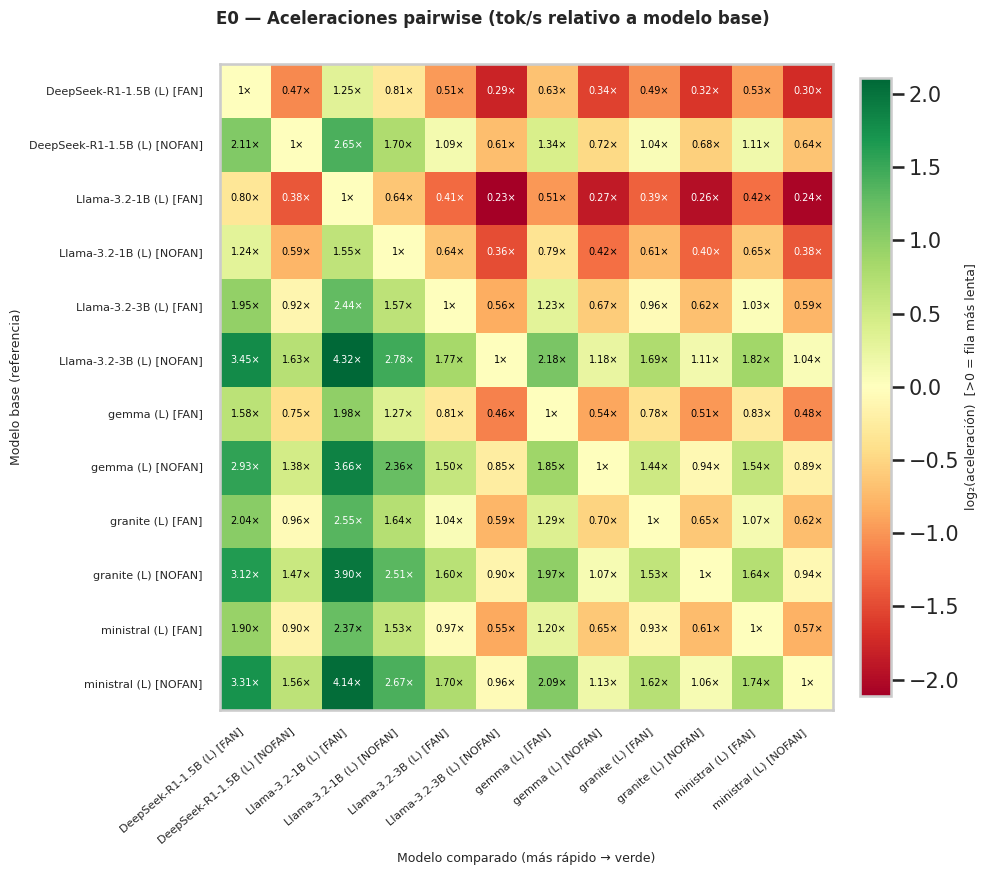

In [36]:
# Tabla de aceleraciones — comparación pairwise de todos los modelos (E0)
if not summary.empty and "tokens_per_s_mean" in summary.columns:
    _df_sp = summary.dropna(subset=["tokens_per_s_mean", "model_label"]).copy()

    # config_label: modelo + fan para distinguir FAN/NOFAN
    if "fan" in _df_sp.columns:
        _df_sp["_config"] = (_df_sp["model_label"]
                             + _df_sp["fan"].map({True: " [FAN]", False: " [NOFAN]"}).fillna(""))
    else:
        _df_sp["_config"] = _df_sp["model_label"]

    # Mediana por config si hay varios runs
    _speed = _df_sp.groupby("_config")["tokens_per_s_mean"].median()
    _labels = _speed.index.tolist()
    _n = len(_labels)

    _mat = np.zeros((_n, _n))
    for _i, _base in enumerate(_labels):
        for _j, _tgt in enumerate(_labels):
            _mat[_i, _j] = _speed[_tgt] / _speed[_base]

    _log_mat = np.log2(_mat)
    _off_diag = _log_mat[~np.eye(_n, dtype=bool)]
    _abs_max  = max(float(abs(_off_diag).max()), 0.5)

    fig, ax = plt.subplots(figsize=(max(9, _n * 0.85), max(8, _n * 0.75)))
    im = ax.imshow(_log_mat, cmap="RdYlGn", vmin=-_abs_max, vmax=_abs_max,
                   aspect="auto")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("log₂(aceleración)  [>0 = fila más lenta]", fontsize=9)

    ax.set_xticks(range(_n)); ax.set_yticks(range(_n))
    ax.set_xticklabels(_labels, rotation=40, ha="right", fontsize=8)
    ax.set_yticklabels(_labels, fontsize=8)
    ax.set_xlabel("Modelo comparado (más rápido → verde)", fontsize=9)
    ax.set_ylabel("Modelo base (referencia)", fontsize=9)
    ax.grid(False)

    for _i in range(_n):
        for _j in range(_n):
            _v  = _mat[_i, _j]
            _lv = _log_mat[_i, _j]
            _txt = "1×" if _i == _j else f"{_v:.2f}×"
            ax.text(_j, _i, _txt, ha="center", va="center", fontsize=7,
                    color="white" if abs(_lv) > _abs_max * 0.6 else "black")

    fig.suptitle("E0 — Aceleraciones pairwise (tok/s relativo a modelo base)",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para tabla de aceleraciones")


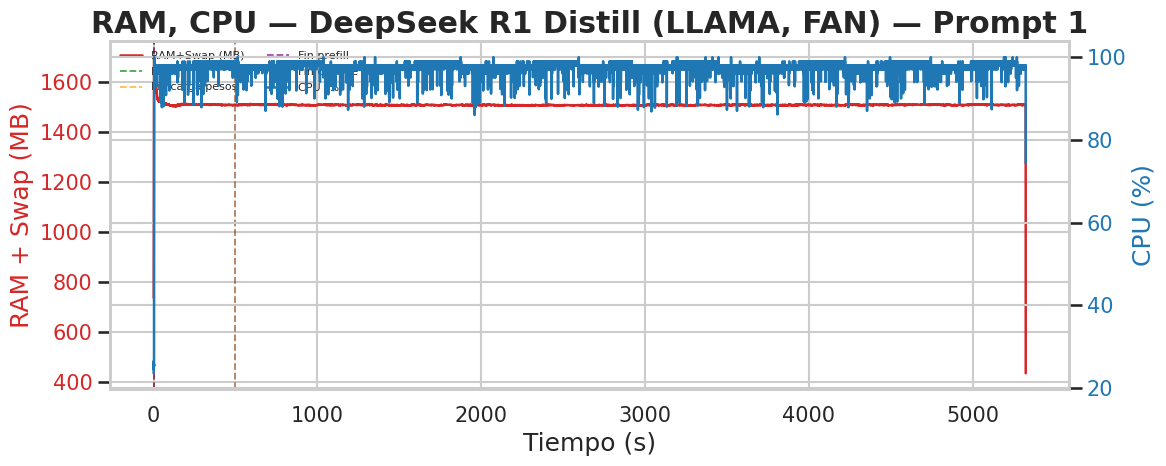

In [37]:
# ── Figura: RAM + CPU — DeepSeek (LLAMA, FAN), primer prompt ─────────────────
_ds_run = next(
    (r for r in runs_fan if "deepseek" in r.summary.model_path_or_name.lower()),
    None,
)

if _ds_run is not None:
    _hw = pd.DataFrame([m.model_dump() for m in _ds_run.hw_samples])
    _pm = pd.DataFrame([m.model_dump() for m in _ds_run.prompts])

    _hw["time_dt"] = pd.to_datetime(_hw["timestamp_ms"], unit="ms")
    _t0 = _hw["time_dt"].min()
    _hw["t_s"] = (_hw["time_dt"] - _t0).dt.total_seconds()
    _hw["ram_swap_mb"] = (_hw["mem_used_bytes"] + _hw["swap_used_bytes"]) / 1e6

    pal = sns.color_palette("tab10")
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # RAM + Swap — eje izquierdo
    sns.lineplot(data=_hw, x="t_s", y="ram_swap_mb", ax=ax1,
                 color=pal[3], label="RAM+Swap (MB)")
    ax1.set_xlabel("Tiempo (s)")
    ax1.set_ylabel("RAM + Swap (MB)", color=pal[3])
    ax1.tick_params(axis="y", labelcolor=pal[3])

    # CPU% — eje derecho
    ax2 = ax1.twinx()
    sns.lineplot(data=_hw, x="t_s", y="cpu_usage_pct", ax=ax2,
                 color=pal[0], label="CPU (%)")
    ax2.set_ylabel("CPU (%)", color=pal[0])
    ax2.tick_params(axis="y", labelcolor=pal[0])

    # Líneas verticales para las fases del primer prompt
    if not _pm.empty:
        _row = _pm.iloc[0]
        _t0_ns = int(_t0.value)
        _start_s       = (_row["start_timestamp_ns"]        - _t0_ns) / 1e9
        _end_load_s    = _start_s    + _row["load_duration_ns"]         / 1e9
        _end_prefill_s = _end_load_s + _row["prompt_eval_duration_ns"] / 1e9
        _end_decode_s  = _end_prefill_s + _row["eval_duration_ns"]     / 1e9

        for _x, _c, _lbl in [
            (_start_s,       "green",       "Inicio"),
            (_end_load_s,    "orange",      "Fin carga pesos"),
            (_end_prefill_s, "purple",      "Fin prefill"),
            (_end_decode_s,  "saddlebrown", "Fin decode"),
        ]:
            ax1.axvline(x=_x, color=_c, linestyle="--", alpha=0.7,
                        linewidth=1.3, label=_lbl)

    # Leyenda combinada
    _handles, _labels = [], []
    for _ax in (ax1, ax2):
        _h, _l = _ax.get_legend_handles_labels()
        _handles += _h; _labels += _l
        leg = _ax.get_legend()
        if leg:
            leg.remove()
    ax1.legend(_handles, _labels, loc="upper left", fontsize=8, ncol=2)

    ax1.set_title("RAM, CPU — DeepSeek R1 Distill (LLAMA, FAN) — Prompt 1")
    fig.tight_layout()
    plt.show()
else:
    print("No se encontró el run de DeepSeek con engine=LLAMA y FAN=True")

## 10. Conclusiones y discusión

### Confirmación de hipótesis
> [Rellenar con los resultados reales una vez ejecutado el notebook]

### Hallazgos principales
1. ...
2. ...
3. ...

### Limitaciones
- El análisis energético no incluye el consumo del sistema de refrigeración.
- La métrica MBU es una cota superior teórica para gemma3n (activación selectiva). En el caso de Granite no se dispone de  la caché kv
- Los prompts de IFEval pueden favorecer ciertos tipos de respuesta.

### Próximos pasos
- Comparar con los resultados del experimento E4 (OLLAMA vs LLAMA.cpp).
- Analizar el impacto de la cuantización en E1.